In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq
import anndata as ad

import warnings
#import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
  
warnings.simplefilter("ignore", category=UserWarning)

warnings.simplefilter("ignore", category=FutureWarning)  

In [2]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
#%matplotlib inline
sc.settings.figdir = "fig1"
sc.settings.set_figure_params(dpi_save=300, facecolor="white", frameon=False, figsize=(8,8))


In [3]:
#PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
PATH ='/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.addrelapse'

adata=sc.read_h5ad(PATH)

adata.obs.dataset_id.value_counts()

 

dataset_id
nan                           1670528
Reynolds                       270768
Fiskin_AD                      258665
Luc_Psoriasis                  200265
Ganier_BCC                     150893
Ahlers_Dermalsheath             94951
Ma_Psoriasis                    84340
Church_Healthy                  74402
bullous_pemphigoid              53824
Rojahn_AD                       49822
Dunlap_Lupus                    49821
Direder_Keloid                  47256
Greenleaf_AA                    41131
Ji_SCCarcinoma                  34340
Sole-Boldo                      27273
Kersh_Lichen planus             22686
Tabib_SSc                       22486
Ma_SSc                          21283
Ma_Prurigo                      20892
Dobie_Dupuytren                 20052
LocalSSc_Hutchins               18152
Weidmann_Healthy                17922
Jiang_Lyme                      17215
Kim_DRESS                       14655
Bangert_AD                      14493
Deng_Keloid                     11777
S

In [4]:
adata[adata.obs["niche19"]=="Plasma_cell_rich"].obs.info_id6.value_counts()


info_id6
BK27_Week 12                                       307
BK27_Lesional Baseline                             106
BK27_Non-lesional Baseline                          42
BK20_Week 12                                        29
BK23_Week 12                                        17
BK24_Lesional Baseline                              11
3D_BK25_week12-C2                                    9
Week 8 (resolved)_CE5-SKI-27-FO-4-S22-E1             7
Week 8 (resolved)_CE5-SKI-27-FO-4-S22_replicate      7
BK46_Never Lesional                                  6
3D_BK25_week12-D2                                    5
Week 8 (resolved)_CE3-SKI-28-FO-4-S22_replicate      5
Week 8 (resolved)_CE3-SKI-28-FO-4-S22-E1_a           4
3D_BK25_week12-D1orE1b                               3
3D_BK25_week12-D1orE1a                               3
BK30_Non-lesional Baseline                           2
BK30_Week 12                                         1
BK50_Never Lesional                                  1
B

In [94]:
adata[adata.obs["all_vs_core"]=="relapse"].obs.info_id6.value_counts()


info_id6
BK72_Relapse                         27877
BK49_Past Lesional                   27387
BK74_Baseline never lesional         24599
BK70_Week 8 past lesional            20903
BK46_Never Lesional                  18754
BK74_Relapse                         18584
BK46_Past Lesional                   18353
BK74_Relapse (past lesional site)    17601
BK74_Baseline past lesional          17381
BK70_Baseline past lesional          16999
BK72_Baseline past lesional          16497
BK51_Never Lesional                  15454
BK70_Relapse                         15111
BK73_Relapse                         14790
BK50_Never Lesional                  14673
BK51_wk8 Relapse                     14433
BK73_Baseline past lesional          14358
BK70_Baseline never lesional         13737
BK49_Never Lesional                  13472
BK49_Past Lesional wk8 relaspe       12682
BK51_Past Lesional                   12627
BK43_Never Lesional                  12110
BK49_wk8 Relapse                     11403
BK

In [93]:
[x for x in sorted(adata.obs["Sanger patient ID"].unique())]

['BK18',
 'BK20',
 'BK21',
 'BK22',
 'BK23',
 'BK24',
 'BK25',
 'BK27',
 'BK30',
 'BK39',
 'BK43',
 'BK46',
 'BK49',
 'BK50',
 'BK51',
 'BK70',
 'BK72',
 'BK73',
 'BK74',
 'CE3',
 'CE4',
 'CE5',
 'CE6',
 'nan']

In [4]:
# adata=sc.read_h5ad('/nfs/team361/ls34/data/adata_skinatlas_noffpe.h5ad')
# adata.obs.niche19.value_counts()


In [5]:
adata[adata.obs["tech"]=="xenium"].shape

(1670528, 4993)

In [6]:
adata[adata.obs["tech"]=="xenium"].obs.info_id6.nunique()

112

In [7]:
adata.obs["Site_status"].value_counts()

Site_status
Non-lesional                         1336354
Lesional                              542482
Healthy                               202749
3D_Week12                             180311
3D_Lesional_baseline                  153479
Week 12                               149280
Remission_longterm (past)             140285
Remission_longterm (never)            127032
Relapse                               102198
PostRx                                 96485
Psoriasis_replicate_non-lesional       76048
Week 8 Psoriasis                       72094
Remission_longterm (week 8)            71279
Psoriasis_replicate_Lesional           60647
Psoriasis_replicate_PostRx             49385
Day 14_HF                              30438
PostRx-Lesional Dupilumab (16 wk)       6694
PostRx-Lesional Dupilumab (1 yr)        4226
Name: count, dtype: int64

In [8]:
adata=adata[adata.obs["tech"]=="xenium"].copy()
adata=adata[adata.obs["niche19"]!="Nonspecific/folded"]
adata=adata[adata.obs["Sanger patient ID"]!="BK21"]
adata=adata[adata.obs["all_vs_core"]!="relapse"]


In [9]:
[x for x in adata.obs["info_id6"].unique() if "BK22" in x]

['BK22_Lesional Baseline',
 'BK22_Non-lesional Baseline',
 '3D_BK22_Lesional_baseline-A2',
 '3D_BK22_Lesional_baseline-D1',
 '3D_BK22_Lesional_baseline-B2',
 '3D_BK22_Lesional_baseline-D2',
 '3D_BK22_Lesional_baseline-A1',
 '3D_BK22_Lesional_baseline-B1',
 '3D_BK22_Lesional_baseline-C2',
 'BK22_Week 12']

In [10]:
RENAME = {"Tc0": "Tc",
          "Tc1": "Tc",
          "Tc2": "Tc",
          "ILC3_CCL1+PTGDS+": "ILC3",
        "Treg_LRRC32+": "Treg",

         }
adata.obs["tmp"]=adata.obs["lvl5_annotation"].map(RENAME)
adata.obs["lvl5_annotation"]=adata.obs["tmp"].fillna(adata.obs["lvl5_annotation"])

In [11]:
adata[adata.obs["lvl5_annotation"]=="beacon_ffpe"].shape

(59303, 4993)

In [12]:
adata[adata.obs["lvl5_annotation"]=="beacon_ffpe"].shape

(59303, 4993)

In [13]:
# [x for x in adata.obs["info_id6"].unique() if "BK22" in x]

In [14]:
# import os
# import pickle
# md = adata[adata.obs["tech"]=="xenium"].obs["niche19"].to_dict()

# out_path = "/nfs/team298/ls34/dicts/skin_niche19.pkl"

# os.makedirs(os.path.dirname(out_path), exist_ok=True)

# with open(out_path, "wb") as f:
#     pickle.dump(md, f)

In [15]:
# md

In [16]:
adata.obs.dataset_id.value_counts()

dataset_id
nan    1197811
Name: count, dtype: int64

In [17]:
1

1

In [18]:
# adata_bangert = adata[adata.obs["dataset_id"]=="Bangert_AD"].copy()

In [19]:
# adata_bangert

In [20]:
# [x for x in adata_bangert.obs.columns if "anno" in x.lower()]

In [21]:
colors_cells = {'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',
 'F2/3: Perivascular': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1/2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#272c5f',
 'KC_HF: Basal': '#006400',
 'KC_HF: m': '#abe8bd',
 'KC_HF: HS': '#abe8bd',
 'KC_HF: IRS+HS': '#abe8bd',
 'KC_SebocyteGland_Outer': '#fe5e00',
 'KC_SebocyteGland_Inner': '#ffff33',
 'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
 'KC_SebocyteDuct_Outer': '#958159',
 'KC_SebocyteDuct_Inner': '#f6d7b0',
 'KC_HF: ORS0': '#003200',
 'KC_HF: ORS1': '#9ad295',
 'KC_HF: ORS1/2': '#9ad295',
 'KC_HF: ORS2': '#e7f9e5',
 'KC_HF: IRS': '#ff083a',
 'KC_HF: IRS_cycling': '#FF849D',
 'KC: HF ORS1/2': '#94cb72',
 'KC_HF: IRS+HS_medulla': '#94cb72',
 'KC_HF: IRS_TCHH+': '#990523',
 'KC_SC: LGR6+ACTA2+': '#008080',
 'KCinflamm_basal/int': '#f4e9ef',
 'KCinflamm_late': '#D49BB1',
 'LC': '#63D7F0',
 'LC_SLC18A2+': '#3bc1d9',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2': '#845DAE',
 'Mac2_CCL14hi': '#4F2F6D',
 'Mast cell': '#f8ac59',
 'Melanocyte': '#6f3a3a',
 'MigDC': '#00FF00',
 'MigDC (cDC2)': '#00FF00',
 'MigDC (cDC1)': '#FF9999',
 'Smooth muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Pericyte1': '#F7A3C3',
 'Pericyte2_VSMC': '#D04A8A',
 'Plasma cell': '#ff5e00',
 'KC_Sebocyte_basal': '#e28743',
 'KC_Sebocyte_inner': '#ffd1a3',
 'KC_Sebocyte': '#ffd1a3',
 'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': '#FFE5B4',
 'Sweat gland channel inner': '#FFE5B4',
 'Sweat gland channel_outer': '#B3FFF0',
 'Sweat gland channel outer': '#B3FFF0',
 'Sweat gland Myoepithelial': '#f275ae',
 'T': '#F4D1A1',
 'T_Prolif': '#D4B082',
 'Tc': '#8C6A3B',
 'Tc1': '#8C6A3B',
 'Tc2': '#8C6A3B',
                 'Tc': '#8C6A3B',

 'Tc_IL9R+GPR15hi': '#5a1f16',
          
 'Tnaive': '#F9F2E4',
 'Treg': '#B2CBA4',
 'Treg_LRRC32+': '#68984c',
 'VE2': '#9f1a1a',
 'VE': '#9f1a1a',
 'VE1_Art': '#660000',
 'VE3_Ven': '#764869',
 'VE4_Cap': '#FFB6C1',
 'VE3_Ven_APLN+': '#FF073A',
 'cDC1': '#ac1d5c',
 'cDC2': '#6F478C',
 'cDC2: MMP12hi': '#f71886',
 'mSchwann': '#555555',
 'nmSchwann': '#999999',
 'pDC': '#D85B8C',
 'cDC2: EREG+CCR7+': '#7B8B43',
 'TransitionalDC': '#9b4ef5',
 'Bcell':  "#1E90FF",  # DodgerBlue – not already used
 'Cartilage': '#404040',
 'F4: DP_HHIP+': '#26a83f',
 'F4: HF-associated': '#26a83f',
 'F_Fascia': '#000000',
 'ILC1': '#FFFF00',
 'ILC1_NCR2+P2RX7+': '#c18bcb',
 'ILC1_NK': '#F4D03F',
 'ILC1/NK': '#F4D03F',
 'ILC2': '#F1C40F',
 'ILC2/3': '#F1C40F',
 'ILC3': '#ff68b4',
                #'#C79A00',
 #'ILC3 CCL1+PTGDS+': '#ff68b4',
  #          'ILC3_CCL1+PTGDS+': '#ff68b4',

 'ILC_Prolif': '#3F3100',
 'ILC_prolif': '#3F3100',
 'KC1': '#3a4e7a',
 'KC2': '#505aa1',
 'KC_HF: ORS_cycling': '#00b300',
 'KC_HF: Basal_NPNT+': '#006400',
 'KC_HF': '#006400',
 'KCinflamm_basal': '#f9f3fb',
 'KCinflamm': '#f9f3fb',
 'KCinflamm_int/late': '#e9c8dc',
 'KCinflamm_cycling': '#e0c5d2',
 'KC1-2_cycling': '#e0c5d2',
 'KCinflamm_int': '#f5d3e7',
 'LC_CCR7+': '#3bc1a4',
 'Mac1': '#6A3F9B',
 'Mac_CX3CR1+': '#9D1A80',
 'Mac_TREM2+LPL+': '#D2C5E1',
 'Merkel cell': '#2f2f2f',
 'MoDC': '#7F00A2',
 'MoDC/cDC2: MMP12+': '#7F00A2',
 'MoDC/cDC2': '#7F00A2',
 'Monocyte': '#D8A7FF',
 'Mono CD16+': '#E1C6FF',
 'NK': '#FF00FF',
 'Neutrophil': '#4D3F8C',
 'Satellite cell': '#F387C7',
 'Skeletal muscle': '#F14D8E',
 'Tc_IFNGhi': '#F5A600',
 'Tc3_IFNGhi': '#F5A600',
 'TRM_IL13+': '#1F51FF',
 'TRM_IL17+': '#E63238',
 'Tc_ZNF683+': '#D4B082',
 'Th': '#F9CA67',
 'Th_PPARGhi': '#FAE064',
 'Th_CXCR6+': '#F48B50',
 'TR1': '#E3F2DC',
 'cDC2: IL1B+': '#B78FE1',
 'cDC2_cycling': '#9272B4',
 'Eosinophil': '#FF5F00',
 'Mechanoreceptor ASIC2+': '#D3D3D3',
           'ASIC2+_Mechanoreceptor':  '#D3D3D3',
 'Tc_γδ': '#28c1d0',
      'T_γδ': "#28c1d0",

 'Tc0': '#5a1f16',
 'Th_PPARGhi_IL17': '#FFE064',
 'Tfh-like': '#d8e4e2',
 'Th2': '#b8bde3',
 'ILC3_prolif': '#503E00',
 'ILC1_prolif': '#666600',
 'ILC_SELL+CCR7+': '#FFFFCC',
            
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    


#              "Other": '#D3D3D3'
          
                "KC_HF: IRS_Cuticle":        "#E97388",
    
        "KC_HF: HS Xenium":     "#0000FF",
    "KC_HF: HS":           "#8A0C26",
    
    
 "KC_HF: HS scRNA":      "#FF69B4",
    
    "Other":                "#F3F3F3",
    
    
   


    "KC_HF: ORS0":          "#006400",
    "KC_HF: ORS1":          "#66C266",
    "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
    "KC_HF: ORS_cycling":    "#267326" , #"#000000",
        "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
        "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
    "KC_HF: IRS":           "#0000FF",
    "KC_HF: IRS0":          "#FFA500",
    "KC_HF: IRS1":          "#FFD280",
   # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
    "KC_HF: IRS_cycling":   "#00F5FF",
        'KC_HF: Matrix':  "#00F5FF",

    'KC_SebocyteDuct_Outer':   "#FF69B4",
    #e6ecf0
    "KC_HF: ORS cycling(new)":   "#1A1A1A",
    "KC_HF: HFSC":               "#D600FF",
  
    
    "KC_Sebocyte_DuctOuter":                 "#000000",  # black
    "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
    "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
    "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
    "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
    "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
        'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

    "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
     'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
         'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
        'Sweat gland channel outer': "#99EEEE",
                "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
         
         'KC3-5': '#b1dae6',
          'KC1-2': '#505aa1',
          'TRM': '#E63238',
          'KC_Sebocyte_Duct':  "#C8A165", 
          'KC_Sebocyte_Gland': "#FFFFCC", 
          'KC_HF: ORS/IRS/HS':'#9ad295',
          'Schwann': '#555555',
          'Sweat gland/duct': '#00CCCC',
          'F5: Schwann-like': '#788bd2',
          'KC_HF: ORS/IRS': '#9ad295',
          'Pericyte': '#F7A3C3',
          'KC_Sebocyte_Duct/Gland':  "#FFFFCC",
          'ILC':  '#F1C40F',
      'KC': "#ADD8E6",              # pale blue
    'KC_HF_SPON2': "#007CFE",     # bright blue
             'KC_HF: SPON2+': "#007CFE", 
    'cDC': "#D8BFD8",             # pale purple (thistle)
    'Th/TRM prolif': "#A0522D",   # sienna (darkish beige/red)
    'Treg/Tnaive_prolif': "#006400",  # dark green
    'Tc_Prolif': "#D2B48C",       # tan (dark beige)
    'KC_HS: HS_TRPV1+': "#FF69B4",    # hot pink (very bright pink)
          'KC_HF: HS2': "#FF69B4", 
    'Plasma cell2': "#9D00FF",    # neon purple
    'beacon_ffpe': "#DCDCDC"      # very light grey (gainsboro)
}


# # import pickle
# # file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# # with open(file_path, 'wb') as file:
# #     pickle.dump(colors, file)



# # sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(21,21))
# # sc.pl.umap(
# #     adata_bangert,
# #     color=[ "lvl5_annotation"],
# #     show=True,
# #     frameon=False,
# #     legend_loc= "on data",
# #     legend_fontsize=12,
# #     s=50,
# #     title='',
# #     legend_fontoutline=2,
# #    # palette=colors

# #     #save="1a_scrna.pdf",
# #  #   linewidth=0.01,
# #   #  edgecolor='black'
# # )
# # print(adata.shape)

In [22]:
adata[adata.obs["tech"]=="xenium"].obs.index

Index(['aaadcgio-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aaaecdal-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aaamegja-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aabanjmi-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aabbfcni-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aabfgdni-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aabpfhan-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aacbcobb-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aacgjikg-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       'aaclcllh-1_output-XETG00272__0041416__BK22-SKI-27-FO-1-S10-A1__20241107__113553',
       ...
       'ohlelkhe-1_output-XETG00272__0041416__BK22-SKI-27-FO-5-S6-C1__20241107__113553',


In [23]:
[k for k in adata.obs.index if "BK18" in k]

[]

In [24]:
adata

AnnData object with n_obs × n_vars = 1197811 × 4993
    obs: 'sample_id', 'barcode', 'GSE', 'Site_status', 'Patient_status', 'Location', 'Age', 'Sex', 'dataset_id', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'lvl5_annotation', 'Mapping_status', 'scanvi_predictions', 'lvl4_annotation', 'lvl0', 'Site_status_simple', 'StatusMilo', 'atlas_status', 'atlas_status_reynolds', 'atlas_status_reynolds_simple', 'atlas_status_simple', 'atlas_status_simple2', 'Site_status_binary', 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'Sanger patient ID', 'Drug', 'Timepoint', 'DonorID', 'disease_overall', 'lvl0_new', 'T

In [25]:
# md=adata.obs["niche19"].to_dict()
# import pickle
# with open('/nfs/team298/ls34/dicts/niche19.pkl', 'wb') as f:
#     pickle.dump(md, f)

In [26]:
# adata_i.obs["Timepoint2"].value_counts()

In [27]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr
# adata_i=adata[adata.obs["tech"]=="xenium"].copy()
# adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

# # --------------------------------------------------
# # Keys (explicit, so nothing "mysteriously" breaks)
# # --------------------------------------------------
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "response"

# # --------------------------------------------------
# # 1. Compute niche proportions per patient
# # --------------------------------------------------
# counts = (
#     adata_i.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .rename("count")
#     .reset_index()
# )

# # Total cells per patient
# totals = (
#     counts
#     .groupby(SAMPLE_KEY)["count"]
#     .sum()
#     .rename("total_cells")
#     .reset_index()
# )

# counts = counts.merge(totals, on=SAMPLE_KEY)

# # Proportion of each niche per patient
# counts["prop"] = counts["count"] / counts["total_cells"]

# # --------------------------------------------------
# # 2. Attach patient-level response
# # --------------------------------------------------
# response_df = (
#     adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
#     .drop_duplicates(subset=SAMPLE_KEY)
# )

# counts = counts.merge(response_df, on=SAMPLE_KEY)

# # --------------------------------------------------
# # 3. Correlation per niche (Spearman)
# # --------------------------------------------------
# results = []

# for niche, df_n in counts.groupby(NICHE_KEY):

#     n_patients = df_n[SAMPLE_KEY].nunique()
#     if n_patients < 5:
#         continue

#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, n_patients))

# corr_df = (
#     pd.DataFrame(
#         results,
#         columns=["niche40", "spearman_r", "p_value", "n_patients"]
#     )
#     .sort_values("spearman_r", ascending=False)
# )

# print(corr_df)

# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------
# fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# ax.barh(
#     corr_df["niche40"],
#     corr_df["spearman_r"],
#     edgecolor="black"
# )

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with response")
# ax.set_ylabel("Niche")

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()




In [28]:
# adata.

In [29]:
# adata_i=adata[adata.obs["tech"]=="xenium"].copy()


In [30]:
adata_i=adata[adata.obs["tech"]=="xenium"].copy()


In [31]:
# .obs.sample_id.value_counts()

In [32]:
{x: "" for x in sorted(adata_i[~adata_i.obs["Sanger patient ID"].isna()].obs["Sanger patient ID"].unique())}

{'BK18': '',
 'BK20': '',
 'BK22': '',
 'BK23': '',
 'BK24': '',
 'BK25': '',
 'BK27': '',
 'BK30': '',
 'BK39': '',
 'CE3': '',
 'CE4': '',
 'CE5': '',
 'CE6': '',
 'nan': ''}

In [33]:
RENAME = {
    'BK18': 2026 - 1963,  # 63
    'BK20': 2026 - 1994,  # 32
    'BK21': 2026 - 2015,  # 11
    'BK22': 2026 - 1999,  # 27
    'BK23': 2026 - 1995,  # 31
    'BK24': 2026 - 2007,  # 19
    'BK25': 2026 - 1992,  # 34
    'BK27': 2026 - 2003,  # 23
    'BK30': 2026 - 2002,  # 24
    'BK39': 2026 - 1987,  # 39
}
adata_i.obs["disease_duration"] = adata_i.obs["Sanger patient ID"].map(RENAME)

In [34]:
adata_i.obs["disease_duration"].value_counts()

disease_duration
24.0    79482
39.0    64938
31.0    53363
63.0    40441
27.0    40367
34.0    39148
19.0    36288
23.0    29908
32.0    24049
Name: count, dtype: int64

In [35]:
# colors_new2 = {
#         'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
#     "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
#                 'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
#   #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
#             'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

#    'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
# 'Epidermis_basal_cycling': "#007cfe", 
# 'EpidermisInflamm_mid':"#f6e3ec",
#         'EpidermisInflamm_late': "#800020",
    
    
#     # 'Epidermis_Inflammatory': '#f2e7ed',
#         "Epidermis_APChi": "#ff1493",
#     'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
#   #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
#     'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
#     'Sweat_gland': '#008080',  # dark grey
#         'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
#     'Muscle': "#f371af",  # very dark red
#     'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
#      'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
#     'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
#     'Perineural': '#0A0A0A',  # almost black
#    # 'Plasma+pDC': '#808080',  # bright turquoise
#     #'Sweat gland channel': '#000000',  # black
#     #'KC_immunecell': '#FF1493',  # dark pink
    
#    # 'Epidermis_late': '#b1dae6',
#     "Nonspecific":"#D3D3D3",
#      'Reticular_dermis': '#d0e1f2',

#  'Large_BV': '#660000',
#  'Small_BV': "#c43f40",#'#D96B6B',
#      'Tzone-like': "#845DAE",# '#F4D1A1',

#  'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
# "Sebaceous_immune": "#ff6145", 
#  #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
#    # 'Plasma_cell_rich':  "#8080B2", #"
# "Plasma_cell_rich": "#04D9FF",
#     'HF_Perineural': '#00FF00',
#     "OuterHF": "#006600",# 
#  'Sebaceous duct': '#e28743',


# "Lymphoid Tzone-like": "#825bac",
    



#      #007FFF
#     "Reticular_dermis_LE_rich" : "#6A8ED8",
#         "Reticular_dermis_LErich" : "#6A8ED8",
#     "Small_BV_Trich": "#FFB6C1",          # neon orange
#     "Tzone-like_Theavy": "#B19CD9",       # light purple
#     #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
#     "HF_outer": "#90c670",                # very dark green
#     "VenuleMuscle": "#B34A7E",

#     "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
#     "VenuleEndothelium": "#8B0000",       # dark red
#     "HF_inner": "#90EE90",                 # light green
#     "HF_TNN+COCH+hi": "#39FF14",          # neon green
#     # "Peri_sweat_gland": "#d9f9f7",
#     'HF_innermost':  "#D95D54",
#   #  'Sebaceous_inner_immune':"#F6A85C",
#     'Nonspecific/folded': "#F0F0F0",
#  'nan': '#FAFAFA'
#     }

# # sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# # adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# # adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
# #                                      for cat in adata.obs['niche17'].cat.categories]
    
# # sc.pl.umap(adata, 
# #            color=["niche17"  ],
# #            size=3, 
# #            legend_loc="on data", 
# #            vmax="p99", 
# #            legend_fontsize=12,
# #           legend_fontoutline=2,
# #            linewidth=0.02,
# #            edgecolor='white',
# #           )
# # sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))


In [36]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr
# # adata_i=adata[adata.obs["tech"]=="xenium"].copy()
# adata_i=adata_i[~adata_i.obs["disease_duration"].isna()]
# adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

# # --------------------------------------------------
# # Keys (explicit, so nothing "mysteriously" breaks)
# # --------------------------------------------------
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "disease_duration"

# # --------------------------------------------------
# # 1. Compute niche proportions per patient
# # --------------------------------------------------
# counts = (
#     adata_i.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .rename("count")
#     .reset_index()
# )

# # Total cells per patient
# totals = (
#     counts
#     .groupby(SAMPLE_KEY)["count"]
#     .sum()
#     .rename("total_cells")
#     .reset_index()
# )

# counts = counts.merge(totals, on=SAMPLE_KEY)

# # Proportion of each niche per patient
# counts["prop"] = counts["count"] / counts["total_cells"]

# # --------------------------------------------------
# # 2. Attach patient-level response
# # --------------------------------------------------
# response_df = (
#     adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
#     .drop_duplicates(subset=SAMPLE_KEY)
# )

# counts = counts.merge(response_df, on=SAMPLE_KEY)

# # --------------------------------------------------
# # 3. Correlation per niche (Spearman)
# # --------------------------------------------------
# results = []

# for niche, df_n in counts.groupby(NICHE_KEY):

#     n_patients = df_n[SAMPLE_KEY].nunique()
#     if n_patients < 5:
#         continue

#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, n_patients))

# corr_df = (
#     pd.DataFrame(
#         results,
#         columns=["niche40", "spearman_r", "p_value", "n_patients"]
#     )
#     .sort_values("spearman_r", ascending=False)
# )

# print(corr_df)

# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------
# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------
# fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# # Build color list in the same order as corr_df
# bar_colors = [colors_new2[n] for n in corr_df["niche40"]]

# ax.barh(
#     corr_df["niche40"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black"
# )

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with disease duration")
# ax.set_ylabel("Niche")

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()

In [37]:
# stop

In [38]:
# adata.obs[""]

In [39]:
# adata_i.obs.baseline_severity.value_counts()

In [40]:


# # --------------------------------------------------
# # Keys (explicit, so nothing "mysteriously" breaks)
# # --------------------------------------------------
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "baseline_severity"

# # --------------------------------------------------
# # 1. Compute niche proportions per patient
# # --------------------------------------------------
# counts = (
#     adata_i.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .rename("count")
#     .reset_index()
# )

# # Total cells per patient
# totals = (
#     counts
#     .groupby(SAMPLE_KEY)["count"]
#     .sum()
#     .rename("total_cells")
#     .reset_index()
# )

# counts = counts.merge(totals, on=SAMPLE_KEY)

# # Proportion of each niche per patient
# counts["prop"] = counts["count"] / counts["total_cells"]

# # --------------------------------------------------
# # 2. Attach patient-level response
# # --------------------------------------------------
# response_df = (
#     adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
#     .drop_duplicates(subset=SAMPLE_KEY)
# )

# counts = counts.merge(response_df, on=SAMPLE_KEY)

# # --------------------------------------------------
# # 3. Correlation per niche (Spearman)
# # --------------------------------------------------
# results = []

# for niche, df_n in counts.groupby(NICHE_KEY):

#     n_patients = df_n[SAMPLE_KEY].nunique()
#     if n_patients < 5:
#         continue

#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, n_patients))

# corr_df = (
#     pd.DataFrame(
#         results,
#         columns=["niche40", "spearman_r", "p_value", "n_patients"]
#     )
#     .sort_values("spearman_r", ascending=False)
# )

# print(corr_df)

# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------

# fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# # Build color list in the same order as corr_df
# bar_colors = [colors_new2[n] for n in corr_df["niche40"]]

# ax.barh(
#     corr_df["niche40"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black"
# )

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with disease duration")
# ax.set_ylabel("Niche")

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()



In [41]:
# easi_response = {
#     "BK18": 79.14, "BK19": 59.65, "BK20": 100.00, "BK21": 7.69,"BK24": 97.4, 
#     "BK22": 6.43, "BK23": 81.50, "BK25": 93.39, "BK26": 92.75,
#     "BK27": 59.92, "BK28": 27.82, "BK29": 4.85, "BK30": 89.53,
#     "BK31": 95.16, "BK36": 71.09, "BK37": 44.03, "BK38": 72.56,
#     "BK39": 100.00, "BK40": 84.94, "BK41": 73.43, "BK42": 14.89,
#     "BK44": 78.68, "BK45": 82.99, "BK47": 10.89, "BK48": 69.75,
#     "BK58*": 9.64, "BK59*": 91.33, "BK60*": 100.00, "BK61*": 82.44,
#     "BK62*": 92.87, "BK63*": 65.06, "BK64": 100.00, "BK65*": 35.92,
#     "BK66": 100.00, "BK67*": 78.26, "BK68*": 3.25, "BK71": -6.93,
#     "BK75": 85.84, "BK76": 100.00, "BK77": 87.04, "BK78": -13.33,
#     "BK79": 95.24,
# }
# adata.obs["response"]=adata.obs["Sanger patient ID"].map(easi_response)
# adata.obs["response"].value_counts()

In [42]:
easi_response = {
    "BK21": "7.69",
    "BK22": "6.43",
    "BK58": "9.64",
    "BK59": "91.33",
    "BK65": "35.92",
    "BK68": "3.25",
    "BK18": "79.14",
    "BK19": "59.65",
    "BK20": "100.00",
    "BK23": "94.98",
    "BK24": "97.40",
    "BK25": "93.39",
    "BK26": "92.75",
    "BK30": "89.53",
    "BK38": "72.56",
    "BK39": "100.00",
    "BK41": "73.43",
    "BK60": "100.00",
    "BK61": "82.44",
    "BK62": "92.87",
    "BK63": "65.06",
    "BK64": "100.00",
    "BK67": "78.26",
    "BK69": "61.08",
    "BK71": "-6.93",
    "BK37": "44.03",
    "BK42": "14.89",
    "BK78": "-13.33",
    "BK36": "71.09",
    "BK40": "84.94",
    "BK44": "78.68",
    "BK66": "100.00",
    "BK76": "100.00",
    "BK28": "27.82",
    "BK29": "4.85",
    "BK47": "10.89",
    "BK27": "59.92",
    "BK31": "95.16",
    "BK45": "82.99",
    "BK48": "69.75",
    "BK75": "85.84",
    "BK77": "87.04",
    "BK79": "95.24",
}

adata.obs["response"]=adata.obs["Sanger patient ID"].map(easi_response)
# adata.obs["response"].value_counts()

patient_to_response = adata.obs.drop_duplicates("Sanger patient ID").set_index("Sanger patient ID")["response"].to_dict()
patient_to_response

 


{'BK22': '6.43',
 'BK23': '94.98',
 'BK27': '59.92',
 'BK20': '100.00',
 'BK18': '79.14',
 'BK39': '100.00',
 'BK25': '93.39',
 'BK30': '89.53',
 'BK24': '97.40',
 'CE6': nan,
 'CE5': nan,
 'CE3': nan,
 'CE4': nan,
 'nan': nan}

In [43]:
adata_i=adata[~adata.obs["response"].isna()]
response_dict = adata_i.obs.drop_duplicates("Sanger patient ID").set_index("response")["Sanger patient ID"].to_dict()
response_dict

{'6.43': 'BK22',
 '94.98': 'BK23',
 '59.92': 'BK27',
 '100.00': 'BK39',
 '79.14': 'BK18',
 '93.39': 'BK25',
 '89.53': 'BK30',
 '97.40': 'BK24'}

In [44]:
[x for x in adata_i.obs.info_id6.unique() if "BK21" in x]

[]

In [45]:
# adata_i=adata_i[~adata_i.obs["baseline_severity"].isna()]
# adata_i=adata_i[~adata_i.obs["response"].isna()]


In [46]:
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]
patient_to_response = adata_i.obs.drop_duplicates("Sanger patient ID").set_index("Sanger patient ID")["response"].to_dict()
patient_to_response


{'BK22': '6.43',
 'BK23': '94.98',
 'BK20': '100.00',
 'BK27': '59.92',
 'BK18': '79.14',
 'BK39': '100.00',
 'BK25': '93.39',
 'BK30': '89.53',
 'BK24': '97.40'}

In [47]:
import pickle
with open('/nfs/team298/ls34/dict/niche19_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)
    
#colors_new2 = colors_new2 | {'Sebaceous_duct outlier/epidermis' : "#8B95A1"}

                          niche19  spearman_r p_value  n_patients p_adj
        Epidermis_basal_TRM_IL13+       0.630  0.0688           9 0.585
            Sweat_gland_TRM_IL13+       0.493   0.178           9 0.934
         Sebaceous_duct_TRM_IL13+       0.281   0.464           9 0.934
             Hypodermis_TRM_IL13+       0.275   0.474           9 0.934
          Epidermis_mid_TRM_IL13+       0.259     0.5           9 0.934
               Small_BV_TRM_IL13+       0.159   0.683           9 0.934
             Tzone-like_TRM_IL13+       0.147   0.706           9 0.934
               HF_outer_TRM_IL13+       0.138   0.724           9 0.934
       Papillary_dermis_TRM_IL13+       0.122   0.755           9 0.934
    Sweat_gland_channel_TRM_IL13+       0.060   0.879           9 0.934
 EpidermisInflamm_upper_TRM_IL13+      -0.005    0.99           9  0.99
        Epidermis_upper_TRM_IL13+      -0.069    0.86           9 0.934
       Reticular_dermis_TRM_IL13+      -0.115   0.769           

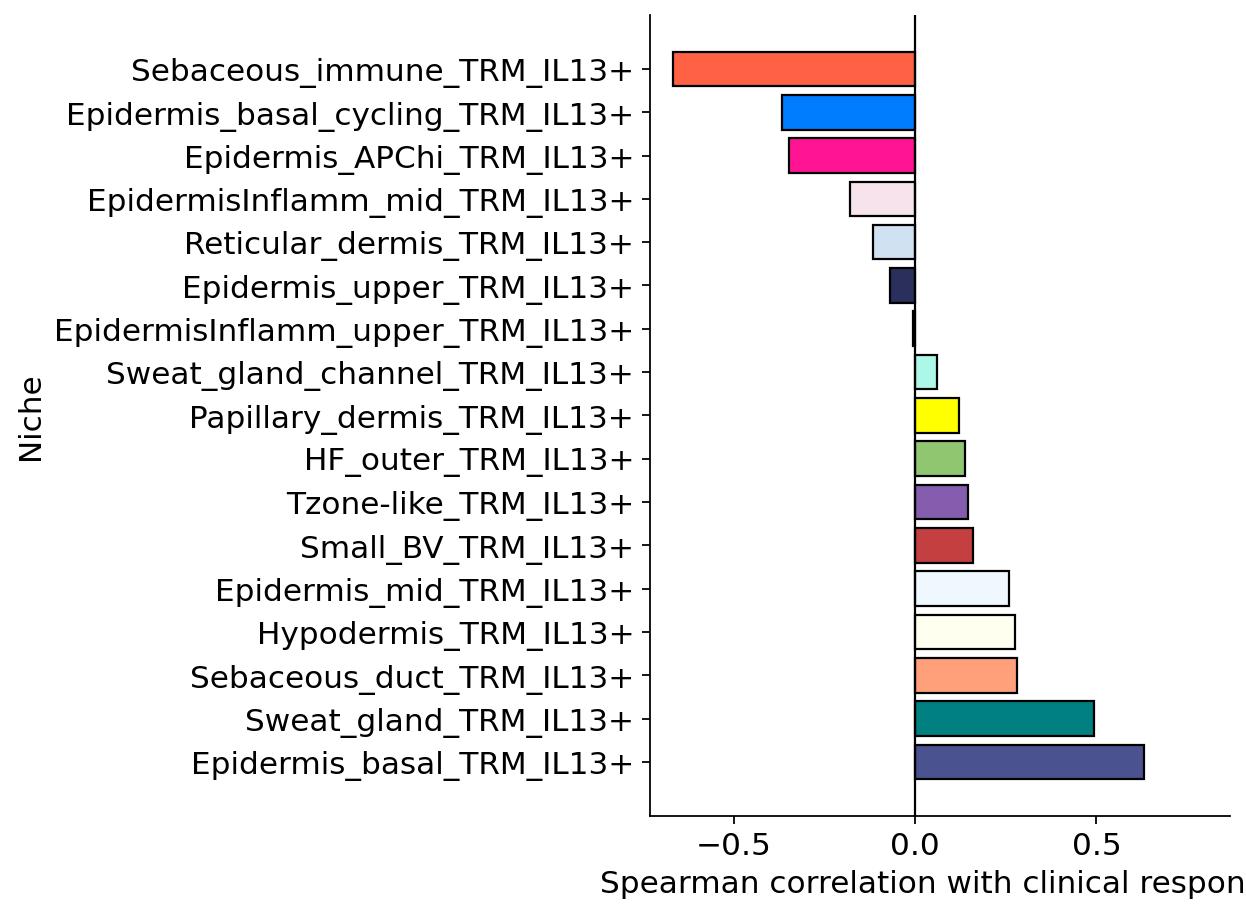

In [48]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Build niche × celltype column ---
adata_i.obs["niche19_celltype"] = (
    adata_i.obs["niche19"].astype(str) + "_" + adata_i.obs["lvl5_annotation"].astype(str)
)

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19_celltype"
RESPONSE_KEY = "response"

adata_ii = adata_i[adata_i.obs["lvl5_annotation"].str.startswith("TRM_IL13")].copy()

# --- 2. Niche proportions per patient ---
counts = (
    adata_ii.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# --- 3. Long format + attach response ---
props_long = props.stack().rename("prop").reset_index()
response_df = adata_ii.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
props_long = props_long.dropna(subset=[RESPONSE_KEY])

# --- 4. Spearman per niche ---
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
if len(corr_df) == 0:
    raise RuntimeError("No niches passed the 5-patient threshold — nothing to plot.")

corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)

# Print the full results table (raw and FDR-adjusted p-values)
print(
    corr_df.assign(
        spearman_r=lambda d: d["spearman_r"].round(3),
        p_value=lambda d: d["p_value"].map(lambda x: f"{x:.3g}"),
        p_adj=lambda d: d["p_adj"].map(lambda x: f"{x:.3g}"),
    ).to_string(index=False)
)

# --- 5. Map composite name back to base niche for colouring ---
def get_niche(name):
    return name.rsplit("_TRM_", 1)[0]

bar_colors = [
    colors_new2.get(get_niche(n), "#cccccc")
    for n in corr_df["niche19"]
]

unmapped = [get_niche(n) for n in corr_df["niche19"] if get_niche(n) not in colors_new2]
if unmapped:
    print(f"\nunmapped niches (grey fallback): {unmapped}")

# --- 6. Bar plot ---
fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(corr_df))))

ax.barh(
    corr_df["niche19"], corr_df["spearman_r"],
    color=bar_colors, edgecolor="black",
)

# # Significance stars + raw p-value text next to each bar
# for i, (_, row) in enumerate(corr_df.iterrows()):
#     r_val = row["spearman_r"]
#     p_val = row["p_value"]
#     p_adj = row["p_adj"]

#     # Stars (use p_adj for thresholding)
#     if p_adj < 0.001:
#         stars = "***"
#     elif p_adj < 0.01:
#         stars = "**"
#     elif p_adj < 0.05:
#         stars = "*"
#     else:
#         stars = ""

#     # Format p-value
#     p_label = f"p={p_val:.3g}"
#     if stars:
#         annot = f"{stars} {p_label}"
#     else:
#         annot = p_label

#     offset = 0.02 if r_val >= 0 else -0.02
#     ha = "left" if r_val >= 0 else "right"
#     ax.text(
#         r_val + offset, i, annot,
#         va="center", ha=ha,
#         fontsize=9,
#         fontweight="bold" if stars else "normal",
#     )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.grid(False)                                          # ← remove background grid
ax.spines[["top", "right"]].set_visible(False)

# Give the right side a bit more room so the p-value text doesn't get clipped
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] * 1.25)

plt.tight_layout()
plt.savefig("22f.pdf", dpi=300, bbox_inches="tight") 

plt.show()




          niche19  spearman_r   p_value  n_patients     p_adj
17            KC1    0.585779  0.097434           9  0.904594
16             KC    0.577411  0.103507           9  0.904594
44     Melanocyte    0.518833  0.152367           9  0.904594
23            KC5    0.418414  0.262381           9  0.988640
22            KC4    0.380206  0.312792           9  0.988640
..            ...         ...       ...         ...       ...
0       Adipocyte   -0.569043  0.109804           9  0.904594
5    F3: FRC-like   -0.577411  0.103507           9  0.904594
9       F5: NGFR+   -0.652725  0.056677           9  0.904594
74            VE2   -0.702935  0.034670           9  0.904594
55  Smooth muscle   -0.794986  0.010445           9  0.904594

[87 rows x 5 columns]


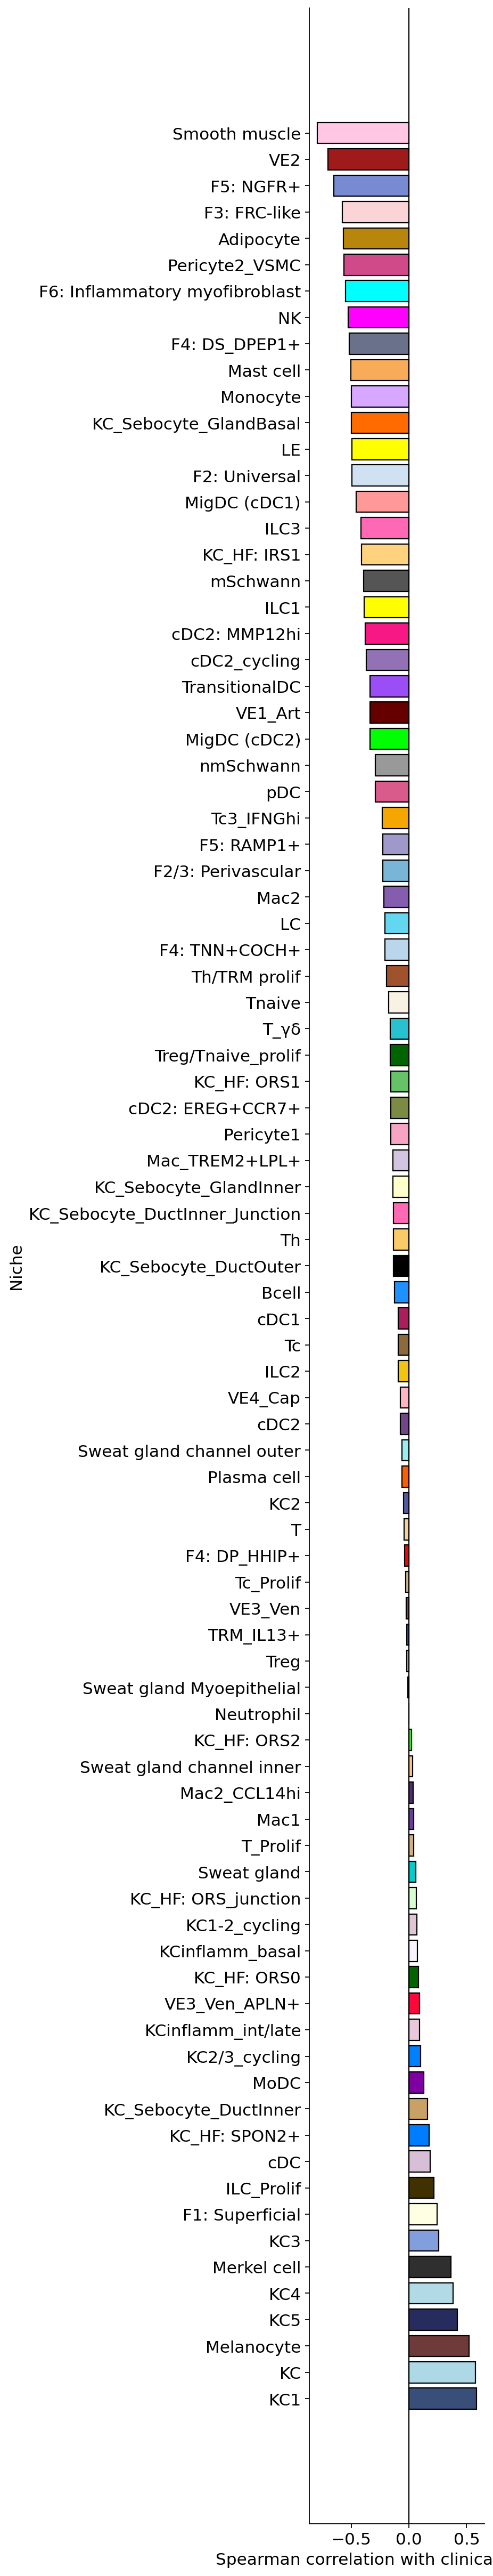

In [49]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"

# 1. Niche proportions per patient (filling 0s for absent niches)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# 2. Long format + attach response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long = props_long.dropna(subset=[RESPONSE_KEY])
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")

# 3. Spearman per niche
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 4. Bar plot
fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))
bar_colors = [colors_cells[n] for n in corr_df["niche19"]]
ax.barh(corr_df["niche19"], corr_df["spearman_r"], color=bar_colors, edgecolor="black")

for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.05:
        ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.grid(False)                              # ← remove background grid
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

                     niche19  spearman_r   p_value  n_patients     p_adj
3            Epidermis_basal    0.594147  0.091583           9  0.327083
5              Epidermis_mid    0.502096  0.168397           9  0.433282
6            Epidermis_upper    0.217575  0.573875           9  0.755098
17            Sebaceous_duct    0.172269  0.657620           9  0.782881
12          Papillary_dermis    0.142261  0.715032           9  0.812537
22       Sweat_gland_channel    0.108788  0.780554           9  0.820800
0       EpidermisInflamm_mid    0.105042  0.787968           9  0.820800
21               Sweat_gland   -0.065553  0.866934           9  0.866934
13                Perineural   -0.184102  0.635383           9  0.782881
23                Tzone-like   -0.217575  0.573875           9  0.755098
20                  Small_BV   -0.217575  0.573875           9  0.755098
14          Plasma_cell_rich   -0.218746  0.571763           9  0.755098
8                   HF_outer   -0.272363  0.478312 

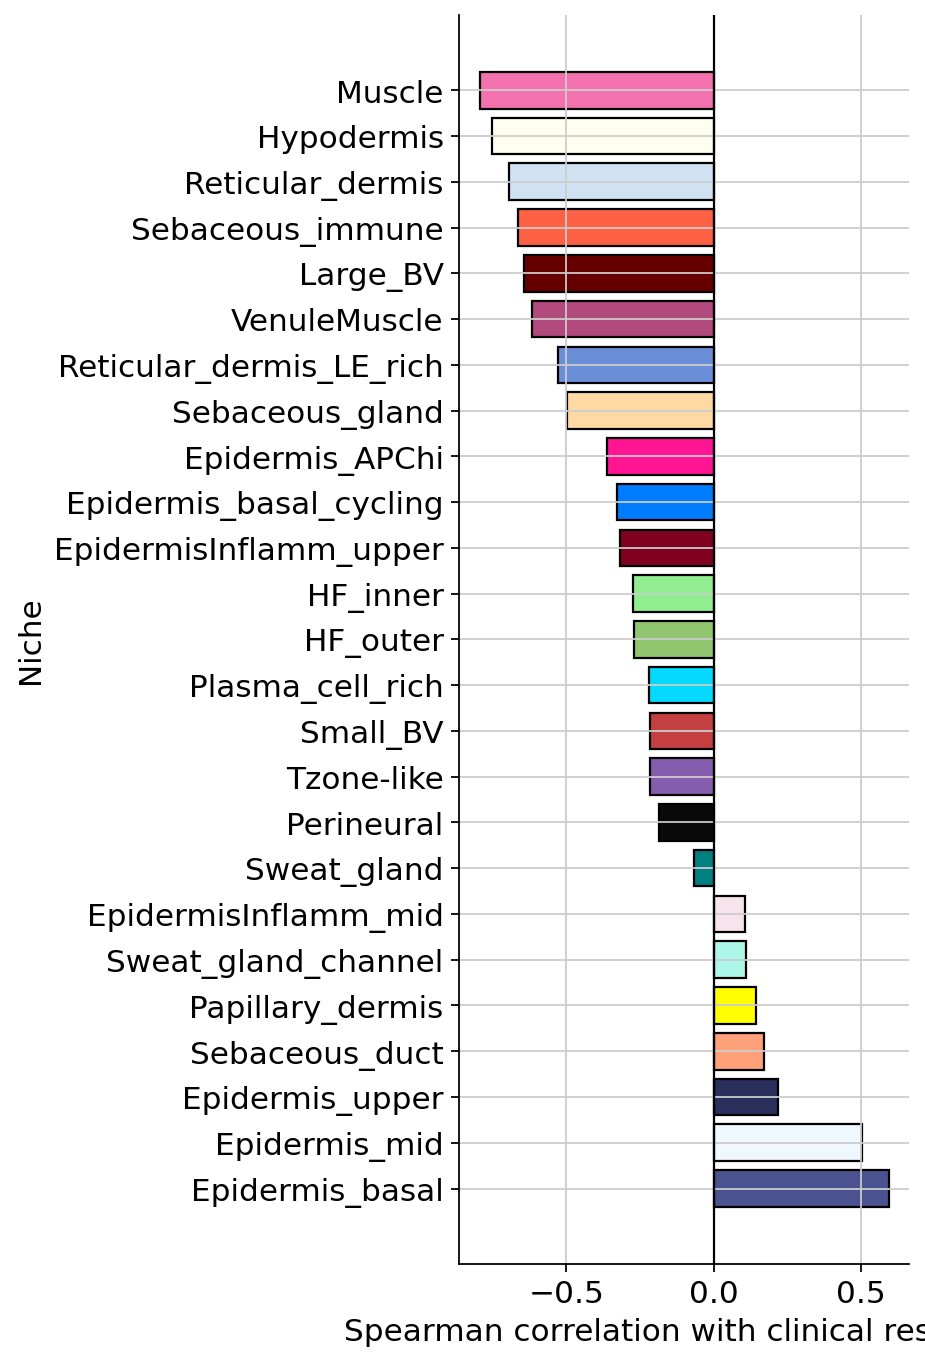

In [50]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"

# 1. Niche proportions per patient (filling 0s for absent niches)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)  # row-normalize

# 2. Long format + attach response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)

# Drop patients with missing response
props_long = props_long.dropna(subset=[RESPONSE_KEY])
# Ensure response is numeric
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")

# 3. Spearman per niche
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 4. Bar plot
fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
ax.barh(corr_df["niche19"], corr_df["spearman_r"], color=bar_colors, edgecolor="black")

# Mark significant niches (FDR < 0.05)
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.05:
        ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

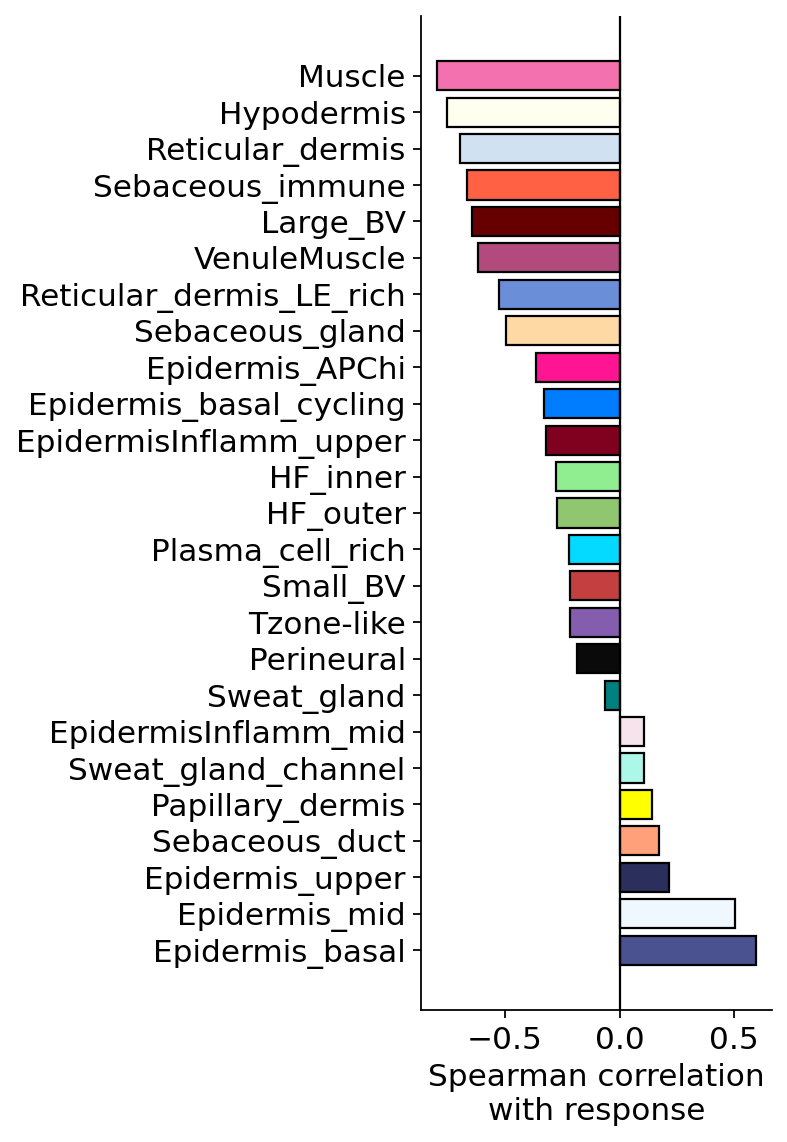

In [51]:
# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

# Explicit colors in correct order
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black"
)

# Reference line
ax.axvline(0, color="black", linewidth=1)

# Labels
ax.set_xlabel("Spearman correlation\nwith response")
ax.set_ylabel("")          # remove ylabel

# Remove grid explicitly
ax.grid(False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Prevent xlabel cutoff
plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)

plt.savefig("22c.pdf", dpi=300, bbox_inches="tight") 


plt.show()




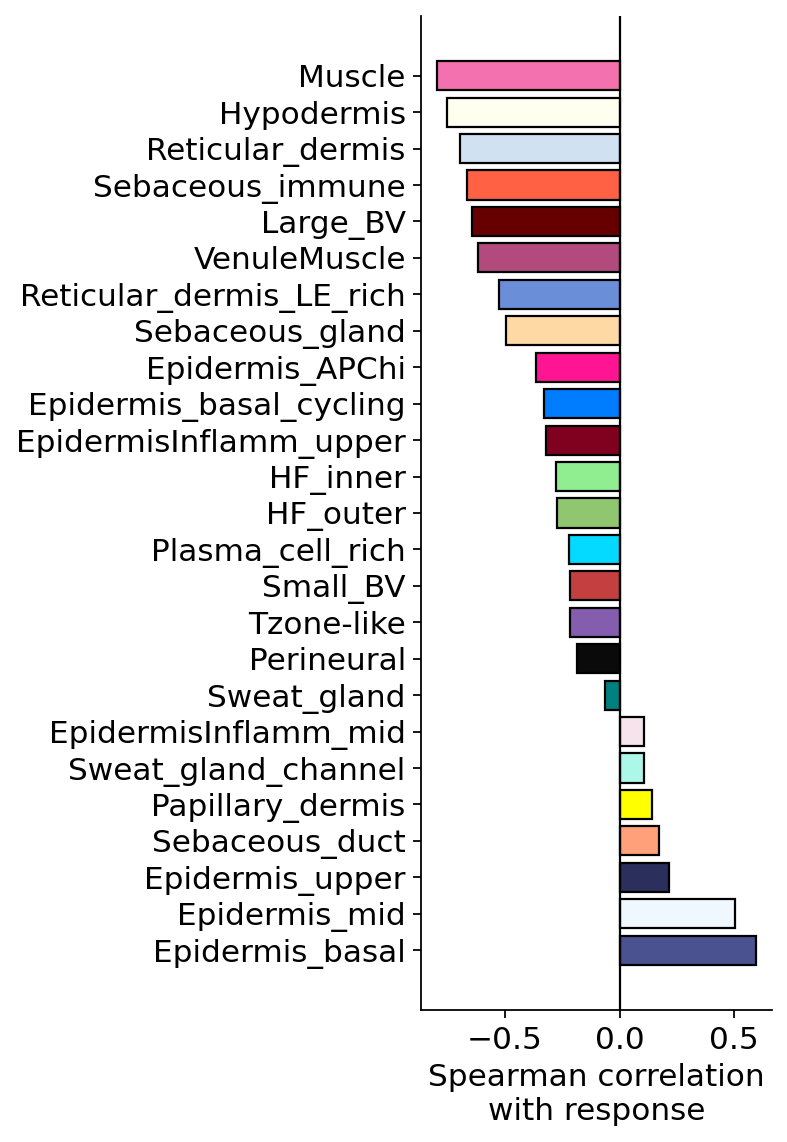

In [52]:
# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black",
)

# Significance stars from FDR-adjusted p-values
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.001:
        stars = "***"
    elif row["p_adj"] < 0.01:
        stars = "**"
    elif row["p_adj"] < 0.05:
        stars = "*"
    else:
        continue
    offset = 0.01 if row["spearman_r"] >= 0 else -0.01
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(
        row["spearman_r"] + offset, i, stars,
        va="center", ha=ha, fontsize=11, fontweight="bold",
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation\nwith response")
ax.set_ylabel("")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)
plt.savefig("outcome_by_niche.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [53]:
# from scipy.stats import spearmanr
# from statsmodels.stats.multitest import multipletests

# # --------------------------------------------------
# # 1. Compute Spearman correlation per niche (if not already done)
# # --------------------------------------------------
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "response"

# counts = (
#     adata_time.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .unstack(fill_value=0)
# )
# props = counts.div(counts.sum(axis=1), axis=0)

# props_long = props.stack().rename("prop").reset_index()
# response_df = adata_time.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
# props_long = props_long.merge(response_df, on=SAMPLE_KEY)
# props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
# props_long = props_long.dropna(subset=[RESPONSE_KEY])

# results = []
# for niche, df_n in props_long.groupby(NICHE_KEY):
#     if df_n[SAMPLE_KEY].nunique() < 5:
#         continue
#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

# corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
# corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
# corr_df = corr_df.sort_values("spearman_r", ascending=False)
# print(corr_df)

# # --------------------------------------------------
# # 2. Bar plot of correlations across niches
# # --------------------------------------------------
# fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

# bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
# ax.barh(
#     corr_df["niche19"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black",
# )

# # Mark significance with stars (FDR-adjusted)
# for i, (_, row) in enumerate(corr_df.iterrows()):
#     if row["p_adj"] < 0.001:
#         stars = "***"
#     elif row["p_adj"] < 0.01:
#         stars = "**"
#     elif row["p_adj"] < 0.05:
#         stars = "*"
#     else:
#         continue
#     # Position the star just past the bar tip, on the same side as the bar
#     offset = 0.01 if row["spearman_r"] >= 0 else -0.01
#     ha = "left" if row["spearman_r"] >= 0 else "right"
#     ax.text(
#         row["spearman_r"] + offset, i, stars,
#         va="center", ha=ha, fontsize=11, fontweight="bold",
#     )

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation\nwith response")
# ax.set_ylabel("")
# ax.grid(False)
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)
# plt.savefig("outcome_by_niche.pdf", dpi=300, bbox_inches="tight")
# plt.show()

In [54]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np
# from scipy.stats import spearmanr

# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "response"
# TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

# # 1. Compute proportions per patient
# counts = (
#     adata_time.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .unstack(fill_value=0)
# )
# props = counts.div(counts.sum(axis=1), axis=0)

# # Extract target niches
# plot_df = props[TARGET_NICHES].reset_index()

# # 2. Attach response
# response_df = adata_time.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
# plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
# plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
# plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# # 3. Scatter plot with both niches
# fig, ax = plt.subplots(figsize=(7, 5))

# for niche in TARGET_NICHES:
#     x = plot_df[RESPONSE_KEY].values
#     y = plot_df[niche].values

#     # Scatter
#     ax.scatter(x, y,
#                color=colors_new2[niche],
#                s=60, edgecolor="black", zorder=3,
#                label=niche)

#     # Regression line
#     z = np.polyfit(x, y, 1)
#     xs = np.linspace(x.min(), x.max(), 100)
#     ax.plot(xs, np.polyval(z, xs), "--",
#             color=colors_new2[niche], linewidth=1.5, zorder=2)

#     # Correlation stat
#     r, p = spearmanr(x, y)
#     print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}")

# # Label each point with patient ID (once, using response as x)
# # Only label on the first niche's points to avoid duplicate clutter
# for _, row in plot_df.iterrows():
#     ax.annotate(row[SAMPLE_KEY],
#                 (row[RESPONSE_KEY], row[TARGET_NICHES[0]]),
#                 xytext=(5, 5), textcoords="offset points",
#                 fontsize=7, color="gray")

# ax.set_xlabel("Response (% improvement)")
# ax.set_ylabel("Proportion of niche")
# ax.set_title("Sebaceous niches vs. clinical response")
# ax.legend(frameon=False, loc="best")
# ax.spines[["top", "right"]].set_visible(False)
# ax.grid(False)
# plt.tight_layout()
# plt.show()

Sebaceous_immune: ρ = -0.67, p = 0.050
Sebaceous_duct: ρ = 0.17, p = 0.658


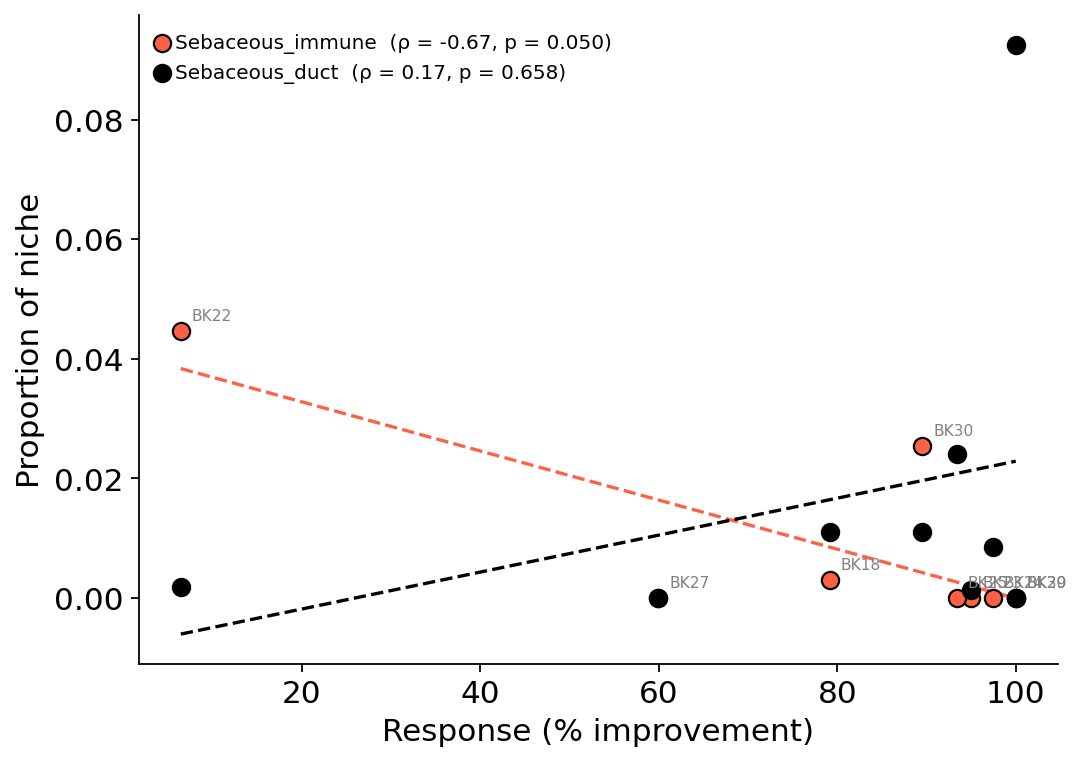

In [55]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

# 👇 Color overrides for this plot only
niche_colors = {niche: colors_new2[niche] for niche in TARGET_NICHES}
niche_colors["Sebaceous_duct"] = "black"

# 1. Compute proportions per patient
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)
plot_df = props[TARGET_NICHES].reset_index()

# 2. Attach response
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Scatter plot with both niches
fig, ax = plt.subplots(figsize=(7, 5))

for niche in TARGET_NICHES:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[niche].values
    r, p = spearmanr(x, y)
    label = f"{niche}  (ρ = {r:.2f}, p = {p:.3f})"

    # Scatter — use niche_colors instead of colors_new2
    ax.scatter(x, y,
               color=niche_colors[niche],
               s=60, edgecolor="black", zorder=3,
               label=label)

    # Regression line
    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(z, xs), "--",
            color=niche_colors[niche], linewidth=1.5, zorder=2)

    print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}")

# Label each point with patient ID
for _, row in plot_df.iterrows():
    ax.annotate(row[SAMPLE_KEY],
                (row[RESPONSE_KEY], row[TARGET_NICHES[0]]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7, color="gray")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.set_title("")
ax.legend(frameon=False, loc="best", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("22d.pdf", dpi=300, bbox_inches="tight") 

plt.show()

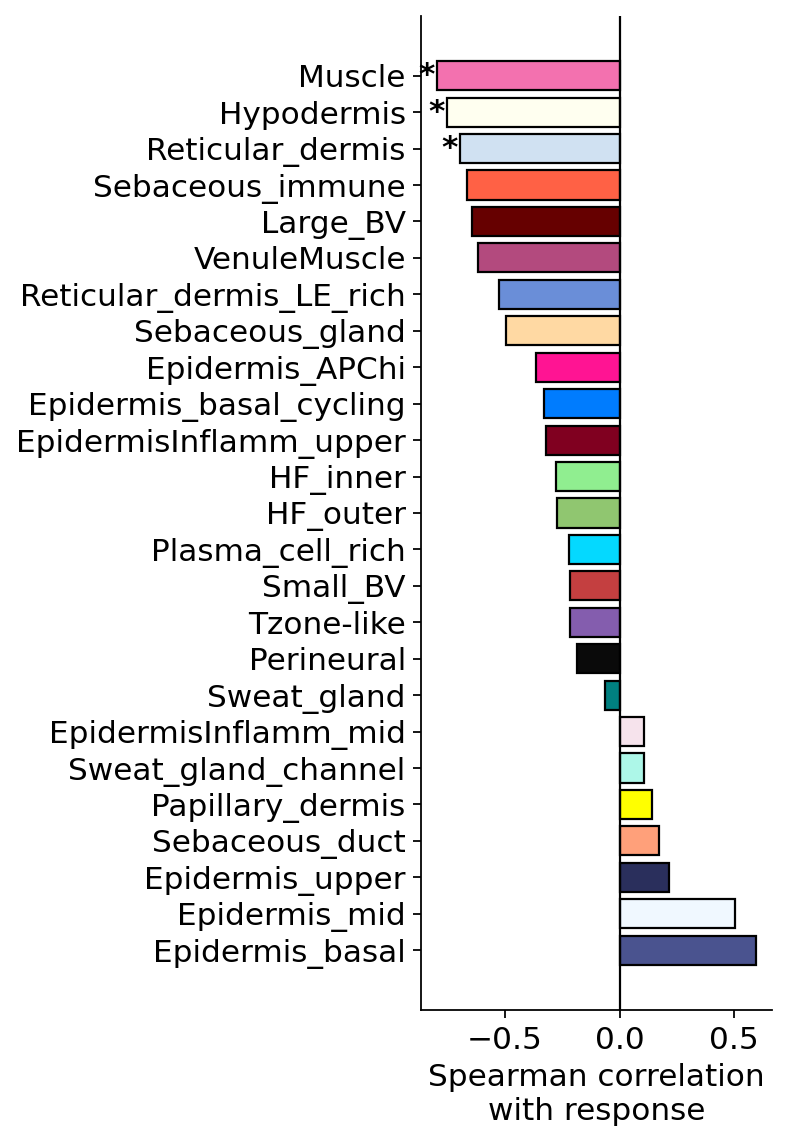

In [56]:
# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black",
)

# Add significance stars next to significant bars
PCOL = "p_value"   # change to "p_adj" if you want FDR-adjusted
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row[PCOL] >= 0.05:
        continue
    # Star sits just past the bar tip, on the same side
    offset = 0.01 if row["spearman_r"] >= 0 else -0.01
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(
        row["spearman_r"] + offset, i, "*",
        va="center", ha=ha,
        fontsize=14, fontweight="bold",
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation\nwith response")
ax.set_ylabel("")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)
plt.savefig("outcome_by_niche_validation.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [57]:
# s

# outcome mintflow

In [58]:
import scanpy as sc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
#import squidpy as sq
import anndata as ad

import warnings
#import squidpy as sq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
  
warnings.simplefilter("ignore", category=UserWarning)

warnings.simplefilter("ignore", category=FutureWarning)  

adata_time=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_newtime_mintflow_annotated.h5ad')


In [59]:
adata_time.obs["Timepoint"].value_counts()

Timepoint
nan                          203397
Day 3                        110594
Day 14                        78274
wk4 Relapse                   52136
Past Lesional wk4 Relapse     32472
Week 4 (resolved)             31018
Name: count, dtype: int64

In [60]:
RENAME={"Sebaceous_duct outlier/epidermis": "Sebaceous_duct"}

adata_time.obs["niche19"]=adata_time.obs["niche19"].map(RENAME).fillna(adata_time.obs["niche19"])

In [61]:
adata_time = adata_time[adata_time.obs["Site_status"]!="Week 4 (resolved)"]
adata_time = adata_time[adata_time.obs["Timepoint"]!="Past Lesional wk4 Relapse"]
adata_time = adata_time[adata_time.obs["Timepoint"]!="Week 4 (resolved)"]
adata_time = adata_time[adata_time.obs["Timepoint"]!="wk4 Relapse"]
adata_time = adata_time[adata_time.obs["Timepoint"]!="Day 3"]
adata_time = adata_time[adata_time.obs["Timepoint2"]!="Week 12"]
adata_time = adata_time[adata_time.obs["Timepoint2"]!="Day 14"]

adata_time=adata_time[adata_time.obs["niche19"]!="Missing"]
#adata_time = adata_time[adata_time.obs["Timepoint"]=="Day 14"]



In [62]:
adata_time.obs["Timepoint"].value_counts()

Timepoint
nan    190196
Name: count, dtype: int64

In [63]:
adata_time.obs.info_id6.value_counts()

info_id6
BK44-SKI-27-FO-1-S4-E2    30151
BK40-SKI-27-FO-1-S4-D2    29527
BK68-SKI-27-FO-1-S4-B2    24602
BK65-SKI-21-FO-1-S4-B1    19762
BK36-SKI-27-FO-1-S4-D1    19285
BK42-SKI-27-FO-1-S4-C2    19273
BK36-SKI-27-FO-1-S5-E1    18809
BK37-SKI-27-FO-1-S4-C1    14787
BK58-SKI-27-FO-1-S5-A1    14000
Name: count, dtype: int64

In [64]:
adata_time.obs.info_id6.nunique()

9

In [65]:
adata_time.shape

(190196, 5001)

In [66]:
adata_time.obs.Timepoint2.value_counts()

Timepoint2
Lesional Baseline    190196
Name: count, dtype: int64

In [67]:
112+17+9 

138

In [68]:
# adata_time.obs.Timepoint.value_counts()()

In [69]:
easi_response = {
    "BK21": "7.69",
    "BK22": "6.43",
    "BK58": "9.64",
    "BK59": "91.33",
    "BK65": "35.92",
    "BK68": "3.25",
    "BK18": "79.14",
    "BK19": "59.65",
    "BK20": "100.00",
    "BK23": "94.98",
    "BK24": "97.40",
    "BK25": "93.39",
    "BK26": "92.75",
    "BK30": "89.53",
    "BK38": "72.56",
    "BK39": "100.00",
    "BK41": "73.43",
    "BK60": "100.00",
    "BK61": "82.44",
    "BK62": "92.87",
    "BK63": "65.06",
    "BK64": "100.00",
    "BK67": "78.26",
    "BK69": "61.08",
    "BK71": "-6.93",
    "BK37": "44.03",
    "BK42": "14.89",
    "BK78": "-13.33",
    "BK36": "71.09",
    "BK40": "84.94",
    "BK44": "78.68",
    "BK66": "100.00",
    "BK76": "100.00",
    "BK28": "27.82",
    "BK29": "4.85",
    "BK47": "10.89",
    "BK27": "59.92",
    "BK31": "95.16",
    "BK45": "82.99",
    "BK48": "69.75",
    "BK75": "85.84",
    "BK77": "87.04",
    "BK79": "95.24",
}

adata_time.obs["response"]=adata_time.obs["Sanger patient ID"].map(easi_response)
# adata.obs["response"].value_counts()

patient_to_response = adata_time.obs.drop_duplicates("Sanger patient ID").set_index("Sanger patient ID")["response"].to_dict()
patient_to_response

 


{'BK68': '3.25',
 'BK58': '9.64',
 'BK65': '35.92',
 'BK36': '71.09',
 'BK40': '84.94',
 'BK44': '78.68',
 'BK37': '44.03',
 'BK42': '14.89'}

In [70]:
import pickle
with open('/nfs/team298/ls34/dict/niche19_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)
    
colors_new2 = colors_new2 | {'Sebaceous_duct outlier/epidermis' : "#8B95A1"}

In [71]:
easi_response = {
    "BK21": "7.69",
    "BK22": "6.43",
    "BK58": "9.64",
    "BK59": "91.33",
    "BK65": "35.92",
    "BK68": "3.25",
    "BK18": "79.14",
    "BK19": "59.65",
    "BK20": "100.00",
    "BK23": "94.98",
    "BK24": "97.40",
    "BK25": "93.39",
    "BK26": "92.75",
    "BK30": "89.53",
    "BK38": "72.56",
    "BK39": "100.00",
    "BK41": "73.43",
    "BK60": "100.00",
    "BK61": "82.44",
    "BK62": "92.87",
    "BK63": "65.06",
    "BK64": "100.00",
    "BK67": "78.26",
    "BK69": "61.08",
    "BK71": "-6.93",
    "BK37": "44.03",
    "BK42": "14.89",
    "BK78": "-13.33",
    "BK36": "71.09",
    "BK40": "84.94",
    "BK44": "78.68",
    "BK66": "100.00",
    "BK76": "100.00",
    "BK28": "27.82",
    "BK29": "4.85",
    "BK47": "10.89",
    "BK27": "59.92",
    "BK31": "95.16",
    "BK45": "82.99",
    "BK48": "69.75",
    "BK75": "85.84",
    "BK77": "87.04",
    "BK79": "95.24",
}

# adata.obs["response"].value_counts()

patient_to_response = adata_time.obs.drop_duplicates("Sanger patient ID").set_index("Sanger patient ID")["response"].to_dict()
patient_to_response

 


{'BK68': '3.25',
 'BK58': '9.64',
 'BK65': '35.92',
 'BK36': '71.09',
 'BK40': '84.94',
 'BK44': '78.68',
 'BK37': '44.03',
 'BK42': '14.89'}

In [72]:
adata_time.shape

(190196, 5001)

                  niche19  spearman_r   p_value  n_patients     p_adj
9        Papillary_dermis    0.690476  0.057990           8  0.405932
19             Tzone-like    0.595238  0.119530           8  0.523318
13         Sebaceous_duct    0.523810  0.182721           8  0.523318
2         Epidermis_basal    0.214286  0.610344           8  0.854482
5                HF_outer    0.136386  0.747429           8  0.860874
1    EpidermisInflamm_mid    0.121988  0.773532           8  0.860874
16               Small_BV   -0.023810  0.955374           8  0.955374
3          Epidermis_late   -0.071429  0.866526           8  0.909853
10             Perineural   -0.119048  0.778886           8  0.860874
7                Large_BV   -0.119048  0.778886           8  0.860874
8                  Muscle   -0.214286  0.610344           8  0.854482
18    Sweat_gland_channel   -0.238095  0.570156           8  0.854482
15       Sebaceous_immune   -0.264979  0.525931           8  0.854482
4           Epidermi

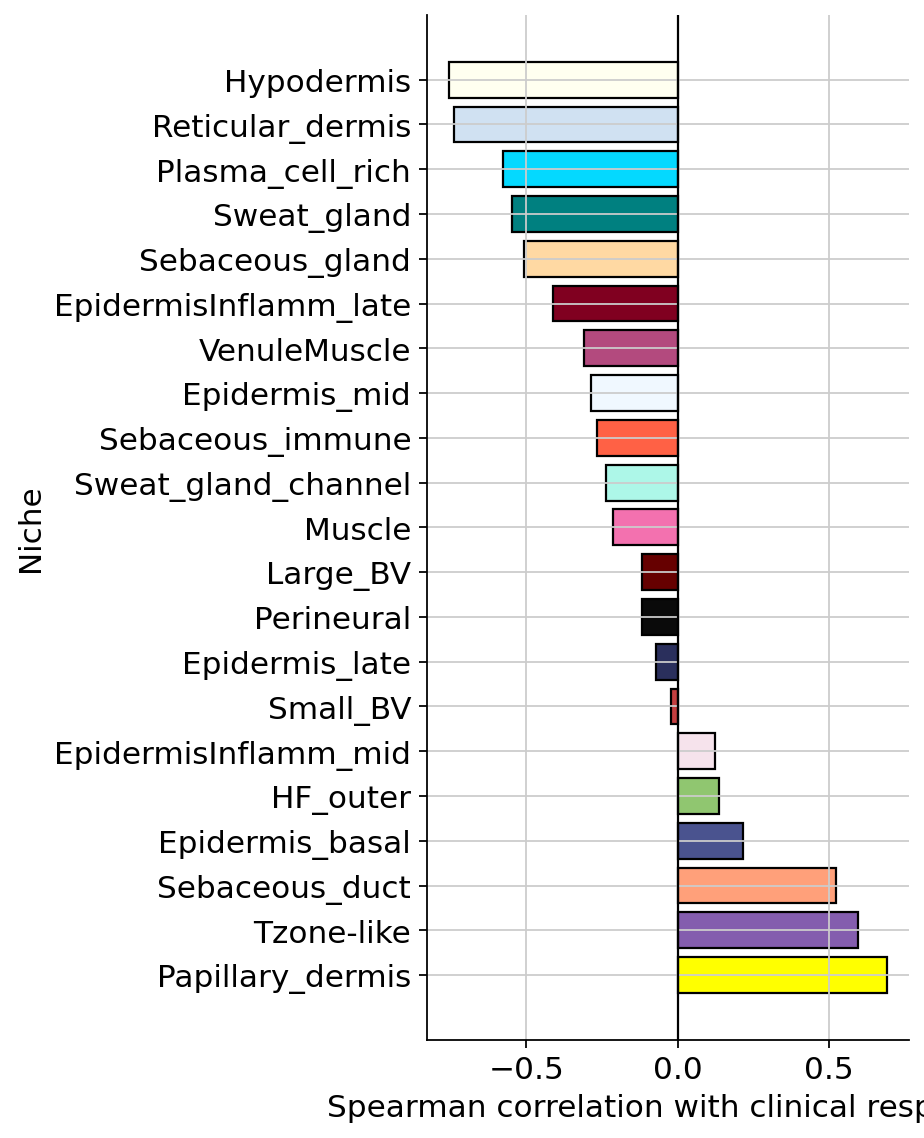

In [73]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"

# 1. Niche proportions per patient (filling 0s for absent niches)
counts = (
    adata_time.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)  # row-normalize

# 2. Long format + attach response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_time.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)

# Drop patients with missing response
props_long = props_long.dropna(subset=[RESPONSE_KEY])
# Ensure response is numeric
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")

# 3. Spearman per niche
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 4. Bar plot
fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
ax.barh(corr_df["niche19"], corr_df["spearman_r"], color=bar_colors, edgecolor="black")

# Mark significant niches (FDR < 0.05)
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.05:
        ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [74]:
colors_new2

{'Epidermis_basal': '#4a538f',
 'Epidermis basal': '#3489f1',
 'Epidermis_mid': '#F0F8FF',
 'Epidermis_late': '#2a2f5c',
 'Epidermis basal_cycling': '#007cfe',
 'Epidermis_basal_cycling': '#007cfe',
 'EpidermisInflamm_mid': '#f6e3ec',
 'EpidermisInflamm_late': '#800020',
 'Epidermis_APChi': '#ff1493',
 'Papillary_dermis': '#FFFF00',
 'Small blood vessel': '#d73435',
 'Sweat_gland': '#008080',
 'Sweat_gland_channel': '#adf7e8',
 'Muscle': '#f371af',
 'Adipocyte+vessels': '#B8860B',
 'Hypodermis': '#FFFFF0',
 'Larger blood vessel': '#660000',
 'Perineural': '#0A0A0A',
 'Nonspecific': '#D3D3D3',
 'Reticular_dermis': '#d0e1f2',
 'Large_BV': '#660000',
 'Small_BV': '#c43f40',
 'Tzone-like': '#845DAE',
 'Sebaceous_gland': '#FFD9A3',
 'Sebaceous_immune': '#ff6145',
 'Plasma_cell_rich': '#04D9FF',
 'HF_Perineural': '#00FF00',
 'OuterHF': '#006600',
 'Sebaceous duct': '#e28743',
 'Lymphoid Tzone-like': '#825bac',
 'Reticular_dermis_LE_rich': '#6A8ED8',
 'Reticular_dermis_LErich': '#6A8ED8',
 'S

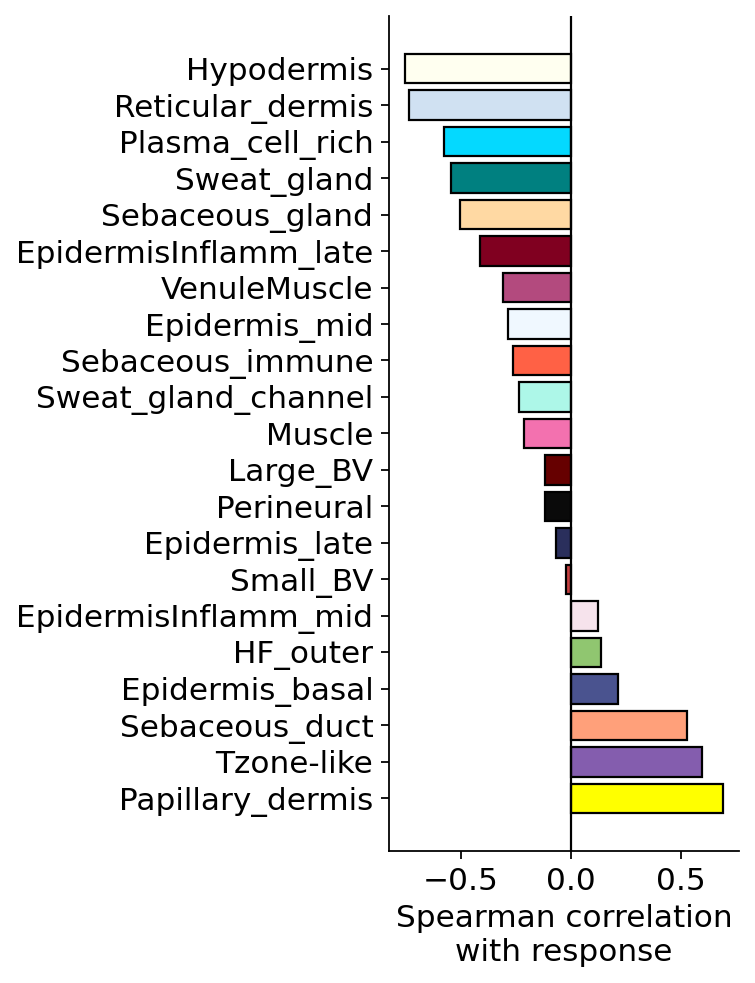

In [75]:
# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

# Explicit colors in correct order
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black"
)

# Reference line
ax.axvline(0, color="black", linewidth=1)

# Labels
ax.set_xlabel("Spearman correlation\nwith response")
ax.set_ylabel("")          # remove ylabel

# Remove grid explicitly
ax.grid(False)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Prevent xlabel cutoff
plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)

plt.savefig("22e.pdf", dpi=300, bbox_inches="tight")  # 👈 add here


plt.show()




In [76]:
# adata_i.obs["Sanger patient ID"].value_counts()

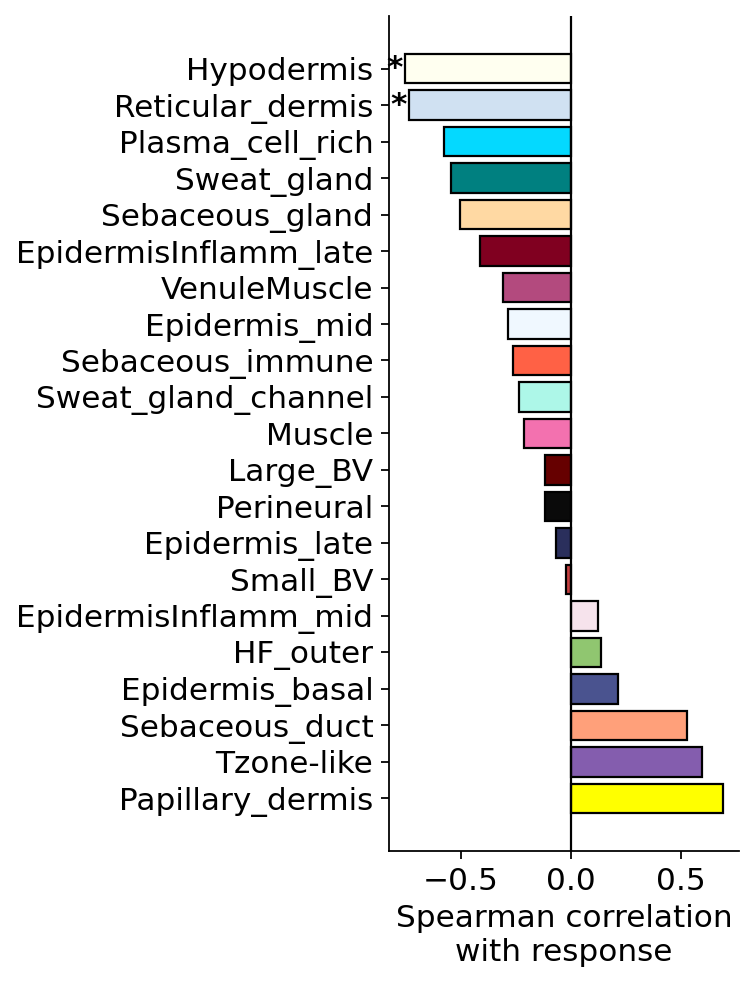

In [77]:
# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black",
)

# Add significance stars next to significant bars
PCOL = "p_value"   # change to "p_adj" if you want FDR-adjusted
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row[PCOL] >= 0.05:
        continue
    # Star sits just past the bar tip, on the same side
    offset = 0.01 if row["spearman_r"] >= 0 else -0.01
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(
        row["spearman_r"] + offset, i, "*",
        va="center", ha=ha,
        fontsize=14, fontweight="bold",
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation\nwith response")
ax.set_ylabel("")
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)
plt.savefig("outcome_by_niche_validation.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [78]:
adata_time.obs["scanvi_predictions"].value_counts()

scanvi_predictions
nan    190196
Name: count, dtype: int64

In [79]:
# adata_ii=adata_time[(adata_time.obs["lvl5_annotation"].str.startswith("TRM_IL13"))
#                 ]
# adata_ii.obs["niche19_celltype"].value_counts()

In [80]:
# adata_ii=adata_time[(adata_time.obs["lvl5_annotation"].str.startswith("TRM_IL13"))
#                 ]
# adata_ii

In [81]:
# adata_time.obs["niche19_celltype"].value_counts()

adata_ii cells: 831
niche19_celltype categories kept: 8
                      niche19  spearman_r   p_value  n_patients     p_adj
7        Tzone-like_TRM_IL13+    0.750000  0.052181           7  0.285374
6          Small_BV_TRM_IL13+    0.714286  0.071344           7  0.285374
0   Epidermis_basal_TRM_IL13+    0.464286  0.293934           7  0.672036
4    Sebaceous_duct_TRM_IL13+    0.162169  0.728300           7  0.832342
1    Epidermis_late_TRM_IL13+   -0.090094  0.847672           7  0.847672
2     Epidermis_mid_TRM_IL13+   -0.306319  0.504027           7  0.672036
3  Papillary_dermis_TRM_IL13+   -0.321429  0.482072           7  0.672036
5  Sebaceous_immune_TRM_IL13+   -0.408248  0.363217           7  0.672036


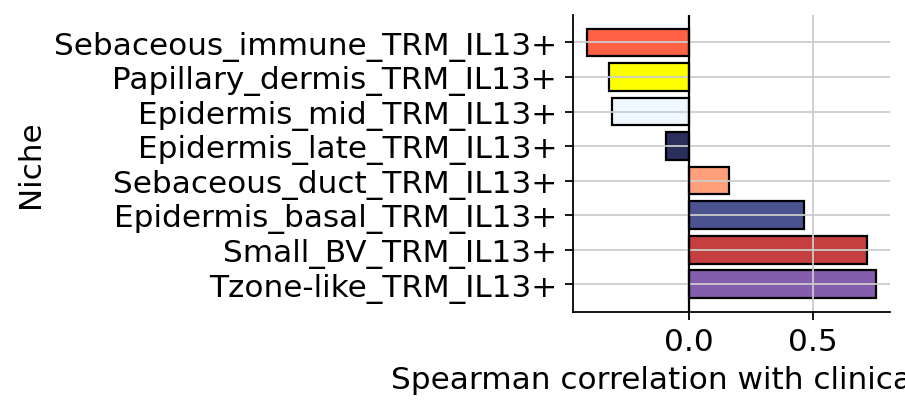

<Figure size 640x640 with 0 Axes>

In [82]:
# from scipy.stats import spearmanr
# from statsmodels.stats.multitest import multipletests
# adata_time.obs["niche19_celltype"]=adata_time.obs["niche19"].astype(str) + "_" +  adata_time.obs["lvl5_annotation"].astype(str)
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19_celltype"
# RESPONSE_KEY = "response"
# # adata_ii=adata_i[(adata_i.obs["lvl5_annotation"].str.startswith("T"))|
# #                  (adata_i.obs["lvl5_annotation"].str.startswith("ILC"))
# #                 ]
# adata_ii=adata_time[(adata_time.obs["lvl5_annotation"].str.startswith("TRM_IL13"))
#                 ]

# vc = adata_ii.obs["niche19_celltype"].value_counts()
# keep = vc[vc >= 10].index

# adata_ii = adata_ii[adata_ii.obs["niche19_celltype"].isin(keep)].copy()

 
# # 1. Niche proportions per patient (filling 0s for absent niches)
# counts = (
#     adata_ii.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .unstack(fill_value=0)
# )
# props = counts.div(counts.sum(axis=1), axis=0)  # row-normalize

# # 2. Long format + attach response
# props_long = props.stack().rename("prop").reset_index()
# response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
# props_long = props_long.merge(response_df, on=SAMPLE_KEY)

# # Drop patients with missing response
# props_long = props_long.dropna(subset=[RESPONSE_KEY])
# # Ensure response is numeric
# props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")

# # 3. Spearman per niche
# results = []
# for niche, df_n in props_long.groupby(NICHE_KEY):
#     if df_n[SAMPLE_KEY].nunique() < 5:
#         continue
#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

# #corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
# #corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
# #corr_df = corr_df.sort_values("spearman_r", ascending=False)
# #print(corr_df)

# # 4. Bar plot
# fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))
# #bar_colors = [colors_new2[n] for n in corr_df["niche19"]]
# ax.barh(corr_df["niche19"], corr_df["spearman_r"], #color=bar_colors, 
#         edgecolor="black")

# # # Mark significant niches (FDR < 0.05)
# # for i, (_, row) in enumerate(corr_df.iterrows()):
# #     if row["p_adj"] < 0.05:
# #         ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with clinical response")
# ax.set_ylabel("Niche")
# ax.spines[["top", "right"]].set_visible(False)
# plt.tight_layout()
# plt.show()


from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

adata_time.obs["niche19_celltype"] = (
    adata_time.obs["niche19"].astype(str) + "_" + adata_time.obs["lvl5_annotation"].astype(str)
)

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19_celltype"
RESPONSE_KEY = "response"

# Subset to TRM_IL13+ cells
adata_ii = adata_time[adata_time.obs["lvl5_annotation"].str.startswith("TRM_IL13")].copy()

# Drop niche×celltype combos with fewer than 10 cells
vc = adata_ii.obs["niche19_celltype"].value_counts()
keep = vc[vc >= 10].index
adata_ii = adata_ii[adata_ii.obs["niche19_celltype"].isin(keep)].copy()

print(f"adata_ii cells: {adata_ii.n_obs}")
print(f"niche19_celltype categories kept: {len(keep)}")

# 1. Per-patient niche proportions
counts = (
    adata_ii.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# 2. Long format + attach response  (use adata_ii, not adata_i!)
props_long = props.stack().rename("prop").reset_index()
response_df = adata_ii.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
props_long = props_long.dropna(subset=[RESPONSE_KEY])

# 3. Spearman per niche
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])

# Guard against empty results — this is what was crashing the plot
if len(corr_df) == 0:
    raise RuntimeError(
        "No niches passed the minimum 5-patient threshold. "
        "Check that NICHE_KEY has enough patients per category."
    )

corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 4. Bar plot
# Strip the celltype suffix to get back the original niche name
def get_niche(name):
    # Everything before the last "_TRM_" — handles names that themselves contain underscores
    return name.rsplit("_TRM_", 1)[0]

bar_colors = [
    colors_new2.get(get_niche(n), "#cccccc")   # fallback to grey if unmapped
    for n in corr_df["niche19"]
]

fig, ax = plt.subplots(figsize=(6, max(2, 0.35 * len(corr_df))))
ax.barh(corr_df["niche19"], corr_df["spearman_r"],
        color=bar_colors, edgecolor="black")

for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.001:
        stars = "***"
    elif row["p_adj"] < 0.01:
        stars = "**"
    elif row["p_adj"] < 0.05:
        stars = "*"
    else:
        continue
    offset = 0.02 if row["spearman_r"] >= 0 else -0.02
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(row["spearman_r"] + offset, i, stars,
            va="center", ha=ha, fontsize=11, fontweight="bold")

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
    
    
    
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

adata_ii cells: 831
niche19_celltype categories kept: 8
                      niche19  spearman_r   p_value  n_patients     p_adj
7        Tzone-like_TRM_IL13+    0.750000  0.052181           7  0.285374
6          Small_BV_TRM_IL13+    0.714286  0.071344           7  0.285374
0   Epidermis_basal_TRM_IL13+    0.464286  0.293934           7  0.672036
4    Sebaceous_duct_TRM_IL13+    0.162169  0.728300           7  0.832342
1    Epidermis_late_TRM_IL13+   -0.090094  0.847672           7  0.847672
2     Epidermis_mid_TRM_IL13+   -0.306319  0.504027           7  0.672036
3  Papillary_dermis_TRM_IL13+   -0.321429  0.482072           7  0.672036
5  Sebaceous_immune_TRM_IL13+   -0.408248  0.363217           7  0.672036


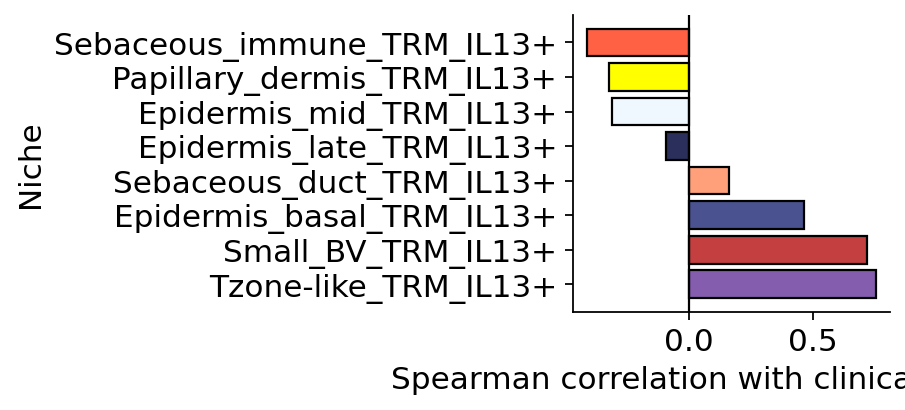

In [83]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

adata_time.obs["niche19_celltype"] = (
    adata_time.obs["niche19"].astype(str) + "_" + adata_time.obs["lvl5_annotation"].astype(str)
)

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19_celltype"
RESPONSE_KEY = "response"

# Subset to TRM_IL13+ cells
adata_ii = adata_time[adata_time.obs["lvl5_annotation"].str.startswith("TRM_IL13")].copy()

# Drop niche×celltype combos with fewer than 10 cells
vc = adata_ii.obs["niche19_celltype"].value_counts()
keep = vc[vc >= 10].index
adata_ii = adata_ii[adata_ii.obs["niche19_celltype"].isin(keep)].copy()

print(f"adata_ii cells: {adata_ii.n_obs}")
print(f"niche19_celltype categories kept: {len(keep)}")

# 1. Per-patient niche proportions
counts = (
    adata_ii.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# 2. Long format + attach response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_ii.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
props_long = props_long.dropna(subset=[RESPONSE_KEY])

# 3. Spearman per niche
results = []
for niche, df_n in props_long.groupby(NICHE_KEY):
    if df_n[SAMPLE_KEY].nunique() < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, df_n[SAMPLE_KEY].nunique()))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])

if len(corr_df) == 0:
    raise RuntimeError(
        "No niches passed the minimum 5-patient threshold. "
        "Check that NICHE_KEY has enough patients per category."
    )

corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 4. Bar plot
def get_niche(name):
    return name.rsplit("_TRM_", 1)[0]

bar_colors = [
    colors_new2.get(get_niche(n), "#cccccc")
    for n in corr_df["niche19"]
]

fig, ax = plt.subplots(figsize=(6, max(2, 0.35 * len(corr_df))))
ax.barh(corr_df["niche19"], corr_df["spearman_r"],
        color=bar_colors, edgecolor="black")

for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.001:
        stars = "***"
    elif row["p_adj"] < 0.01:
        stars = "**"
    elif row["p_adj"] < 0.05:
        stars = "*"
    else:
        continue
    offset = 0.02 if row["spearman_r"] >= 0 else -0.02
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(row["spearman_r"] + offset, i, stars,
            va="center", ha=ha, fontsize=11, fontweight="bold")

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.grid(False)                              # ← remove background grid
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("22f2.pdf", dpi=300, bbox_inches="tight") 

plt.show()

Sebaceous_immune: ρ = -0.26, p = 0.526
Sebaceous_duct: ρ = 0.52, p = 0.183


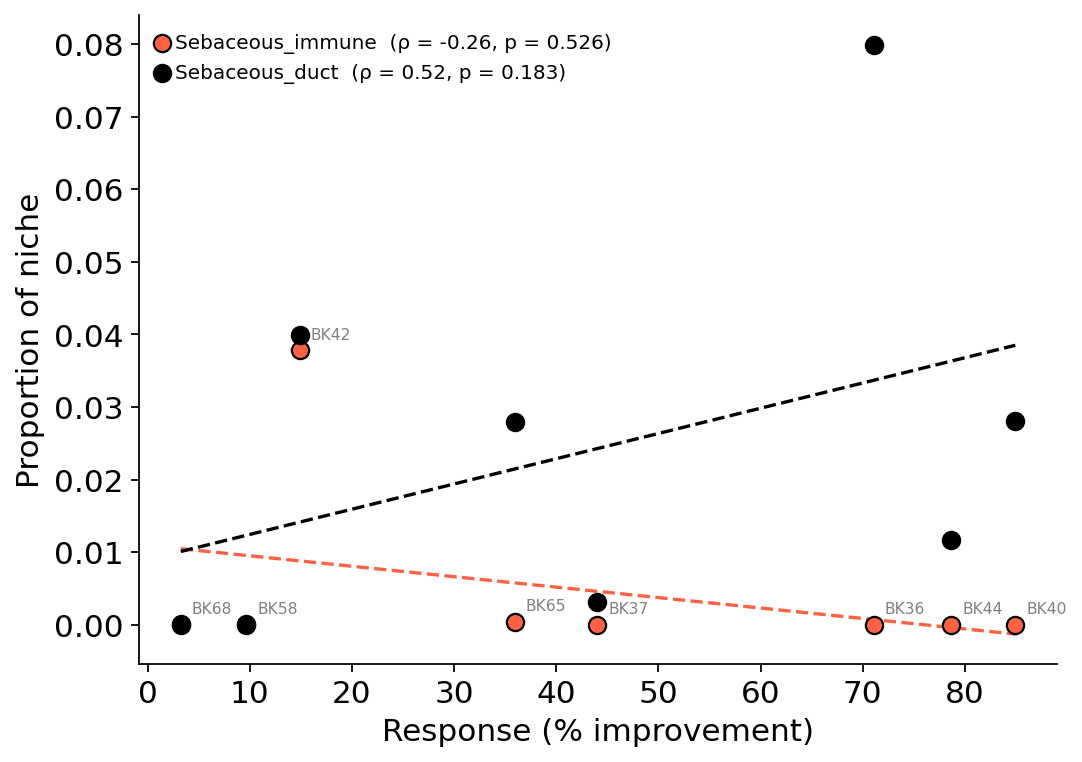

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

# 👇 Color overrides for this plot only
niche_colors = {niche: colors_new2[niche] for niche in TARGET_NICHES}
niche_colors["Sebaceous_duct"] = "black"

# 1. Compute proportions per patient
counts = (
    adata_time.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)
plot_df = props[TARGET_NICHES].reset_index()

# 2. Attach response
response_df = adata_time.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Scatter plot with both niches
fig, ax = plt.subplots(figsize=(7, 5))

for niche in TARGET_NICHES:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[niche].values
    r, p = spearmanr(x, y)
    label = f"{niche}  (ρ = {r:.2f}, p = {p:.3f})"

    # Scatter — use niche_colors instead of colors_new2
    ax.scatter(x, y,
               color=niche_colors[niche],
               s=60, edgecolor="black", zorder=3,
               label=label)

    # Regression line
    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(z, xs), "--",
            color=niche_colors[niche], linewidth=1.5, zorder=2)

    print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}")

# Label each point with patient ID
for _, row in plot_df.iterrows():
    ax.annotate(row[SAMPLE_KEY],
                (row[RESPONSE_KEY], row[TARGET_NICHES[0]]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7, color="gray")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.set_title("")
ax.legend(frameon=False, loc="best", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("outcome_by_sebaceous_niche.pdf", dpi=300, bbox_inches="tight")
plt.show()




Baseline Sebaceous_immune: ρ = -0.26, p = 0.526
Baseline Sebaceous_duct: ρ = 0.52, p = 0.183
Timepoint2 Sebaceous_immune: ρ = -0.67, p = 0.050
Timepoint2 Sebaceous_duct: ρ = 0.17, p = 0.658


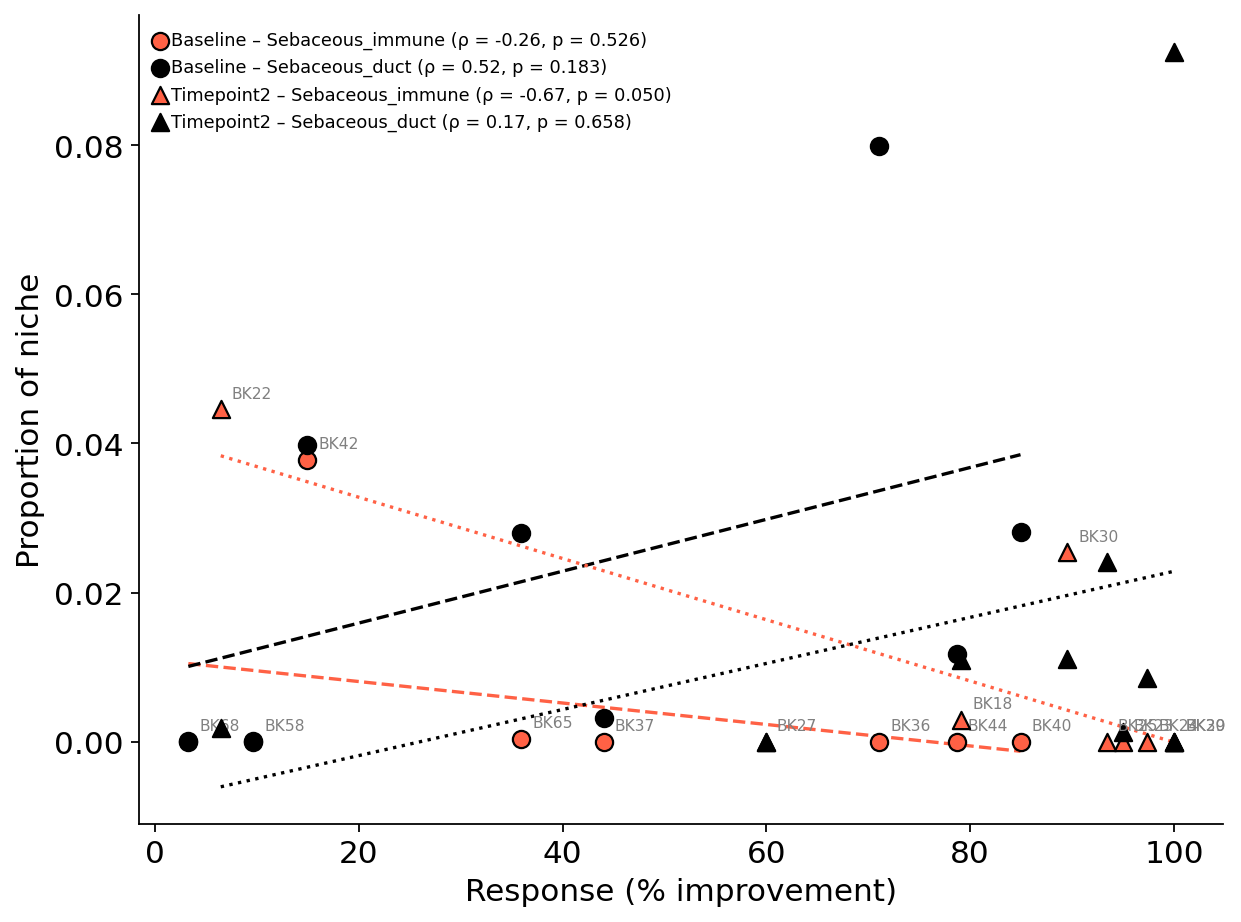

In [85]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

# Color overrides for this plot only
niche_colors = {niche: colors_new2[niche] for niche in TARGET_NICHES}
niche_colors["Sebaceous_duct"] = "black"

# Helper: compute per-patient niche proportions and merge with response
def build_plot_df(adata_obj):
    counts = (
        adata_obj.obs
        .groupby([SAMPLE_KEY, NICHE_KEY])
        .size()
        .unstack(fill_value=0)
    )
    props = counts.div(counts.sum(axis=1), axis=0)
    plot_df = props[[n for n in TARGET_NICHES if n in props.columns]].reset_index()

    resp = adata_obj.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
    plot_df = plot_df.merge(resp, on=SAMPLE_KEY)
    plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
    plot_df = plot_df.dropna(subset=[RESPONSE_KEY])
    return plot_df

datasets = {
    "Baseline":   ("o", build_plot_df(adata_time)),
    "Timepoint2": ("^", build_plot_df(adata_i)),     # rename labels as appropriate
}

fig, ax = plt.subplots(figsize=(8, 6))

for dataset_label, (marker, plot_df) in datasets.items():
    for niche in TARGET_NICHES:
        if niche not in plot_df.columns:
            continue
        x = plot_df[RESPONSE_KEY].values
        y = plot_df[niche].values
        r, p = spearmanr(x, y)
        label = f"{dataset_label} – {niche} (ρ = {r:.2f}, p = {p:.3f})"

        ax.scatter(
            x, y,
            color=niche_colors[niche],
            marker=marker,
            s=60, edgecolor="black", zorder=3,
            label=label,
        )

        # Regression line
        z = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(
            xs, np.polyval(z, xs),
            linestyle="--" if marker == "o" else ":",
            color=niche_colors[niche],
            linewidth=1.5, zorder=2,
        )

        print(f"{dataset_label} {niche}: ρ = {r:.2f}, p = {p:.3f}")

    # Label each point with patient ID (only for the first target niche to avoid clutter)
    primary_niche = TARGET_NICHES[0]
    if primary_niche in plot_df.columns:
        for _, row in plot_df.iterrows():
            ax.annotate(
                row[SAMPLE_KEY],
                (row[RESPONSE_KEY], row[primary_niche]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7, color="gray",
            )

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.legend(frameon=False, loc="best", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("outcome_by_sebaceous_niche_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

Sebaceous_immune: ρ = -0.35, p = 0.172, n = 17
Sebaceous_duct: ρ = 0.17, p = 0.524, n = 17


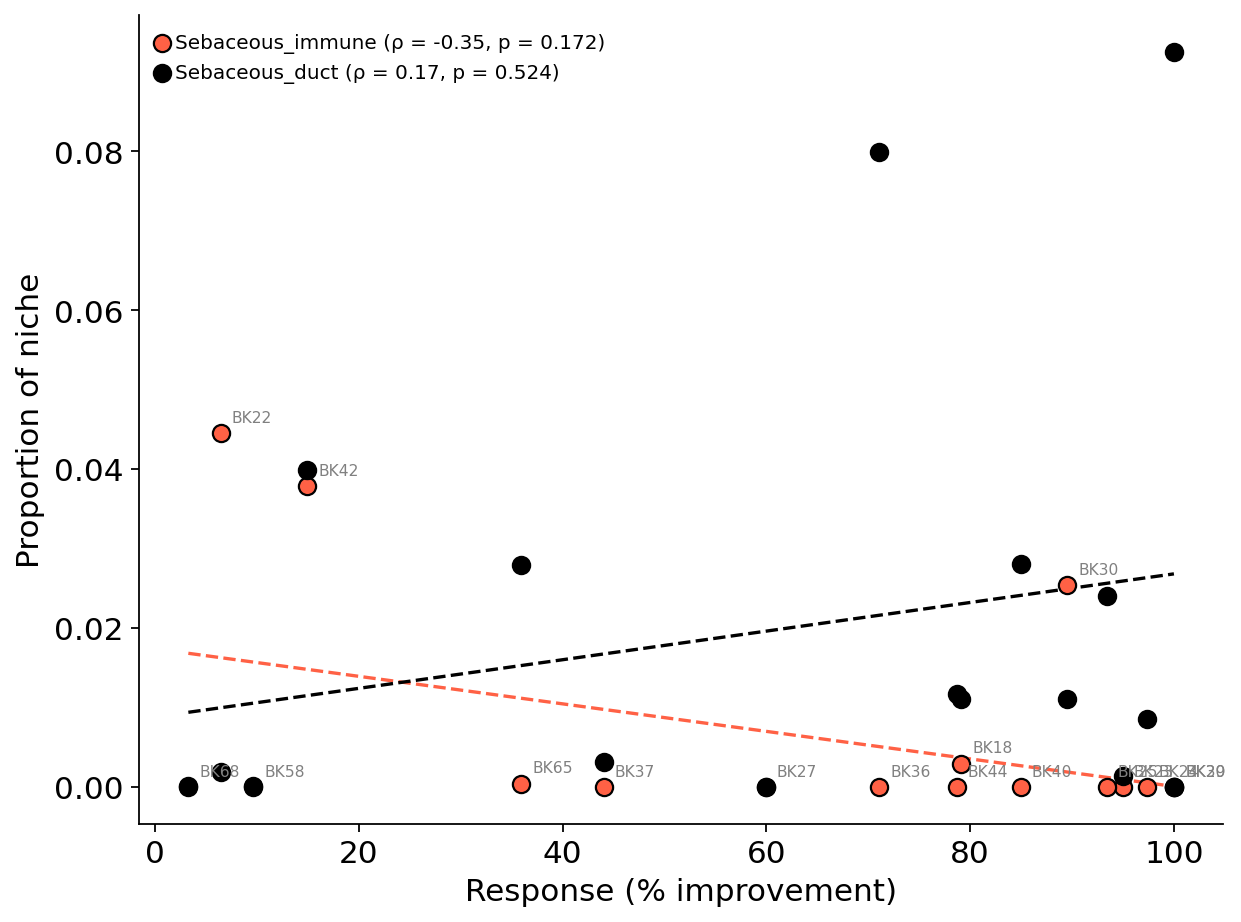

In [86]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

niche_colors = {niche: colors_new2[niche] for niche in TARGET_NICHES}
niche_colors["Sebaceous_duct"] = "black"

def build_plot_df(adata_obj):
    counts = (
        adata_obj.obs
        .groupby([SAMPLE_KEY, NICHE_KEY])
        .size()
        .unstack(fill_value=0)
    )
    props = counts.div(counts.sum(axis=1), axis=0)
    plot_df = props[[n for n in TARGET_NICHES if n in props.columns]].reset_index()

    resp = adata_obj.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
    plot_df = plot_df.merge(resp, on=SAMPLE_KEY)
    plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
    plot_df = plot_df.dropna(subset=[RESPONSE_KEY])
    return plot_df

# Combine both datasets — one row per patient-dataset, all as circles
combined = pd.concat(
    [build_plot_df(adata_time), build_plot_df(adata_i)],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8, 6))

for niche in TARGET_NICHES:
    if niche not in combined.columns:
        continue
    sub = combined.dropna(subset=[niche])
    x = sub[RESPONSE_KEY].values
    y = sub[niche].values

    r, p = spearmanr(x, y)
    label = f"{niche} (ρ = {r:.2f}, p = {p:.3f})"

    ax.scatter(
        x, y,
        color=niche_colors[niche],
        marker="o",
        s=60, edgecolor="black", zorder=3,
        label=label,
    )

    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        xs, np.polyval(z, xs),
        linestyle="--",
        color=niche_colors[niche],
        linewidth=1.5, zorder=2,
    )

    print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

# Label each point with patient ID (using the primary niche for y-position)
primary_niche = TARGET_NICHES[0]
if primary_niche in combined.columns:
    for _, row in combined.dropna(subset=[primary_niche]).iterrows():
        ax.annotate(
            row[SAMPLE_KEY],
            (row[RESPONSE_KEY], row[primary_niche]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7, color="gray",
        )

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.legend(frameon=False, loc="best", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("outcome_by_sebaceous_niche_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

Sebaceous_immune: ρ = -0.60, p = 0.285, n = 5
Sebaceous_duct: ρ = 0.35, p = 0.196, n = 15


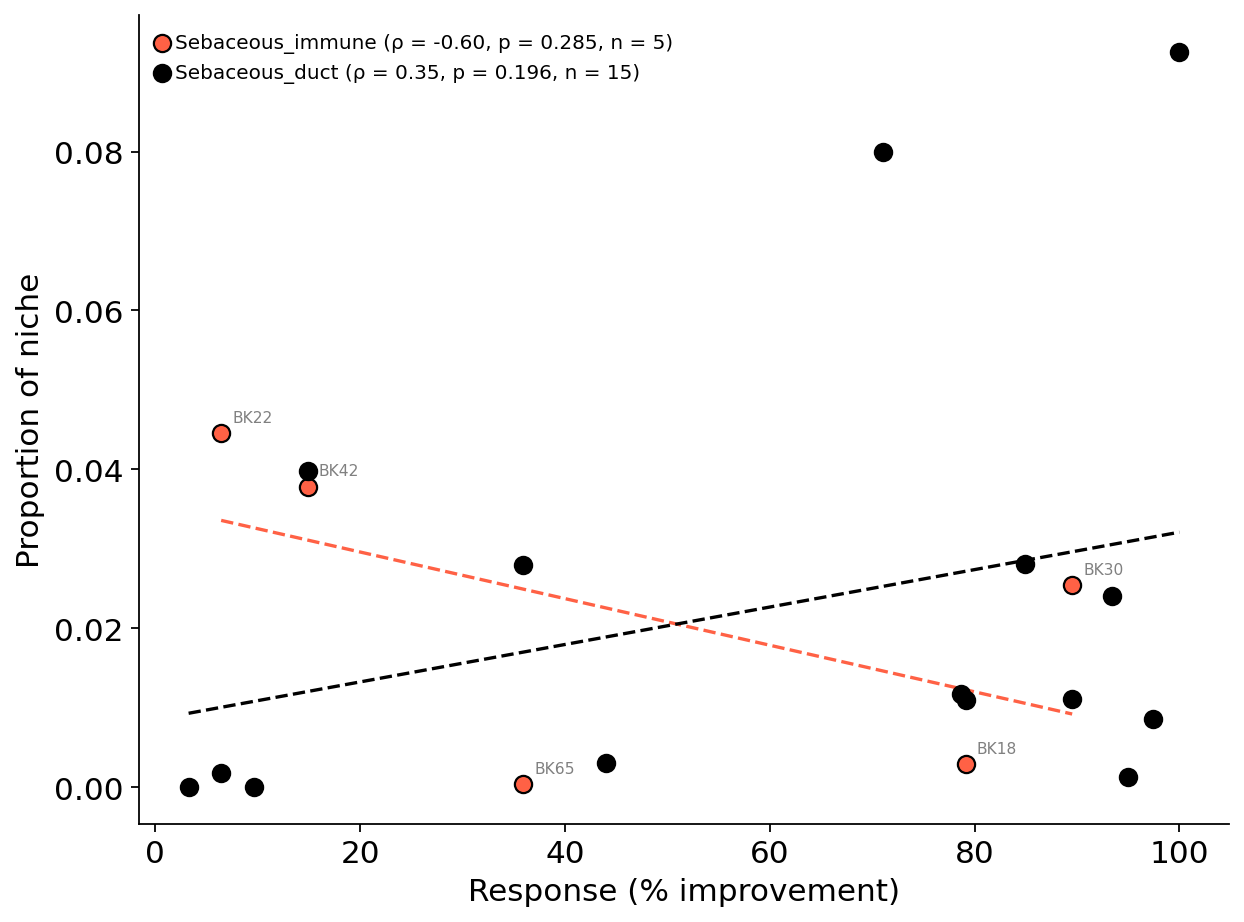

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

niche_colors = {niche: colors_new2[niche] for niche in TARGET_NICHES}
niche_colors["Sebaceous_duct"] = "black"

def build_plot_df(adata_obj):
    counts = (
        adata_obj.obs
        .groupby([SAMPLE_KEY, NICHE_KEY])
        .size()
        .unstack(fill_value=0)
    )
    props = counts.div(counts.sum(axis=1), axis=0)
    plot_df = props[[n for n in TARGET_NICHES if n in props.columns]].reset_index()

    resp = adata_obj.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
    plot_df = plot_df.merge(resp, on=SAMPLE_KEY)
    plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
    plot_df = plot_df.dropna(subset=[RESPONSE_KEY])
    return plot_df

combined = pd.concat(
    [build_plot_df(adata_time), build_plot_df(adata_i)],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(8, 6))

for niche in TARGET_NICHES:
    if niche not in combined.columns:
        continue
    sub = combined.dropna(subset=[niche])
    sub = sub[sub[niche] > 0]                    # ← exclude samples where niche is absent
    if len(sub) < 3:
        print(f"{niche}: too few samples with the niche present (n={len(sub)}), skipping")
        continue

    x = sub[RESPONSE_KEY].values
    y = sub[niche].values

    r, p = spearmanr(x, y)
    label = f"{niche} (ρ = {r:.2f}, p = {p:.3f}, n = {len(sub)})"

    ax.scatter(
        x, y,
        color=niche_colors[niche],
        marker="o",
        s=60, edgecolor="black", zorder=3,
        label=label,
    )

    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(
        xs, np.polyval(z, xs),
        linestyle="--",
        color=niche_colors[niche],
        linewidth=1.5, zorder=2,
    )

    print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}, n = {len(sub)}")

# Patient ID labels — same filter as the scatter so labels don't appear at y=0
primary_niche = TARGET_NICHES[0]
if primary_niche in combined.columns:
    annot_df = combined.dropna(subset=[primary_niche])
    annot_df = annot_df[annot_df[primary_niche] > 0]
    for _, row in annot_df.iterrows():
        ax.annotate(
            row[SAMPLE_KEY],
            (row[RESPONSE_KEY], row[primary_niche]),
            xytext=(5, 5), textcoords="offset points",
            fontsize=7, color="gray",
        )

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.legend(frameon=False, loc="best", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("outcome_by_sebaceous_niche_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

adata_i patients:    9
adata_time patients: 7
combined patients:   16

                          niche19  spearman_r p_value  n_patients p_adj
               Small_BV_TRM_IL13+       0.359   0.172          16 0.861
             Tzone-like_TRM_IL13+       0.252   0.346          16 0.861
         Sebaceous_duct_TRM_IL13+       0.185   0.492          16 0.879
          Epidermis_mid_TRM_IL13+       0.149   0.582          16 0.879
    Sweat_gland_channel_TRM_IL13+       0.060   0.879           9 0.879
       Papillary_dermis_TRM_IL13+       0.054   0.843          16 0.879
        Epidermis_basal_TRM_IL13+      -0.085   0.753          16 0.879
         Epidermis_late_TRM_IL13+      -0.090   0.848           7 0.879
   EpidermisInflamm_mid_TRM_IL13+      -0.179   0.645           9 0.879
       Sebaceous_immune_TRM_IL13+      -0.340   0.197          16 0.861
        Epidermis_APChi_TRM_IL13+      -0.348   0.359           9 0.861
Epidermis_basal_cycling_TRM_IL13+      -0.387   0.304           9

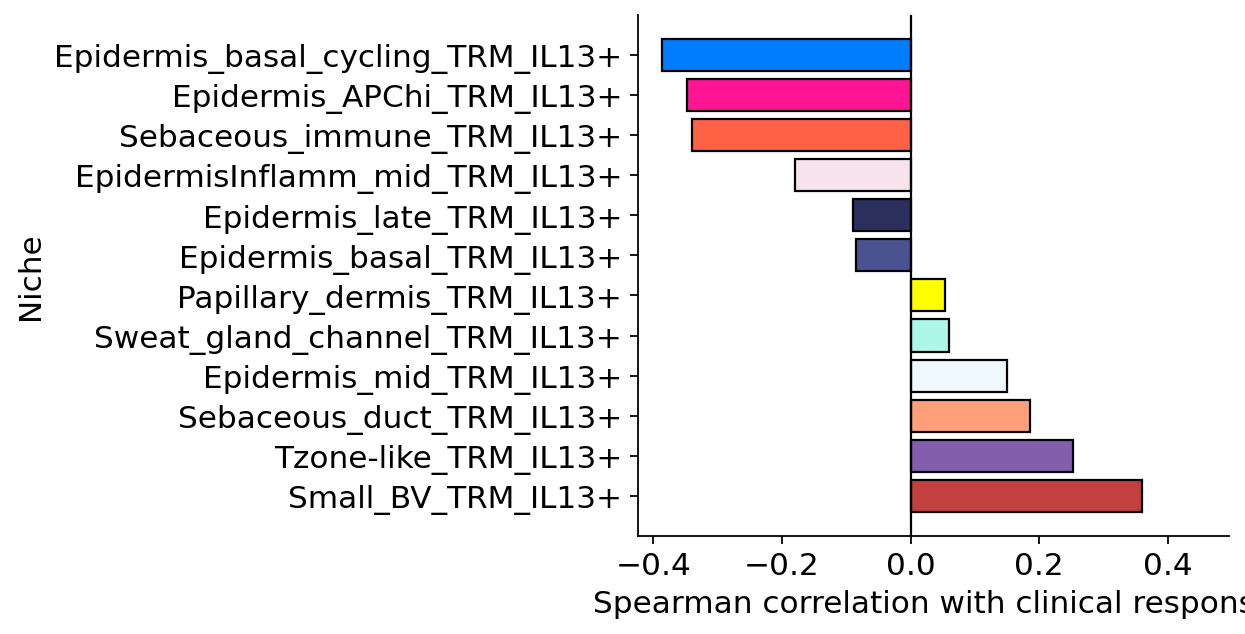

In [88]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import pandas as pd
import matplotlib.pyplot as plt

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19_celltype"
RESPONSE_KEY = "response"

def build_per_patient_props(adata_obj, min_cells_per_combo=10):
    """Compute per-patient niche19_celltype proportions for TRM_IL13+ cells."""
    obs = adata_obj.obs.copy()
    obs["niche19_celltype"] = (
        obs["niche19"].astype(str) + "_" + obs["lvl5_annotation"].astype(str)
    )

    # TRM_IL13+ cells only
    obs = obs[obs["lvl5_annotation"].str.startswith("TRM_IL13")]

    # Drop niche × celltype combos with too few cells
    vc = obs["niche19_celltype"].value_counts()
    keep = vc[vc >= min_cells_per_combo].index
    obs = obs[obs["niche19_celltype"].isin(keep)]

    # Per-patient niche proportions
    counts = obs.groupby([SAMPLE_KEY, NICHE_KEY]).size().unstack(fill_value=0)
    props = counts.div(counts.sum(axis=1), axis=0)

    long = props.stack().rename("prop").reset_index()

    # Attach response
    resp = obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
    long = long.merge(resp, on=SAMPLE_KEY)
    long[RESPONSE_KEY] = pd.to_numeric(long[RESPONSE_KEY], errors="coerce")
    long = long.dropna(subset=[RESPONSE_KEY])
    return long

# --- 1. Combine the two datasets ---
long_i    = build_per_patient_props(adata_i)
long_time = build_per_patient_props(adata_time)
combined  = pd.concat([long_i, long_time], ignore_index=True)

print(f"adata_i patients:    {long_i[SAMPLE_KEY].nunique()}")
print(f"adata_time patients: {long_time[SAMPLE_KEY].nunique()}")
print(f"combined patients:   {combined[SAMPLE_KEY].nunique()}")

# --- 2. Spearman per niche on the combined data ---
results = []
for niche, df_n in combined.groupby(NICHE_KEY):
    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue
    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = pd.DataFrame(results, columns=["niche19", "spearman_r", "p_value", "n_patients"])
if len(corr_df) == 0:
    raise RuntimeError("No niches passed the 5-patient threshold — nothing to plot.")

corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)

# Print summary table
print()
print(
    corr_df.assign(
        spearman_r=lambda d: d["spearman_r"].round(3),
        p_value=lambda d: d["p_value"].map(lambda x: f"{x:.3g}"),
        p_adj=lambda d: d["p_adj"].map(lambda x: f"{x:.3g}"),
    ).to_string(index=False)
)

# --- 3. Map composite name → base niche for colouring ---
def get_niche(name):
    return name.rsplit("_TRM_", 1)[0]

bar_colors = [colors_new2.get(get_niche(n), "#cccccc") for n in corr_df["niche19"]]

unmapped = [get_niche(n) for n in corr_df["niche19"] if get_niche(n) not in colors_new2]
if unmapped:
    print(f"\nunmapped niches (grey fallback): {unmapped}")

# --- 4. Bar plot ---
fig, ax = plt.subplots(figsize=(8, max(2, 0.35 * len(corr_df))))

ax.barh(
    corr_df["niche19"], corr_df["spearman_r"],
    color=bar_colors, edgecolor="black",
)

# Significance stars (FDR-adjusted)
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.001:
        stars = "***"
    elif row["p_adj"] < 0.01:
        stars = "**"
    elif row["p_adj"] < 0.05:
        stars = "*"
    else:
        continue
    offset = 0.02 if row["spearman_r"] >= 0 else -0.02
    ha = "left" if row["spearman_r"] >= 0 else "right"
    ax.text(
        row["spearman_r"] + offset, i, stars,
        va="center", ha=ha, fontsize=11, fontweight="bold",
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response")
ax.set_ylabel("Niche")
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(ax.get_xlim()[0], ax.get_xlim()[1] * 1.25)

plt.tight_layout()
plt.savefig("outcome_by_niche_celltype_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [89]:
a

NameError: name 'a' is not defined

In [ ]:
# sc.pl.dotplot(
#     adata_time[adata_time.obs["lvl5_annotation"].str.startswith("T")],
#     ["POSTN", "MMP12"],
#     groupby="lvl5_annotation",
#     standard_scale="var",
#     dendrogram=False,
#     vmax=1,
#    # save="relapse_trm_phenotyping_onlybarplotvalues.pdf",
#     colorbar_title="Mean expression\n(log1p norm.)",
#     dot_max=0.3,
# )

In [ ]:
8

In [ ]:
# 10 patientAAAAs

In [ ]:
# response_dict = adata_i.obs.drop_duplicates("Sanger patient ID").set_index("response")["Sanger patient ID"].to_dict()
# response_dict

In [ ]:

# #adata_i=adata[adata.obs["tech"]=="xenium"].copy()
# #adata_i=adata_i[~adata_i.obs["baseline_severity"].isna()]
# #adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]
# # --------------------------------------------------
# # Keys (explicit, so nothing "mysteriously" breaks)
# # --------------------------------------------------
# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "response"

# # --------------------------------------------------
# # 1. Compute niche proportions per patient
# # --------------------------------------------------
# counts = (
#     adata_i.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .rename("count")
#     .reset_index()
# )

# # Total cells per patient
# totals = (
#     counts
#     .groupby(SAMPLE_KEY)["count"]
#     .sum()
#     .rename("total_cells")
#     .reset_index()
# )

# counts = counts.merge(totals, on=SAMPLE_KEY)

# # Proportion of each niche per patient
# counts["prop"] = counts["count"] / counts["total_cells"]

# # --------------------------------------------------
# # 2. Attach patient-level response
# # --------------------------------------------------
# response_df = (
#     adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
#     .drop_duplicates(subset=SAMPLE_KEY)
# )

# counts = counts.merge(response_df, on=SAMPLE_KEY)

# # --------------------------------------------------
# # 3. Correlation per niche (Spearman)
# # --------------------------------------------------
# results = []

# for niche, df_n in counts.groupby(NICHE_KEY):

#     n_patients = df_n[SAMPLE_KEY].nunique()
#     if n_patients < 5:
#         continue

#     r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
#     results.append((niche, r, p, n_patients))

# corr_df = (
#     pd.DataFrame(
#         results,
#         columns=["niche19", "spearman_r", "p_value", "n_patients"]
#     )
#     .sort_values("spearman_r", ascending=False)
# )

# print(corr_df)

# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------

# fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# # Build color list in the same order as corr_df
# bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

# ax.barh(
#     corr_df["niche19"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black"
# )

# ax.axvline(0, color="black", linewidth=1)
# ax.set_xlabel("Spearman correlation with disease duration")
# ax.set_ylabel("Niche")

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()


In [ ]:
# # --------------------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------

# fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

# # Explicit colors in correct order
# bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

# ax.barh(
#     corr_df["niche19"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black"
# )

# # Reference line
# ax.axvline(0, color="black", linewidth=1)

# # Labels
# ax.set_xlabel("Spearman correlation\nwith response")
# ax.set_ylabel("")          # remove ylabel

# # Remove grid explicitly
# ax.grid(False)

# # Clean spines
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# # Prevent xlabel cutoff
# plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)

# plt.show()




# week 12 reponse

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr



#adata_i=adata[adata.obs["tech"]=="xenium"].copy()
adata_i=adata[~adata.obs["response"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Week 12"]
adata_i.obs["Timepoint2"].value_counts()

In [ ]:
# adata_i.obs.niche19.value_counts()

In [ ]:
# corr_df

In [ ]:
adata_i.obs["response"]=adata_i.obs["response"].astype(float)

In [ ]:
# --------------------------------------------------
# Keys (explicit, so nothing "mysteriously" breaks)
# --------------------------------------------------
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"

# --------------------------------------------------
# 1. Compute niche proportions per patient
# --------------------------------------------------
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .rename("count")
    .reset_index()
)

# Total cells per patient
totals = (
    counts
    .groupby(SAMPLE_KEY)["count"]
    .sum()
    .rename("total_cells")
    .reset_index()
)

counts = counts.merge(totals, on=SAMPLE_KEY)

# Proportion of each niche per patient
counts["prop"] = counts["count"] / counts["total_cells"]

# --------------------------------------------------
# 2. Attach patient-level response
# --------------------------------------------------
response_df = (
    adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
    .drop_duplicates(subset=SAMPLE_KEY)
)

counts = counts.merge(response_df, on=SAMPLE_KEY)

# --------------------------------------------------
# 3. Correlation per niche (Spearman)
# --------------------------------------------------
results = []

for niche, df_n in counts.groupby(NICHE_KEY):

    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue

    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = (
    pd.DataFrame(
        results,
        columns=["niche19", "spearman_r", "p_value", "n_patients"]
    )
    .sort_values("spearman_r", ascending=False)
)

print(corr_df)

# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# Explicit colors in correct order
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    edgecolor="black",
        color=bar_colors,

)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with response")
ax.set_ylabel("Niche")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)


plt.tight_layout()

plt.show()




In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHE = "Hypodermis"

# 1. Compute proportion of target niche per patient
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

plot_df = props[[TARGET_NICHE]].reset_index()
plot_df.columns = [SAMPLE_KEY, "prop"]

# 2. Attach response
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)

# 👇 FIX: convert response to numeric
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Scatter plot
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(plot_df[RESPONSE_KEY], plot_df["prop"],
           color=colors_new2[TARGET_NICHE], s=60, edgecolor="black", zorder=3)

for _, row in plot_df.iterrows():
    ax.annotate(row[SAMPLE_KEY],
                (row[RESPONSE_KEY], row["prop"]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7)

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel(f"Proportion of {TARGET_NICHE}")
ax.set_title(f"{TARGET_NICHE} abundance vs. clinical response")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_NICHES = ["Sebaceous_immune", "Sebaceous_duct"]

# 1. Compute proportions per patient
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

plot_df = props[TARGET_NICHES].reset_index()

# 2. Attach response
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Scatter plot with both niches
fig, ax = plt.subplots(figsize=(7, 5))

# Store stats for legend labels
legend_labels = []

for niche in TARGET_NICHES:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[niche].values

    r, p = spearmanr(x, y)
    label = f"{niche}  (ρ = {r:.2f}, p = {p:.3f})"
    legend_labels.append(label)

    # Scatter
    ax.scatter(x, y,
               color=colors_new2[niche],
               s=60, edgecolor="black", zorder=3,
               label=label)

    # Regression line
    z = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, np.polyval(z, xs), "--",
            color=colors_new2[niche], linewidth=1.5, zorder=2)

    print(f"{niche}: ρ = {r:.2f}, p = {p:.3f}")

# Label each point with patient ID
for _, row in plot_df.iterrows():
    ax.annotate(row[SAMPLE_KEY],
                (row[RESPONSE_KEY], row[TARGET_NICHES[0]]),
                xytext=(5, 5), textcoords="offset points",
                fontsize=7, color="gray")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of niche")
ax.set_title("")
ax.legend(frameon=False, loc="best", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.savefig("outcome_by_sebaceous_niche.pdf", dpi=300, bbox_inches="tight")  # 👈 add here

plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import pandas as pd

# SAMPLE_KEY = "Sanger patient ID"
# NICHE_KEY = "niche19"
# RESPONSE_KEY = "response"
# TARGET_NICHE = "Sebaceous_immune"

# # 1. Compute proportion of target niche per patient
# counts = (
#     adata_i.obs
#     .groupby([SAMPLE_KEY, NICHE_KEY])
#     .size()
#     .unstack(fill_value=0)
# )
# props = counts.div(counts.sum(axis=1), axis=0)

# plot_df = props[[TARGET_NICHE]].reset_index()
# plot_df.columns = [SAMPLE_KEY, "prop"]

# # 2. Attach response
# response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
# plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)

# # 👇 FIX: convert response to numeric
# plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
# plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# # 3. Scatter plot
# fig, ax = plt.subplots(figsize=(6, 5))
# ax.scatter(plot_df[RESPONSE_KEY], plot_df["prop"],
#            color=colors_new2[TARGET_NICHE], s=60, edgecolor="black", zorder=3)

# for _, row in plot_df.iterrows():
#     ax.annotate(row[SAMPLE_KEY],
#                 (row[RESPONSE_KEY], row["prop"]),
#                 xytext=(5, 5), textcoords="offset points",
#                 fontsize=7)

# ax.set_xlabel("Response (% improvement)")
# ax.set_ylabel(f"Proportion of {TARGET_NICHE}")
# ax.set_title(f"{TARGET_NICHE} abundance vs. clinical response")
# ax.spines[["top", "right"]].set_visible(False)
# ax.grid(False)
# plt.tight_layout()
# plt.show()

In [ ]:
# can i make a composite of adata.obs["lvl5_annotation"] + "_" + adata.obs["niche19"], 
# and then do the plot showing:
# "TRM_IL13+_Sebaceous_duct"
# "TRM_IL13+_Sebaceous_immune"
# "TRM_IL13+_Epidermis_mid"
# "TRM_IL13+_Epidermis_basal"

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Create composite annotation
adata_i.obs["celltype_niche"] = (
    adata_i.obs["lvl5_annotation"].astype(str)
    + "_"
    + adata_i.obs["niche19"].astype(str)
)

SAMPLE_KEY = "Sanger patient ID"
COMPOSITE_KEY = "celltype_niche"
RESPONSE_KEY = "response"
TARGETS = [
    "TRM_IL13+_Sebaceous_duct",
    "TRM_IL13+_Sebaceous_immune",
    #TRM_IL13+_Epidermis_mid",
    #"TRM_IL13+_Epidermis_basal",
]

# 1. Proportions per patient (denominator = all cells from that patient)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, COMPOSITE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# Check which targets actually exist
missing = [t for t in TARGETS if t not in props.columns]
if missing:
    print(f"⚠️ Not found in data: {missing}")
TARGETS = [t for t in TARGETS if t in props.columns]

plot_df = props[TARGETS].reset_index()

# 2. Attach response (numeric)
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Assign colors (pull from existing niche palette if possible)
palette = {}
for t in TARGETS:
    niche = t.replace("TRM_IL13+_", "")  # extract niche part
    palette[t] = colors_new2.get(niche, None)
# Fallback palette if any missing
fallback = plt.cm.tab10.colors
for i, t in enumerate(TARGETS):
    if palette[t] is None:
        palette[t] = fallback[i]

# 4. Plot
fig, ax = plt.subplots(figsize=(7, 5))

for target in TARGETS:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[target].values

    ax.scatter(x, y, color=palette[target], s=60,
               edgecolor="black", zorder=3, label=target)

    # Regression line
    if len(x) >= 2:
        z = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(z, xs), "--",
                color=palette[target], linewidth=1.5, zorder=2)

    r, p = spearmanr(x, y)
    print(f"{target}: ρ = {r:.2f}, p = {p:.3f}")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of cells (out of all cells per patient)")
ax.set_title("TRM_IL13+ cells across niches vs. clinical response")
ax.legend(frameon=False, fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

# Create composite annotation
adata_i.obs["celltype_niche"] = (
    adata_i.obs["lvl5_annotation"].astype(str)
    + "_"
    + adata_i.obs["niche19"].astype(str)
)

SAMPLE_KEY = "Sanger patient ID"
COMPOSITE_KEY = "celltype_niche"
RESPONSE_KEY = "response"
TARGETS = [
    "TRM_IL13+_Sebaceous_duct",
    "TRM_IL13+_Sebaceous_immune",
    "TRM_IL13+_Epidermis_mid",
    "TRM_IL13+_Epidermis_basal",
]

# 1. Proportions per patient (denominator = all cells from that patient)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, COMPOSITE_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# Check which targets actually exist
missing = [t for t in TARGETS if t not in props.columns]
if missing:
    print(f"⚠️ Not found in data: {missing}")
TARGETS = [t for t in TARGETS if t in props.columns]

plot_df = props[TARGETS].reset_index()

# 2. Attach response (numeric)
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Assign colors (pull from existing niche palette if possible)
palette = {}
for t in TARGETS:
    niche = t.replace("TRM_IL13+_", "")  # extract niche part
    palette[t] = colors_new2.get(niche, None)
# Fallback palette if any missing
fallback = plt.cm.tab10.colors
for i, t in enumerate(TARGETS):
    if palette[t] is None:
        palette[t] = fallback[i]

# 4. Plot
fig, ax = plt.subplots(figsize=(7, 5))

for target in TARGETS:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[target].values

    ax.scatter(x, y, color=palette[target], s=60,
               edgecolor="black", zorder=3, label=target)

    # Regression line
    if len(x) >= 2:
        z = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(z, xs), "--",
                color=palette[target], linewidth=1.5, zorder=2)

    r, p = spearmanr(x, y)
    print(f"{target}: ρ = {r:.2f}, p = {p:.3f}")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of cells (out of all cells per patient)")
ax.set_title("TRM_IL13+ cells across niches vs. clinical response")
ax.legend(frameon=False, fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
adata[adata.obs["lvl5_annotation"]=="TRM_IL13+"].obs.niche19.value_counts()

# baseline severity

In [ ]:
adata_i=adata[~adata.obs["baseline_severity"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Week 12"]

# --------------------------------------------------
# Keys (explicit, so nothing "mysteriously" breaks)
# --------------------------------------------------
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "baseline_severity"

# --------------------------------------------------
# 1. Compute niche proportions per patient
# --------------------------------------------------
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .rename("count")
    .reset_index()
)

# Total cells per patient
totals = (
    counts
    .groupby(SAMPLE_KEY)["count"]
    .sum()
    .rename("total_cells")
    .reset_index()
)

counts = counts.merge(totals, on=SAMPLE_KEY)

# Proportion of each niche per patient
counts["prop"] = counts["count"] / counts["total_cells"]

# --------------------------------------------------
# 2. Attach patient-level response
# --------------------------------------------------
response_df = (
    adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
    .drop_duplicates(subset=SAMPLE_KEY)
)

counts = counts.merge(response_df, on=SAMPLE_KEY)

# --------------------------------------------------
# 3. Correlation per niche (Spearman)
# --------------------------------------------------
results = []

for niche, df_n in counts.groupby(NICHE_KEY):

    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue

    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = (
    pd.DataFrame(
        results,
        columns=["niche19", "spearman_r", "p_value", "n_patients"]
    )
    .sort_values("spearman_r", ascending=False)
)

print(corr_df)

# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# Explicit colors in correct order
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

 
ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    edgecolor="black",
        color=bar_colors,
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with response")
ax.set_ylabel("Niche")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()




# baseline lesiona by cell type

In [ ]:
adata.obs["Timepoint2"].value_counts()

In [ ]:

adata_i=adata[~adata.obs["response"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

# --------------------------------------------------
# Keys (explicit, so nothing "mysteriously" breaks)
# --------------------------------------------------
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"

# --------------------------------------------------
# 1. Compute niche proportions per patient
# --------------------------------------------------
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .rename("count")
    .reset_index()
)

# Total cells per patient
totals = (
    counts
    .groupby(SAMPLE_KEY)["count"]
    .sum()
    .rename("total_cells")
    .reset_index()
)

counts = counts.merge(totals, on=SAMPLE_KEY)

# Proportion of each niche per patient
counts["prop"] = counts["count"] / counts["total_cells"]

# --------------------------------------------------
# 2. Attach patient-level response
# --------------------------------------------------
response_df = (
    adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
    .drop_duplicates(subset=SAMPLE_KEY)
)

counts = counts.merge(response_df, on=SAMPLE_KEY)

# --------------------------------------------------
# 3. Correlation per niche (Spearman)
# --------------------------------------------------
results = []

for niche, df_n in counts.groupby(NICHE_KEY):

    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue

    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = (
    pd.DataFrame(
        results,
        columns=["lvl5_annotation", "spearman_r", "p_value", "n_patients"]
    )
    .sort_values("spearman_r", ascending=False)
)

print(corr_df)

# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# Build color list in the same order as corr_df
bar_colors = [colors_cells[n] for n in corr_df["lvl5_annotation"]]

ax.barh(
    corr_df["lvl5_annotation"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black"
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with disease duration")
ax.set_ylabel("Niche")

ax.grid(False)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()






In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

adata_i = adata[~adata.obs["response"].isna()]
adata_i = adata_i[adata_i.obs["Timepoint2"] == "Lesional Baseline"]
# adata_i = adata_i[adata_i.obs["tech"] == "xenium"]  # <-- add if needed

SAMPLE_KEY = "Sanger patient ID"
CELL_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"

# 1. Counts per patient × cell type (fill missing with 0)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, CELL_KEY])
    .size()
    .unstack(fill_value=0)
)

# --- NEW: Filter out cell types with <50 total cells across all patients ---
MIN_TOTAL_CELLS = 50
total_per_celltype = counts.sum(axis=0)
abundant_mask = total_per_celltype >= MIN_TOTAL_CELLS
counts = counts.loc[:, abundant_mask]
print(f"Kept {abundant_mask.sum()}/{len(abundant_mask)} cell types "
      f"(≥{MIN_TOTAL_CELLS} total cells across all patients)")
# ---------------------------------------------------------------------------

# Compute proportions AFTER filtering
props = counts.div(counts.sum(axis=1), axis=0)

# Filter: keep cell types present in at least 50% of patients
MIN_PATIENT_FRAC = 0.5
present_mask = (props > 0).mean(axis=0) >= MIN_PATIENT_FRAC
props = props.loc[:, present_mask]
print(f"Kept {present_mask.sum()}/{len(present_mask)} cell types "
      f"(present in ≥{MIN_PATIENT_FRAC:.0%} of patients)")

# Long format + merge response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
props_long = props_long.dropna(subset=[RESPONSE_KEY])

# 2. Spearman per cell type
results = []
for cell, df_c in props_long.groupby(CELL_KEY):
    n_patients = df_c[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue
    r, p = spearmanr(df_c["prop"], df_c[RESPONSE_KEY])
    results.append((cell, r, p, n_patients))

corr_df = pd.DataFrame(results, columns=[CELL_KEY, "spearman_r", "p_value", "n_patients"])
corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 3. Bar plot
fig, ax = plt.subplots(figsize=(6, 0.25 * len(corr_df)))
bar_colors = [colors_cells.get(c, "#999999") for c in corr_df[CELL_KEY]]
ax.barh(corr_df[CELL_KEY], corr_df["spearman_r"], color=bar_colors, edgecolor="black")

# Mark significant cell types (FDR < 0.05)
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.05:
        ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with clinical response (% improvement)")
ax.set_ylabel("Cell type")
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

adata_i = adata[~adata.obs["response"].isna()]
adata_i = adata_i[adata_i.obs["Timepoint2"] == "Lesional Baseline"]
# adata_i = adata_i[adata_i.obs["tech"] == "xenium"]  # <-- add if needed

SAMPLE_KEY = "Sanger patient ID"
CELL_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"

# 1. Proportions per patient (fill missing cell types with 0)
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, CELL_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# --- Optional filter for rare cell types ---
# Keep cell types present in at least 50% of patients
MIN_PATIENT_FRAC = 0.5
present_mask = (props > 0).mean(axis=0) >= MIN_PATIENT_FRAC
props = props.loc[:, present_mask]
print(f"Kept {present_mask.sum()}/{len(present_mask)} cell types "
      f"(present in ≥{MIN_PATIENT_FRAC:.0%} of patients)")
# -------------------------------------------

# Long format + merge response
props_long = props.stack().rename("prop").reset_index()
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
props_long = props_long.merge(response_df, on=SAMPLE_KEY)
props_long[RESPONSE_KEY] = pd.to_numeric(props_long[RESPONSE_KEY], errors="coerce")
props_long = props_long.dropna(subset=[RESPONSE_KEY])

# 2. Spearman per cell type
results = []
for cell, df_c in props_long.groupby(CELL_KEY):
    n_patients = df_c[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue
    r, p = spearmanr(df_c["prop"], df_c[RESPONSE_KEY])
    results.append((cell, r, p, n_patients))

corr_df = pd.DataFrame(results, columns=[CELL_KEY, "spearman_r", "p_value", "n_patients"])
corr_df["p_adj"] = multipletests(corr_df["p_value"], method="fdr_bh")[1]
corr_df = corr_df.sort_values("spearman_r", ascending=False)
print(corr_df)

# 3. Bar plot
fig, ax = plt.subplots(figsize=(6, 0.25 * len(corr_df)))
bar_colors = [colors_cells.get(c, "#999999") for c in corr_df[CELL_KEY]]
ax.barh(corr_df[CELL_KEY], corr_df["spearman_r"], color=bar_colors, edgecolor="black")

# Mark significant cell types (FDR < 0.05)
for i, (_, row) in enumerate(corr_df.iterrows()):
    if row["p_adj"] < 0.05:
        ax.text(row["spearman_r"], i, " *", va="center", fontsize=12)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation")
ax.set_ylabel("Cell type")
ax.grid(False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("outcome_by_celltype.pdf", dpi=300, bbox_inches="tight")  # 👈 add here

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

SAMPLE_KEY = "Sanger patient ID"
CELL_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"
TARGETS = ["ILC_Prolif", "Mac2_CCL14hi", "TRM_IL13+", "F3: FRC-like"]

# 1. Proportions per patient
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, CELL_KEY])
    .size()
    .unstack(fill_value=0)
)
props = counts.div(counts.sum(axis=1), axis=0)

# Check which targets exist
missing = [t for t in TARGETS if t not in props.columns]
if missing:
    print(f"⚠️ Not found in data: {missing}")
TARGETS = [t for t in TARGETS if t in props.columns]

plot_df = props[TARGETS].reset_index()

# 2. Attach response (numeric)
response_df = adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]].drop_duplicates(SAMPLE_KEY)
plot_df = plot_df.merge(response_df, on=SAMPLE_KEY)
plot_df[RESPONSE_KEY] = pd.to_numeric(plot_df[RESPONSE_KEY], errors="coerce")
plot_df = plot_df.dropna(subset=[RESPONSE_KEY])

# 3. Colors — use colors_cells if available, otherwise tab10
palette = {}
fallback = plt.cm.tab10.colors
for i, t in enumerate(TARGETS):
    try:
        palette[t] = colors_cells[t]
    except (NameError, KeyError):
        palette[t] = fallback[i]

# 4. Plot
fig, ax = plt.subplots(figsize=(7, 5))

for target in TARGETS:
    x = plot_df[RESPONSE_KEY].values
    y = plot_df[target].values

    ax.scatter(x, y, color=palette[target], s=60,
               edgecolor="black", zorder=3, label=target)

    # Regression line
    if len(x) >= 2:
        z = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(z, xs), "--",
                color=palette[target], linewidth=1.5, zorder=2)

    r, p = spearmanr(x, y)
    print(f"{target}: ρ = {r:.2f}, p = {p:.3f}")

ax.set_xlabel("Response (% improvement)")
ax.set_ylabel("Proportion of cells per patient")
ax.set_title("Cell type abundance vs. clinical response")
ax.legend(frameon=False, fontsize=8, loc="best")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

SAMPLE_KEY = "Sanger patient ID"
CELL_KEY = "lvl5_annotation"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"
TARGET_CELL = "TRM_IL13+"

# 1. Subset to TRM_IL13+ cells
trm = adata_i.obs[adata_i.obs[CELL_KEY] == TARGET_CELL].copy()
trm[RESPONSE_KEY] = pd.to_numeric(trm[RESPONSE_KEY], errors="coerce")
trm = trm.dropna(subset=[RESPONSE_KEY])

# 2. Count TRM_IL13+ cells per patient × niche
counts = (
    trm.groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .unstack(fill_value=0)
)

# 3. Get response per patient and sort by it
response_per_patient = (
    trm.groupby(SAMPLE_KEY)[RESPONSE_KEY].first()
)
counts = counts.loc[response_per_patient.sort_values().index]
response_sorted = response_per_patient.loc[counts.index]

# 4. Build x-axis labels: "PatientID (response%)"
x_labels = [f"{pid} ({r:.0f}%)" for pid, r in zip(counts.index, response_sorted)]

# 5. Stacked bar plot
fig, ax = plt.subplots(figsize=(max(6, 0.35 * len(counts)), 5))

bottom = np.zeros(len(counts))
for niche in counts.columns:
    ax.bar(x_labels, counts[niche].values,
           bottom=bottom,
           color=colors_new2.get(niche, "#999999"),
           edgecolor="none",
           label=niche)
    bottom += counts[niche].values

ax.set_xlabel("Patient (sorted by response)")
ax.set_ylabel(f"Number of {TARGET_CELL} cells")
ax.set_title(f"{TARGET_CELL} cells per patient, colored by niche")
ax.legend(title="Niche", bbox_to_anchor=(1.02, 1), loc="upper left",
          fontsize=7, frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(False)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

In [ ]:
onlt show 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------------
# 1. Build per-info_id6 table
# ----------------------------
df = adata_i.obs.copy()

prop_df = (
    df.assign(is_seb=df["niche19"] == "Sebaceous_immune")
      .groupby("info_id6")
      .agg(
          prop_seb=("is_seb", "mean"),
          response=("response", "first"),
          baseline_severity=("baseline_severity", "first"),
      )
      .reset_index()
)

# Convert baseline_severity to float
prop_df["baseline_severity"] = pd.to_numeric(
    prop_df["baseline_severity"], errors="coerce"
)

# Drop missing values
prop_df = prop_df.dropna(subset=["prop_seb", "response", "baseline_severity"])

# ----------------------------
# 2. Correlation statistics
# ----------------------------
r, p = pearsonr(prop_df["prop_seb"], prop_df["response"])

# ----------------------------
# 3. Plot
# ----------------------------
plt.figure(figsize=(5, 4))

# Scatter (colored by baseline_severity — now continuous)
ax = sns.scatterplot(
    data=prop_df,
    x="prop_seb",
    y="response",
    hue="baseline_severity",
    palette="viridis",
    s=70,
    alpha=0.9,
    edgecolor="black",
)

# Regression line (no CI)
sns.regplot(
    data=prop_df,
    x="prop_seb",
    y="response",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2, "color": "black"},
)

plt.xlabel("Proportion Sebaceous_immune cells")
plt.ylabel("Response")
plt.title(f"Pearson r = {r:.2f}, p = {p:.2e}")

# Move legend to the right
plt.legend(
    title="Baseline severity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------------
# 1. Build per-info_id6 table
# ----------------------------
df = adata_i.obs.copy()

prop_df = (
    df.assign(is_seb=df["niche19"] == "Plasma_cell_rich")
      .groupby("info_id6")
      .agg(
          prop_seb=("is_seb", "mean"),
          response=("response", "first"),
          baseline_severity=("baseline_severity", "first"),
      )
      .reset_index()
)

# Convert baseline_severity to float
prop_df["baseline_severity"] = pd.to_numeric(
    prop_df["baseline_severity"], errors="coerce"
)

# Drop missing values
prop_df = prop_df.dropna(subset=["prop_seb", "response", "baseline_severity"])

# ----------------------------
# 2. Correlation statistics
# ----------------------------
r, p = pearsonr(prop_df["prop_seb"], prop_df["response"])

# ----------------------------
# 3. Plot
# ----------------------------
plt.figure(figsize=(5, 4))

# Scatter (colored by baseline_severity — now continuous)
ax = sns.scatterplot(
    data=prop_df,
    x="prop_seb",
    y="response",
    hue="baseline_severity",
    palette="viridis",
    s=70,
    alpha=0.9,
    edgecolor="black",
)

# Regression line (no CI)
sns.regplot(
    data=prop_df,
    x="prop_seb",
    y="response",
    scatter=False,
    ci=None,
    line_kws={"linewidth": 2, "color": "black"},
)

plt.xlabel("Proportion Plasma_cell_rich cells")
plt.ylabel("Response")
plt.title(f"Pearson r = {r:.2f}, p = {p:.2e}")

# Move legend to the right
plt.legend(
    title="Baseline severity",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0,
)

plt.tight_layout()
plt.show()

In [ ]:

adata_i=adata[adata.obs["tech"]=="xenium"].copy()
adata_i=adata_i[~adata_i.obs["baseline_severity"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# ----------------------------
# 1. Build per-info_id6 table
# ----------------------------
df = adata_i.obs.copy()

prop_df = (
    df.assign(is_seb=df["niche19"] == "Sebaceous_immune")
      .groupby("info_id6")
      .agg(
          prop_seb=("is_seb", "mean"),     # proportion of Sebaceous_immune
          response=("response", "first"), # assumes response constant per info_id6
      )
      .reset_index()
)

# Drop any rows with missing values (important for correlation)
prop_df = prop_df.dropna(subset=["prop_seb", "response"])

# ----------------------------
# 2. Correlation statistics
# ----------------------------
r, p = pearsonr(prop_df["prop_seb"], prop_df["response"])

# ----------------------------
# 3. Plot
# ----------------------------
plt.figure(figsize=(5, 4))

sns.regplot(
    data=prop_df,
    x="prop_seb",
    y="response",
    scatter_kws={"s": 60, "alpha": 0.8},
    line_kws={"linewidth": 2},
)

plt.xlabel("Proportion Sebaceous_immune cells")
plt.ylabel("Response")
plt.title(f"Pearson r = {r:.2f}, p = {p:.2e}")

plt.tight_layout()
plt.show()

In [ ]:
adata_i=adata[adata.obs["tech"]=="xenium"].copy()
adata_i=adata_i[~adata_i.obs["response"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Week 12"]

In [ ]:
NICHE_TO_PLOT = "Sebaceous_immune"  # change if needed

df_plot = counts[counts[NICHE_KEY] == NICHE_TO_PLOT]

plt.figure(figsize=(4, 4))
plt.scatter(df_plot["prop"], df_plot[RESPONSE_KEY])
plt.xlabel(f"Proportion of {NICHE_TO_PLOT}")
plt.ylabel("Response")
plt.title(
    f"{NICHE_TO_PLOT} "
    f"(n={df_plot[SAMPLE_KEY].nunique()} patients)"
)
plt.tight_layout()
plt.show()

In [ ]:
NICHE_TO_PLOT = "Plasma_cell_rich"  # change if needed

df_plot = counts[counts[NICHE_KEY] == NICHE_TO_PLOT]

plt.figure(figsize=(4, 4))
plt.scatter(df_plot["prop"], df_plot[RESPONSE_KEY])
plt.xlabel(f"Proportion of {NICHE_TO_PLOT}")
plt.ylabel("Response")
plt.title(
    f"{NICHE_TO_PLOT} "
    f"(n={df_plot[SAMPLE_KEY].nunique()} patients)"
)
plt.tight_layout()
plt.show()

In [ ]:
# [x for x in adata.obas.columns if "severity" in x.lower()]

In [ ]:
NICHE_TO_PLOT = "Plasma_cell_rich"  # change if needed

df_plot = counts[counts[NICHE_KEY] == NICHE_TO_PLOT]

plt.figure(figsize=(4, 4))
plt.scatter(df_plot["prop"], df_plot[RESPONSE_KEY])
plt.xlabel(f"Proportion of {NICHE_TO_PLOT}")
plt.ylabel("Response")
plt.title(
    f"{NICHE_TO_PLOT} "
    f"(n={df_plot[SAMPLE_KEY].nunique()} patients)"
)
plt.tight_layout()
plt.show()

In [ ]:
NICHE_TO_PLOT = "Sebaceous_immune"  # change if needed

df_plot = counts[counts[NICHE_KEY] == NICHE_TO_PLOT]

plt.figure(figsize=(4, 4))
plt.scatter(df_plot["prop"], df_plot[RESPONSE_KEY])
plt.xlabel(f"Proportion of {NICHE_TO_PLOT}")
plt.ylabel("Response")
plt.title(
    f"{NICHE_TO_PLOT} "
    f"(n={df_plot[SAMPLE_KEY].nunique()} patients)"
)
plt.tight_layout()
plt.show()

In [ ]:
# import pickle

# md = adata.obs["lvl5_annotation"].to_dict()

# outpath = "/nfs/team298/ls34/dicts/skinatlas_v1_labels.pkl"

# with open(outpath, "wb") as f:
#     pickle.dump(md, f, protocol=pickle.HIGHEST_PROTOCOL)

# print("Saved to:", outpath)

In [ ]:
# adata[adata.obs["lvl5_annotation"]=="Eosinophil"].shape

In [ ]:

# adata=adata[adata.obs["tech"]=="scrna"]

In [ ]:
# adata = adata[(adata.obs["lvl5_annotation"].str.startswith("Mac"))|
#       (adata.obs["lvl5_annotation"].str.startswith("Mono"))].copy()

In [ ]:
# PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new_maconly.h5ad'
# adata.write(PATH)

# /


 

In [ ]:
adata.obs["atlas_status_reynolds"].value_counts()

In [ ]:
adata.obs["Site_status"].value_counts()

In [ ]:
adata.obs["atlas_status_simple"].value_counts()

adata.obs["Site_status"]

In [ ]:
adata.obs["atlas_status_simple2"].value_counts()

In [ ]:
adata.obs["atlas_status_reynolds_simple"].value_counts()

In [ ]:
adata.obs["lvl5_annotation"].value_counts()

# set colors

In [ ]:
# colors ={"xenium": "#ebcf8d",
#          "scrna": "#a6c0d8",

# }

 
# adata.obs['tech'] =adata.obs['tech'] .astype('category')
# adata.uns['tech_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['tech'].cat.categories]

In [ ]:
# red white
colors2 = { "scrna": "#F8F4E3",
             "xenium": "#6FAEF3", #"#0474ed", # red"#D23C3C"
          }

adata.obs['tech'] =adata.obs['tech'] .astype('category')
adata.uns['tech_colors'] = [colors2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata.obs['tech'].cat.categories]


# validation dataset

In [ ]:
import scanpy as sc
import pickle

adata2=sc.read_h5ad('/nfs/team298/ls34/adult_skin/final_adatas/adata_validationly.h5ad')


In [ ]:
# adata=adata[adata.obs["all_vs_core"]!="novel_timepoints"]
# adata=adata[adata.obs["fig8_mapping"]=="sept25"].copy()

In [ ]:
adata2.obs["niche19"]=adata2.obs["provisional"]

In [ ]:
# {x:"" for x in adata2.obs["sample_id"].unique()}

In [ ]:
RENAME = {'output-XETG00335__00728669__BK21-SKI-27-FO-1-S8-A3_BK51-SKI-27-FO-2-S9-B2__20250826__123231': 'BK51',
 'output-XETG00335__0072771__BK23-SKI-27-FO-1-S8-B1__20250826__123231': 'BK23',
 'output-XETG00335__00728669__BK21-SKI-27-FO1-S11-C1__20250826__123231': 'BK21',
 'output-XETG00335__0072771__BK27-SKI-27-FO-5-S9-D1__20250826__123231': 'BK27',
 'output-XETG00335__00728669__CE3-SKI-28-FO-1-S25-E1__20250826__123231': 'CE3',
 'output-XETG00335__00728669__BK21-SKI-27-FO-1-S13-C2_CE3-SKI-28-FO-1-S28-D2__20250826__123231': 'BK21',
 'output-XETG00335__0072771__BK22-SKI-27-FO-2-S7-A1__20250826__123231': 'BK22',
 'output-XETG00335__0072771__BK30-SKI-28-FO-1-S6-B2__20250826__123231': 'BK30',
 'output-XETG00335__0072771__BK39-SKI-27-FO-1-S8-D2__20250826__123231': 'BK39',
 'output-XETG00335__00728669__CE3-SKI-28-FO-1-S25-D1__20250826__123231': 'CE3',
 'output-XETG00335__0072771__BK30-SKI-28-FO-1-S14-C2__20250826__123231': 'BK30',
 'output-XETG00335__0072771__BK27-SKI-27-FO-1-S6-C1__20250826__123231': 'BK27',
 'output-XETG00335__00728669__CE4-SKI-27-FO-1-S25-S29-S32__20250826__123231': 'CE4',
 'output-XETG00335__00728669__BK51-SKI-27-FO-2-S4-S8-S6__20250826__123231': 'BK51',
 'output-XETG00335__0072771__BK23-SKI-27-FO-5-S9-A2__20250826__123231': 'BK23'}

adata2.obs["Sanger patient ID"]=adata2.obs["sample_id"].map(RENAME)
{x:"" for x in adata2.obs["Sanger patient ID"].unique()}

In [ ]:
RENAME = {'BK51': '',
 'BK23': '81.5',
 'BK21': '',
 'BK27': '',
 'CE3': '',
 'BK22': '6.43',
 'BK30': '89.5',
 'BK39': '100',
 'CE4': ''}
adata2.obs["response"]=adata2.obs["Sanger patient ID"].map(RENAME)
adata2.obs["response"].value_counts()

In [ ]:
colors_new2 = {
        'Epidermis_basal': "#4a538f",# "#3489f1", #"#000080", #"#f0f8ff", #"#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal":"#3489f1",# "#000080", #"#f0f8ff", #"#000080",
    
                'Epidermis_mid': '#F0F8FF', # #e3e7eb - GREY
  #  "Epidermis_late": "#4682B4", #"#A52A2A",          # pink
            'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

   'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',
'Epidermis_basal_cycling': "#007cfe", 
'EpidermisInflamm_mid':"#f6e3ec",
        'EpidermisInflamm_late': "#800020",
    
    
    # 'Epidermis_Inflammatory': '#f2e7ed',
        "Epidermis_APChi": "#ff1493",
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0
    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',
    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
   # 'Plasma+pDC': '#808080',  # bright turquoise
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    
   # 'Epidermis_late': '#b1dae6',
    "Nonspecific":"#D3D3D3",
     'Reticular_dermis': '#d0e1f2',

 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
"Sebaceous_immune": "#ff6145", 
 #'Plasma_cell_niche': "#1F51FF", #"#FFB300",#"#40E0D0",#'#ff5e00',
   # 'Plasma_cell_rich':  "#8080B2", #"
"Plasma_cell_rich": "#04D9FF",
    'HF_Perineural': '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',


"Lymphoid Tzone-like": "#825bac",
    



     #007FFF
    "Reticular_dermis_LE_rich" : "#6A8ED8",
        "Reticular_dermis_LErich" : "#6A8ED8",
    "Small_BV_Trich": "#FFB6C1",          # neon orange
    "Tzone-like_Theavy": "#B19CD9",       # light purple
    #"Reticular dermis_F2/F3hi": "#35476C", #"#FF5F1F",# light blue
    "HF_outer": "#90c670",                # very dark green
    "VenuleMuscle": "#B34A7E",

    "Sebaceous_duct": "#FFA07A",          # light orange (salmony)
    "VenuleEndothelium": "#8B0000",       # dark red
    "HF_inner": "#90EE90",                 # light green
    "HF_TNN+COCH+hi": "#39FF14",          # neon green
    # "Peri_sweat_gland": "#d9f9f7",
    'HF_innermost':  "#D95D54",
  #  'Sebaceous_inner_immune':"#F6A85C",
    'Nonspecific/folded': "#F0F0F0",
 'nan': '#FAFAFA'
    }

# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(30,30))

# adata.obs['niche17'] =adata.obs['niche17'] .astype('category')
# adata.uns['niche17_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
#                                      for cat in adata.obs['niche17'].cat.categories]
    
# sc.pl.umap(adata, 
#            color=["niche17"  ],
#            size=3, 
#            legend_loc="on data", 
#            vmax="p99", 
#            legend_fontsize=12,
#           legend_fontoutline=2,
#            linewidth=0.02,
#            edgecolor='white',
#           )
# sc.settings.set_figure_params(dpi=50, facecolor="white", frameon=False, figsize=(18,18))


In [ ]:

adata_i=adata2[~adata2.obs["response"].isna()].copy()
#adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

# --------------------------------------------------
# Keys (explicit, so nothing "mysteriously" breaks)
# --------------------------------------------------
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "niche19"
RESPONSE_KEY = "response"

# --------------------------------------------------
# 1. Compute niche proportions per patient
# --------------------------------------------------
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .rename("count")
    .reset_index()
)

# Total cells per patient
totals = (
    counts
    .groupby(SAMPLE_KEY)["count"]
    .sum()
    .rename("total_cells")
    .reset_index()
)

counts = counts.merge(totals, on=SAMPLE_KEY)

# Proportion of each niche per patient
counts["prop"] = counts["count"] / counts["total_cells"]

# --------------------------------------------------
# 2. Attach patient-level response
# --------------------------------------------------
response_df = (
    adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
    .drop_duplicates(subset=SAMPLE_KEY)
)

counts = counts.merge(response_df, on=SAMPLE_KEY)

# --------------------------------------------------
# 3. Correlation per niche (Spearman)
# --------------------------------------------------
results = []

for niche, df_n in counts.groupby(NICHE_KEY):

    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue

    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = (
    pd.DataFrame(
        results,
        columns=["niche19", "spearman_r", "p_value", "n_patients"]
    )
    .sort_values("spearman_r", ascending=False)
)

print(corr_df)

# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# Build color list in the same order as corr_df
bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

ax.barh(
    corr_df["niche19"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black"
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with disease duration")
ax.set_ylabel("Niche")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)


plt.tight_layout()
plt.show()


In [ ]:
adata_i=adata2[~adata2.obs["response"].isna()].copy()

adata_i=adata_i[~adata_i.obs["response"].isna()]
#adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

# --------------------------------------------------
# Keys (explicit, so nothing "mysteriously" breaks)
# --------------------------------------------------
SAMPLE_KEY = "Sanger patient ID"
NICHE_KEY = "lvl5_annotation"
RESPONSE_KEY = "response"

# --------------------------------------------------
# 1. Compute niche proportions per patient
# --------------------------------------------------
counts = (
    adata_i.obs
    .groupby([SAMPLE_KEY, NICHE_KEY])
    .size()
    .rename("count")
    .reset_index()
)

# Total cells per patient
totals = (
    counts
    .groupby(SAMPLE_KEY)["count"]
    .sum()
    .rename("total_cells")
    .reset_index()
)

counts = counts.merge(totals, on=SAMPLE_KEY)

# Proportion of each niche per patient
counts["prop"] = counts["count"] / counts["total_cells"]

# --------------------------------------------------
# 2. Attach patient-level response
# --------------------------------------------------
response_df = (
    adata_i.obs[[SAMPLE_KEY, RESPONSE_KEY]]
    .drop_duplicates(subset=SAMPLE_KEY)
)

counts = counts.merge(response_df, on=SAMPLE_KEY)

# --------------------------------------------------
# 3. Correlation per niche (Spearman)
# --------------------------------------------------
results = []

for niche, df_n in counts.groupby(NICHE_KEY):

    n_patients = df_n[SAMPLE_KEY].nunique()
    if n_patients < 5:
        continue

    r, p = spearmanr(df_n["prop"], df_n[RESPONSE_KEY])
    results.append((niche, r, p, n_patients))

corr_df = (
    pd.DataFrame(
        results,
        columns=["lvl5_annotation", "spearman_r", "p_value", "n_patients"]
    )
    .sort_values("spearman_r", ascending=False)
)

print(corr_df)

# --------------------------------------------------
# 4. Bar plot of correlations across niches
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(6, 0.35 * len(corr_df)))

# Build color list in the same order as corr_df
bar_colors = [colors_cells[n] for n in corr_df["lvl5_annotation"]]

ax.barh(
    corr_df["lvl5_annotation"],
    corr_df["spearman_r"],
    color=bar_colors,
    edgecolor="black"
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Spearman correlation with disease duration")
ax.set_ylabel("Niche")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)


plt.tight_layout()
plt.show()


# combnined

In [ ]:
adata=adata[adata.obs["tech"]=="xenium"].copy()
adata_i=adata_i[~adata_i.obs["response"].isna()]
adata_i=adata_i[adata_i.obs["Timepoint2"]=="Lesional Baseline"]

In [ ]:
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']
adata_i = adata_i[~adata_i.obs["info_id6"].isin(KEEP)].copy()
adata_i=adata_i[adata_i.obs["Patient_status"]=="AD"].copy()


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# from scipy.stats import spearmanr

# # ==================================================
# # 1. Function to compute correlation dataframe
# # ==================================================

# def compute_corr_df(adata, response_key, niche_key="niche19", sample_key="Sanger patient ID", min_patients=5):
#     counts = (
#         adata.obs
#         .groupby([sample_key, niche_key])
#         .size()
#         .rename("count")
#         .reset_index()
#     )

#     totals = (
#         counts
#         .groupby(sample_key)["count"]
#         .sum()
#         .rename("total_cells")
#         .reset_index()
#     )

#     counts = counts.merge(totals, on=sample_key)
#     counts["prop"] = counts["count"] / counts["total_cells"]

#     response_df = (
#         adata.obs[[sample_key, response_key]]
#         .drop_duplicates(subset=sample_key)
#     )

#     counts = counts.merge(response_df, on=sample_key)

#     results = []

#     for niche, df_n in counts.groupby(niche_key):
#         n_patients = df_n[sample_key].nunique()
#         if n_patients < min_patients:
#             continue

#         r, p = spearmanr(df_n["prop"], df_n[response_key])
#         results.append((niche, r, p, n_patients))

#     corr_df = (
#         pd.DataFrame(
#             results,
#             columns=[niche_key, "spearman_r", "p_value", "n_patients"]
#         )
#         .sort_values("spearman_r", ascending=False)
#     )

#     return corr_df


# # ==================================================
# # 2. Compute correlations for both datasets
# # ==================================================

# corr_core = compute_corr_df(
#     adata_i,
#     response_key="response"
# )

# corr_val = compute_corr_df(
#     adata2,
#     response_key="response"
# )

# # ==================================================
# # 3. Merge & align (keep order from core)
# # ==================================================

# df = corr_core[["niche19", "spearman_r"]].rename(
#     columns={"spearman_r": "core"}
# ).merge(
#     corr_val[["niche19", "spearman_r"]].rename(
#         columns={"spearman_r": "validation"}
#     ),
#     on="niche19",
#     how="left"
# )

# df = df.set_index("niche19")

# # ==================================================
# # 4. Grouped horizontal bar plot
# # ==================================================

# y = np.arange(len(df))
# h = 0.38

# fig, ax = plt.subplots(figsize=(10, 0.8 * len(df)))

# # Core bars (solid)
# ax.barh(
#     y - h/2,
#     df["core"],
#     height=h,
#     color=[colors_new2[n] for n in df.index],
#     edgecolor="black",
#     label="Core data"
# )

# # Validation bars (hatched)
# ax.barh(
#     y + h/2,
#     df["validation"],
#     height=h,
#     color="none",
#     edgecolor="black",
#     hatch="///",
#     linewidth=1.5,
#     label="Validation data"
# )

# # Reference line
# ax.axvline(0, color="black", linewidth=1)

# # Labels
# ax.set_yticks(y)
# ax.set_yticklabels(df.index)
# ax.set_xlabel("Spearman correlation with response")

# # Cleanup
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)
# ax.grid(False)
# ax.legend(frameon=False)

# plt.tight_layout()
# plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# 1. Correlation function (no duplication nonsense)
# ============================================================

def compute_corr_df(adata, niche_key="lvl5_annotation", response_key="response",
                    sample_key="Sanger patient ID", min_patients=5):

    counts = (
        adata.obs
        .groupby([sample_key, niche_key])
        .size()
        .rename("count")
        .reset_index()
    )

    totals = (
        counts.groupby(sample_key)["count"]
        .sum()
        .rename("total_cells")
        .reset_index()
    )

    counts = counts.merge(totals, on=sample_key)
    counts["prop"] = counts["count"] / counts["total_cells"]

    response_df = (
        adata.obs[[sample_key, response_key]]
        .drop_duplicates(subset=sample_key)
    )

    counts = counts.merge(response_df, on=sample_key)

    rows = []
    for niche, df_n in counts.groupby(niche_key):
        n = df_n[sample_key].nunique()
        if n < min_patients:
            continue
        r, p = spearmanr(df_n["prop"], df_n[response_key])
        rows.append((niche, r, p, n))

    return (
        pd.DataFrame(rows, columns=[niche_key, "spearman_r", "p_value", "n_patients"])
        .sort_values("spearman_r", ascending=False)
    )


# ============================================================
# 2. Compute correlations
# ============================================================

adata_core = adata[
    (adata.obs["tech"] == "xenium") &
    (~adata.obs["response"].isna()) &
    (adata.obs["Timepoint2"] == "Lesional Baseline")
].copy()

adata_val = adata2[~adata2.obs["response"].isna()].copy()

corr_core = compute_corr_df(adata_core)
corr_val  = compute_corr_df(adata_val)


# ============================================================
# 3. Merge & align
# ============================================================

df = (
    corr_core[["lvl5_annotation", "spearman_r"]]
    .rename(columns={"spearman_r": "core"})
    .merge(
        corr_val[["lvl5_annotation", "spearman_r"]]
        .rename(columns={"spearman_r": "validation"}),
        on="lvl5_annotation",
        how="left"
    )
    .set_index("lvl5_annotation")
)


# ============================================================
# 4. Grouped horizontal bar plot
# ============================================================

y = np.arange(len(df))
h = 0.38

fig, ax = plt.subplots(figsize=(8, 0.2 * len(df)))

# Core dataset bars
ax.barh(
    y - h/2,
    df["core"],
    height=h,
    color=[colors_cells[n] for n in df.index],
    edgecolor="black",
    label="Core data"
)

# Validation dataset bars (hatched)
ax.barh(
    y + h/2,
    df["validation"],
    height=h,
    color="none",
    edgecolor="black",
    hatch="///",
    linewidth=1.4,
    label="Validation data"
)

# Reference line
ax.axvline(0, color="black", linewidth=1)

# Labels
ax.set_yticks(y)
ax.set_yticklabels(df.index)
ax.set_xlabel("Spearman correlation with response")
ax.set_ylabel("")

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False)

fig.savefig("outcome_correlation_celltype.pdf", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


# ============================================================
# 1. Correlation function (no duplication nonsense)
# ============================================================

def compute_corr_df(adata, niche_key="niche19", response_key="response",
                    sample_key="Sanger patient ID", min_patients=5):

    counts = (
        adata.obs
        .groupby([sample_key, niche_key])
        .size()
        .rename("count")
        .reset_index()
    )

    totals = (
        counts.groupby(sample_key)["count"]
        .sum()
        .rename("total_cells")
        .reset_index()
    )

    counts = counts.merge(totals, on=sample_key)
    counts["prop"] = counts["count"] / counts["total_cells"]

    response_df = (
        adata.obs[[sample_key, response_key]]
        .drop_duplicates(subset=sample_key)
    )

    counts = counts.merge(response_df, on=sample_key)

    rows = []
    for niche, df_n in counts.groupby(niche_key):
        n = df_n[sample_key].nunique()
        if n < min_patients:
            continue
        r, p = spearmanr(df_n["prop"], df_n[response_key])
        rows.append((niche, r, p, n))

    return (
        pd.DataFrame(rows, columns=[niche_key, "spearman_r", "p_value", "n_patients"])
        .sort_values("spearman_r", ascending=False)
    )


# ============================================================
# 2. Compute correlations
# ============================================================

adata_core = adata[
    (adata.obs["tech"] == "xenium") &
    (~adata.obs["response"].isna()) &
    (adata.obs["Timepoint2"] == "Lesional Baseline")
].copy()

adata_val = adata2[~adata2.obs["response"].isna()].copy()

corr_core = compute_corr_df(adata_core)
corr_val  = compute_corr_df(adata_val)


# ============================================================
# 3. Merge & align
# ============================================================

df = (
    corr_core[["niche19", "spearman_r"]]
    .rename(columns={"spearman_r": "core"})
    .merge(
        corr_val[["niche19", "spearman_r"]]
        .rename(columns={"spearman_r": "validation"}),
        on="niche19",
        how="left"
    )
    .set_index("niche19")
)


# ============================================================
# 4. Grouped horizontal bar plot
# ============================================================

y = np.arange(len(df))
h = 0.38

fig, ax = plt.subplots(figsize=(8, 0.3 * len(df)))

# Core dataset bars
ax.barh(
    y - h/2,
    df["core"],
    height=h,
    color=[colors_new2[n] for n in df.index],
    edgecolor="black",
    label="Core data"
)

# Validation dataset bars (hatched)
ax.barh(
    y + h/2,
    df["validation"],
    height=h,
    color="none",
    edgecolor="black",
    hatch="///",
    linewidth=1.4,
    label="Validation data"
)

# Reference line
ax.axvline(0, color="black", linewidth=1)

# Labels
ax.set_yticks(y)
ax.set_yticklabels(df.index)
ax.set_xlabel("Spearman correlation with response")
ax.set_ylabel("")

# Styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False)

fig.savefig("outcome_correlation_niche.pdf", dpi=300, bbox_inches="tight")


plt.tight_layout()
plt.show()

In [ ]:
corr_core

In [ ]:
      niche19  spearman_r   p_value  n_patients
0       EpidermisInflamm_mid    0.761351  0.017155           9
6                 Hypodermis    0.565980  0.112165           9
21              VenuleMuscle    0.511208  0.159556           9
11          Plasma_cell_rich    0.440000  0.235950           9
7                   Large_BV    0.310376  0.416291           9
2    Epidermis_basal_cycling    0.260317  0.498729           9
18               Sweat_gland    0.255604  0.506811           9
20                Tzone-like    0.237346  0.538609           9
3             Epidermis_late    0.091287  0.815318           9
4              Epidermis_mid    0.073030  0.851885           9
19       Sweat_gland_channel    0.073030  0.851885           9
5                   HF_outer    0.055002  0.888233           9
17                  Small_BV    0.036515  0.925695           9
10                Perineural    0.018257  0.962817           9
12          Reticular_dermis    0.018257  0.962817           9
1            Epidermis_basal   -0.054772  0.888697           9
13  Reticular_dermis_LE_rich   -0.109545  0.779057           9
9           Papillary_dermis   -0.182574  0.638240           9
16          Sebaceous_immune   -0.222834  0.564413           9
15           Sebaceous_gland   -0.315682  0.407938           9
14            Sebaceous_duct   -0.456435  0.216838           9
8                     Muscle   -0.620752  0.074438           9

In [ ]:
corr_val

In [ ]:
# # ---------aaaaaa-----------------------------------------
# # 4. Bar plot of correlations across niches
# # --------------------------------------------------

# fig, ax = plt.subplots(figsize=(3, 0.35 * len(corr_df)))

# # Explicit colors in correct order
# bar_colors = [colors_new2[n] for n in corr_df["niche19"]]

# ax.barh(
#     corr_df["niche19"],
#     corr_df["spearman_r"],
#     color=bar_colors,
#     edgecolor="black"
# )

# # Reference line
# ax.axvline(0, color="black", linewidth=1)

# # Labels
# ax.set_xlabel("Spearman correlation\nwith response")
# ax.set_ylabel("")          # remove ylabel

# # Remove grid explicitly
# ax.grid(False)

# # Clean spines
# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# # Prevent xlabel cutoff
# plt.subplots_adjust(left=0.25, right=0.98, bottom=0.2)

# plt.show()

# day 3 data

# joint integration umap

In [ ]:
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(21,21))
sc.pl.umap(
    adata,
    color=[ "tech"],
    show=True,
    frameon=False,
    legend_loc= None,
    legend_fontsize=12,
    s=1,
    title='',
    legend_fontoutline=2,
    save="1a_joint_umap.pdf"
  #save="1a_scrna.pdf",
 #   linewidth=0.01,
  #  edgecolor='black'
)
print(adata.shape)

# xenium

In [ ]:
colors_new2 = {
   # 'Epidermis_mid': '#839edd',  # blue
    'Superficial dermis1': '#FFFF00',  # yellow
       # 'Superficial dermis2': 
    'Superficial dermis':"#FFFF00", # "#f6d17a", # yellow
    'Papillary_dermis':"#FFFF00", # "#f6d17a", # yellow
    
    'Superficial dermis / inflammatory memory': "#f6d17a", #"#f6d178", #'#FFA500',  # orange
    'Perivascular_T-rich': "#dcb0f2", #NICE PRUPLE, # lighter prupkle = "#E5D4F6", # #'#a3dbe5',  # brown
    'Interstial stroma1': "#aec8e8", # "#FF6600", #pink#"#ffbdc8",# '#FFD700',  # dark yellow
  #  'Perivascular':  "#845DAE", #  '#fedbe7' PINKSIH,  #'#f8daeb',  # darkish red
    'Small blood vessel': "#d73435", #'#fe78bb',  # bright red
    'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
    'Sweat_gland': '#008080',  # dark grey
        'Sweat_gland_channel': "#adf7e8", #'#008080',  # original - 40E0D0

    'Muscle': "#f371af",  # very dark red
    'Adipocyte+vessels': "#B8860B", #'#FF4500',  # very dark orange
     'Hypodermis': "#FFFFF0", #"#D2B48C",#' # yello  # white = '#ffffff',

    'Epidermis mid inflammatory': '#f4e9ef',  # pink
        'Epidermis_mid1': '#f4e9ef',  # pink

    'Larger blood vessel': "#660000",#"#8B0000", #'#FF6347',  # coral red
    'Perineural': '#0A0A0A',  # almost black
    'KC_HF1_outer':  "#94cb72", #'#008000',  # green
    'Sebocyte_immunecell': "#ff6145",#'#654321',  # dark brown
    'Sebocyte': '#e28743',  # brown
   # 'Plasma+pDC': '#808080',  # bright turquoise
    'Epidermis basal/mid': '#4682B4',  # darkish blue
    #'Sweat gland channel': '#000000',  # black
    #'KC_immunecell': '#FF1493',  # dark pink
    'Perifollicular_VE': '#006400',  # dark green
    'KC_HF2_basal': '#7CFC00',  # bright green
    'KC_HF4_medulla': '#00FF00',  # very bright green
    'KC_HF3_inner': "#abe8bd", #'#228B22',  # darkish green
    'KC_immune': '#FFB6C1',  # light pink
     'KCinflamm_late': '#c8cada',  # very dark blue
    'Artery_endothelium': '#fe78bd',  # bright red
    
   # 'Epidermis_late': '#b1dae6',
 'Superficial dermis regenerative': '#ffa500',
 'Nonspecific?perivascular': '#D3D3D3',
    "Nonspecific":"#D3D3D3",
 'Interstitial stroma': '#d0e1f2',
     'Reticular_dermis': '#d0e1f2',

    "Interstitial stroma2": "#535a60", #'#d0e1f2',
 'Large_BV': '#660000',
 'Small_BV': "#c43f40",#'#D96B6B',
 'Perineural?': '#0A0A0A',
 'Perineural?/HF?': '#2a2a2a',
 'Superficial perivascular': "#845DAE",# '#F4D1A1',
     'Tzone-like': "#845DAE",# '#F4D1A1',

 'BV outer': '#f371af',
 'Sebaceous_gland': "#FFD9A3",      #  "#FFB347",#"#94cb72",#'#e28743',
     'Sebaceous_gland_immune': "#ff6145", #'#ff6145',
"Sebaceous_immune": "#ff6145", 
 'Plasma_cell_niche': "#FFB300",#"#40E0D0",#'#ff5e00',
 'KC_HF1': '#94cb72',
     'KC_HF': '#94cb72',
     'HF': '#94cb72',

# 'KC_HF2': 
    'HF_Perineural': '#00FF00',
    'PeriHF': "#006600",# '#00FF00',
    "OuterHF": "#006600",# 
 'Sebaceous duct': '#e28743',
 'KC_HairShaft': '#abe8bd',
 'Epidermis_Inflammatory': '#f2e7ed',
 'Epidermis_Inflamm_immune': "#ff1493", # '#f4e9ef',
        "Epidermis_APChi": "#ff1493",

 'Epidermis_basal_immune': "#B039D4", # '#e4dbdf',
    'Epidermis_mid_inflamm': "#f4e9ef", # '#f4e9ef',
        'Epidermis_late':"#2a2f5c",#"#2a2f5c" ,# "#2e2e2e",#'#b1dae6',  # light blue

'Epidermis_mid1':  '#FADADD', 
    'Epidermis_mid':  '#4682B4', 
'Epidermis_mid2':  "#E6F0FF",#"#fbfafb", #"#F2F9FC",#'#4682B4', 
"Lymphoid Tzone-like": "#825bac",
        'Epidermis_basal': "#007cfe",#'#4f59a1',  # dark blue
    "Epidermis basal": "#007cfe",
     'Epidermis_basal1': "#f0f8ff",#'#505aa1',
 'Epidermis basal2': '#505aa1',

        'Epidermis basal_cycling': "#007cfe",  #  e2d8dd   "#505aa1",#"#c590a5" , # '#e0c5d2',

     #007FFF
        'Interstial stroma2':  "#6A8ED8", #blueish-quitegood"#6A76C8",# "#ff68b3",#'#B8860B',  # very dark yellow
"Interstitial_stroma2_LErich" : "#6A8ED8",
    "Reticular_dermis_LErich" : "#6A8ED8",

    # nice blue =  "#007cfe",  # 
}

# 
 
# import pickle

# with open('/nfs/team298/ls34/niche_colors.pkl', 'wb') as f:
#     pickle.dump(colors_new2, f)
# with open('/nfs/team298/ls34/color_for_adult_skin_XENIUMniches.pkl', 'wb') as f:
#     pickle.dump(colors_new2, f)


 

In [ ]:
import pickle

with open('/nfs/team298/ls34/niche_colors.pkl', 'rb') as f:
    colors_new2 = pickle.load(f)



In [ ]:
sc.settings.set_figure_params(dpi=100,  dpi_save=300, facecolor="white", frameon=False, figsize=(18,18))

adata_hair = adata[adata.obs["Sanger patient ID"]=="BK39"]
adata_hair = adata_hair[adata_hair.obs["Timepoint"].str.startswith("L")]
adata_hair=adata_hair.copy()

adata_hair.obs['niche19'] =adata_hair.obs['niche12'] .astype('category')
adata_hair.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_hair.obs['niche19'].cat.categories]



sq.pl.spatial_scatter(
    adata_hair,#[adata_i.obs["Timepoint"].str.startswith("Les")],
    library_id="spatial",
    shape=None,
    color="niche19",
    size=40,
    vmax=1,
    #title=str(STATUS) + "_" + DONOR_ID,
    #title=INFO_ID, #+ "_nonlesional",
   legend_loc=None,
            edgecolor="black",
    linewidth=0.1,
            legend_fontsize=12,
        save="1a_niche_example.pdf"


    #ax=ax,
    #legend_loc="on data"  # Disable the legend for each subplot
)
#    

# spatial celltypes icon

In [ ]:
colors_new2 = {'Papillary_dermis': '#f2e2a2',
 'Sweat_gland': "#5ed7cc",
 'Sweat_gland_channel': '#afddd7',
 'Muscle': '#c2eecc',
 'Hypodermis': '#FFFFF0',
 'Perineural': '#0A0A0A',
 'Nonspecific': '#D3D3D3',
 'Reticular_dermis': "#cbcfe6",#'#c2eecc',
 'Large_BV': '#b9708b',
 'Small_BV': '#c9456b',
 'Tzone-like': '#845DAE',
 'Sebaceous_gland': '#e79d2c',
 'Sebaceous_immune': '#ff6145',
 'Plasma_cell_niche': '#1F51FF',
           'Epidermis_basal': '#033d9e',

 'Epidermis_APChi': '#ff1493',
 'Epidermis_late': '#2a2f5c',
 'Epidermis_mid1': '#dcccce',
 'Epidermis_mid2': '#FFFFFF',
           'Epidermis_mid3': '#828ab7',

 'Reticular_dermis_LE_rich': '#6A8ED8',
 'Tzone-like_Theavy': '#B19CD9',
 'Reticular dermis_F2/F3hi': '#35476C',
 'Epidermis_basal_TRMhi': '#FF0000',
 'HF_outer': '#828ab7',
 'VenuleMuscle': '#FF69B4',
 'Sebaceous_duct': '#FFA07A',
 'VenuleEndothelium': '#8B0000',
 'HF_inner': '#c2eecc',
 'HF_Perifollicular': '#39FF14',
 'Epidermis_basal_cycling': '#007cfe',
 'Peri_sweat_gland': '#d9f9f7',
 'HF_innermost': '#D95D54',
 'Folded': '#D9D9D6',
 'Sebaceous_inner_immune': '#F6A85C'}



SAMPLES= [#'BK49_Past Lesional', 
    'Week 8 (resolved)_CE5-SKI-27-FO-4-S22-E1']

for i,x in enumerate(SAMPLES):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['niche19'] =adata_i.obs['niche19'] .astype('category')
    adata_i.uns['niche19_colors'] = [colors_new2.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['niche19'].cat.categories]
    print(x)
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="niche19",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.05,
                legend_fontsize=12,
        title="",
         save = f"fig1a_{x}_byniche.pdf"
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="niche19",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.05,
                legend_fontsize=12,
        title="",
         save = f"fig1a_{x}_byniche_WITHLEGEND.pdf"
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    if i>30:
        break

In [ ]:


colors = {'Adipocyte': '#B8860B',
 'F1: Superficial': '#FFFFE4',
 'F1: Regenerative': '#FFFFE4',
 'F2/3: Perivascular': '#78b5d7',
 'F2: Universal': '#d0e1f2',
 'F3: FRC-like': '#fbd4d7',
 'F4: DS_DPEP1+': '#d3eec9',
 'F4: TNN+COCH+': '#80ca80',
 'F5: NGFR+': '#788bd2',
 'F5: RAMP1+': '#9e99c9',
 'F6: Inflammatory myofibroblast': '#00ffff',
 'KC1/2': '#505aa1',
 'KC2/3_cycling': '#007FFF',
 'KC_cycling': '#007FFF',
 'KC3': '#839edd',
 'KC4': '#b1dae6',
 'KC5': '#272c5f',
 'KC_HF: Basal': '#006400',
 'KC_HF: m': '#abe8bd',
 'KC_HF: HS': '#abe8bd',
 'KC_HF: IRS+HS': '#abe8bd',
 'KC_SebocyteGland_Outer': '#fe5e00',
 'KC_SebocyteGland_Inner': '#ffff33',
 'KC_SebocyteDuct_Outer/HF_Junction': '#5C430F',
 'KC_SebocyteDuct_Outer': '#958159',
 'KC_SebocyteDuct_Inner': '#f6d7b0',
 'KC_HF: ORS0': '#003200',
 'KC_HF: ORS1': '#9ad295',
 'KC_HF: ORS1/2': '#9ad295',
 'KC_HF: ORS2': '#e7f9e5',
 'KC_HF: IRS': '#ff083a',
 'KC_HF: IRS_cycling': '#FF849D',
 'KC: HF ORS1/2': '#94cb72',
 'KC_HF: IRS+HS_medulla': '#94cb72',
 'KC_HF: IRS_TCHH+': '#990523',
 'KC_SC: LGR6+ACTA2+': '#008080',
 'KCinflamm_basal/int': '#f4e9ef',
 'KCinflamm_late': '#D49BB1',
 'LC': '#63D7F0',
 'LC_SLC18A2+': '#3bc1d9',
 'LE': '#FFFF00',
 'Mac': '#845DAE',
 'Mac2': '#845DAE',
 'Mac2_CCL14hi': '#4F2F6D',
 'Mast cell': '#f8ac59',
 'Melanocyte': '#6f3a3a',
 'MigDC': '#00FF00',
 'MigDC (cDC2)': '#00FF00',
 'MigDC (cDC1)': '#FF9999',
 'Smooth muscle': '#f371af',
 'Nonspecific': '#D3D3D3',
 'Pericyte1': '#F7A3C3',
 'Pericyte2_VSMC': '#D04A8A',
 'Plasma cell': '#ff5e00',
 'KC_Sebocyte_basal': '#e28743',
 'KC_Sebocyte_inner': '#ffd1a3',
 'KC_Sebocyte': '#ffd1a3',
 'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': '#FFE5B4',
 'Sweat gland channel inner': '#FFE5B4',
 'Sweat gland channel_outer': '#B3FFF0',
 'Sweat gland channel outer': '#B3FFF0',
 'Sweat gland Myoepithelial': '#f275ae',
 'T': '#F4D1A1',
 'T_Prolif': '#D4B082',
 'Tc': '#8C6A3B',
 'Tc1': '#8C6A3B',
 'Tc2': '#8C6A3B',
 'Tc_IL9R+GPR15hi': '#5a1f16',
          
 'Tnaive': '#F9F2E4',
 'Treg': '#B2CBA4',
 'Treg_LRRC32+': '#68984c',
 'VE2': '#9f1a1a',
 'VE': '#9f1a1a',
 'VE1_Art': '#660000',
 'VE3_Ven': '#764869',
 'VE4_Cap': '#FFB6C1',
 'VE3_Ven_APLN+': '#FF073A',
 'cDC1': '#ac1d5c',
 'cDC2': '#6F478C',
 'cDC2: MMP12hi': '#f71886',
 'mSchwann': '#555555',
 'nmSchwann': '#999999',
 'pDC': '#D85B8C',
 'cDC2: EREG+CCR7+': '#7B8B43',
 'TransitionalDC': '#9b4ef5',
 'Bcell':  "#1E90FF",  # DodgerBlue – not already used
 'Cartilage': '#404040',
 'F4: DP_HHIP+': '#26a83f',
 'F4: HF-associated': '#26a83f',
 'F_Fascia': '#000000',
 'ILC1': '#FFFF00',
 'ILC1_NCR2+P2RX7+': '#c18bcb',
 'ILC1_NK': '#F4D03F',
 'ILC1/NK': '#F4D03F',
 'ILC2': '#F1C40F',
 'ILC2/3': '#F1C40F',
 'ILC3': '#C79A00',
 'ILC3 CCL1+PTGDS+': '#ff68b4',
            'ILC3_CCL1+PTGDS+': '#ff68b4',

 'ILC_Prolif': '#3F3100',
 'ILC_prolif': '#3F3100',
 'KC1': '#3a4e7a',
 'KC2': '#505aa1',
 'KC_HF: ORS_cycling': '#00b300',
 'KC_HF: Basal_NPNT+': '#006400',
 'KC_HF': '#006400',
 'KCinflamm_basal': '#f9f3fb',
 'KCinflamm': '#f9f3fb',
 'KCinflamm_int/late': '#e9c8dc',
 'KCinflamm_cycling': '#e0c5d2',
 'KC1-2_cycling': '#e0c5d2',
 'KCinflamm_int': '#f5d3e7',
 'LC_CCR7+': '#3bc1a4',
 'Mac1': '#6A3F9B',
 'Mac_CX3CR1+': '#9D1A80',
 'Mac_TREM2+LPL+': '#D2C5E1',
 'Merkel cell': '#2f2f2f',
 'MoDC': '#7F00A2',
 'MoDC/cDC2: MMP12+': '#7F00A2',
 'MoDC/cDC2': '#7F00A2',
 'Monocyte': '#D8A7FF',
 'Mono CD16+': '#E1C6FF',
 'NK': '#FF00FF',
 'Neutrophil': '#4D3F8C',
 'Satellite cell': '#F387C7',
 'Skeletal muscle': '#F14D8E',
 'Tc_IFNGhi': '#F5A600',
 'Tc3_IFNGhi': '#F5A600',
 'TRM_IL13+': '#1F51FF',
 'TRM_IL17+': '#E63238',
 'Tc_ZNF683+': '#D4B082',
 'Th': '#F9CA67',
 'Th_PPARGhi': '#FAE064',
 'Th_CXCR6+': '#F48B50',
 'TR1': '#E3F2DC',
 'cDC2: IL1B+': '#B78FE1',
 'cDC2_cycling': '#9272B4',
 'Eosinophil': '#FF5F00',
 'Mechanoreceptor ASIC2+': '#D3D3D3',
           'ASIC2+_Mechanoreceptor':  '#D3D3D3',
 'Tc_γδ': '#28c1d0',
      'T_γδ': "#28c1d0",

 'Tc0': '#5a1f16',
 'Th_PPARGhi_IL17': '#FFE064',
 'Tfh-like': '#d8e4e2',
 'Th2': '#b8bde3',
 'ILC3_prolif': '#503E00',
 'ILC1_prolif': '#666600',
 'ILC_SELL+CCR7+': '#FFFFCC',
            
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    


#              "Other": '#D3D3D3'
          
                "KC_HF: IRS_Cuticle":        "#E97388",
    
        "KC_HF: HS Xenium":     "#0000FF",
    "KC_HF: HS":           "#8A0C26",
    
    
 "KC_HF: HS scRNA":      "#FF69B4",
    
    "Other":                "#F3F3F3",
    
    
   


    "KC_HF: ORS0":          "#006400",
    "KC_HF: ORS1":          "#66C266",
    "KC_HF: ORS2":        "#39FF14",   #  #"#FF69B4",
    "KC_HF: ORS_cycling":    "#267326" , #"#000000",
        "KC_HF: ORS_junction":   "#D6FFD0",  #"#8C8C8C", #    '#D7FFD0',
        "KC_HF: ORS-Bulb/infundibulum": "#0071e8" ,#like sebocyte gland#"#FF4500", # ve pale green"#F3FFF3",  #"#F3CCD7",

    
    
    "KC_HF: IRS":           "#0000FF",
    "KC_HF: IRS0":          "#FFA500",
    "KC_HF: IRS1":          "#FFD280",
   # "KC_HF: IRS2":          "#FFDDC1",      # "#008000",
    "KC_HF: IRS_cycling":   "#00F5FF",
        'KC_HF: Matrix':  "#00F5FF",

    'KC_SebocyteDuct_Outer':   "#FF69B4",
    #e6ecf0
    "KC_HF: ORS cycling(new)":   "#1A1A1A",
    "KC_HF: HFSC":               "#D600FF",
  
    
    "KC_Sebocyte_DuctOuter":                 "#000000",  # black
    "KC_Sebocyte_DuctInner":                 "#C8A165",  # light brown
    "KC_Sebocyte_GlandBasal":                "#FF6B00",  # neon orange
    "KC_Sebocyte_GlandInner":                "#FFFFCC",  # yellow
  
    "KC_SebocyteDuct_Inner":                 "#D2691E",  # “neon” brown (bright chocolate)
    "KC_SebocyteDuct_Outer/HF_Junction":     "#87CEEB",  # light blue (sky blue)
        'KC_Sebocyte_DuctInner_Junction':   "#FF69B4", 

    "KC_SebocyteGland_Outer":                "#FFA500",  # orange
    
     'Sweat gland': '#00CCCC',
 'Sweat gland channel': '#2DA8A0',
 'Sweat gland channel_inner': "#FFC680",#'#D1F9F6',
         'Sweat gland channel inner': "#FFC680",#'#D1F9F6',
# 'Sweat gland channel outer': 'Sweat gland channel outer',
 'Sweat gland channel_outer': "#99EEEE", #'#40E0D0',
        'Sweat gland channel outer': "#99EEEE",
                "Sweat gland Myoepithelial":  "#f275ae",
    
    
    
    
         'F4: DS_DPEP1+': "#6A728B",#"#848FAE",# #"#081f5c", # "#EF99FF", #"#D600FF",# "#560066",# "#1A0033", #light red but dont loke "#FFE6F0", #'#d3eec9',
 'F4: TNN+COCH+': "#bad6ea", #"#d0e4fe", # "#F7CCFF", # reddish"#CA8080",  #"#d3eec9", #'#80ca80',
        'F4: DP_HHIP+': "#FF0000", #"#26a83f",
         "F4: HF-associated": "#26a83f",
    "Muscle":  "#FFC7E3" , #'#FFDAEC' ,# "#FFB4DA",  #'#f371af',
     'Smooth muscle': '#FFC7E3' ,# '#FFDAEC' ,#"#FFB4DA", 
    
         
         'KC3-5': '#b1dae6',
          'KC1-2': '#505aa1',
          'TRM': '#E63238',
          'KC_Sebocyte_Duct':  "#C8A165", 
          'KC_Sebocyte_Gland': "#FFFFCC", 
          'KC_HF: ORS/IRS/HS':'#9ad295',
          'Schwann': '#555555',
          'Sweat gland/duct': '#00CCCC',
          'F5: Schwann-like': '#788bd2',
          'KC_HF: ORS/IRS': '#9ad295',
          'Pericyte': '#F7A3C3',
          'KC_Sebocyte_Duct/Gland':  "#FFFFCC",
          'ILC':  '#F1C40F',
      'KC': "#ADD8E6",              # pale blue
    'KC_HF_SPON2': "#007CFE",     # bright blue
             'KC_HF: SPON2+': "#007CFE", 
    'cDC': "#D8BFD8",             # pale purple (thistle)
    'Th/TRM prolif': "#A0522D",   # sienna (darkish beige/red)
    'Treg/Tnaive_prolif': "#006400",  # dark green
    'Tc_Prolif': "#D2B48C",       # tan (dark beige)
    'KC_HS: HS_TRPV1+': "#FF69B4",    # hot pink (very bright pink)
          'KC_HF: HS2': "#FF69B4", 
    'Plasma cell2': "#9D00FF",    # neon purple
    'beacon_ffpe': "#DCDCDC"      # very light grey (gainsboro)
}


# import pickle
# file_path = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# with open(file_path, 'wb') as file:
#     pickle.dump(colors, file)



for i,x in enumerate(SAMPLES):
    adata_i=adata[adata.obs["info_id6"]==x]
    adata_i.obs['lvl5_annotation'] =adata_i.obs['lvl5_annotation'] .astype('category')
    adata_i.uns['lvl5_annotation_colors'] = [colors.get(cat, '#D3D3D3')  # Default to light grey if not found
                                     for cat in adata_i.obs['lvl5_annotation'].cat.categories]
    print(x)
    sc.pl.spatial(
        adata_i,#[adata_i.obs["Timepoint"].str.startswith("Les")],
        #library_id="spatial",
        #shape=None,
        color="lvl5_annotation",
        spot_size=10,
        vmax=1,
        #title=str(STATUS) + "_" + DONOR_ID,
        #title=INFO_ID, #+ "_nonlesional",
     legend_loc=None,
        # legend_loc="on data",
                edgecolor="black",
        linewidth=0.05,
                legend_fontsize=12,
        title="",
       # save = f"fig1a_{x}.pdf"
        #save="fig2_day14_by_niche_legend.pdf"

        #ax=ax,
        #legend_loc="on data"  # Disable the legend for each subplot
    )
    # if i>0:
    #     break



# cell embedding icon

In [ ]:
import gc
del(adata_hair)
del(adata)
gc.collect()

In [ ]:
#PATH2_FILE=f'/nfs/team298/ls34/adult_skin/final_adatas/adata_scrna_freeze.h5ad'
#adata=sc.read_h5ad(PATH2_FILE)
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered.scrna'
adata=sc.read_h5ad(PATH)

adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

adata



 

In [ ]:
adata.obs["Site_status_binary"]=adata.obs["Site_status_simple"]

In [ ]:
adata.obs["Patient_status"].value_counts()

In [ ]:
import numpy as np

conditions = [
    (adata.obs["Patient_status"] == "Healthy"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] != "AD") & (adata.obs["Patient_status"] != "Psoriasis"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] == "AD"),
    (adata.obs["Site_status_binary"] == "Nonlesional") & (adata.obs["Patient_status"] == "Psoriasis"),
    (adata.obs["Site_status_binary"] == "Lesional") & (adata.obs["Patient_status"] == "Psoriasis") & (adata.obs["dataset_id"] == "Reynolds"),
    (adata.obs["Site_status_binary"] == "Lesional") & (adata.obs["Patient_status"] == "AD") & (adata.obs["dataset_id"] == "Reynolds"),
]

choices = [
    "Healthy",
    "Nonlesional",
    "Nonlesional",
    "Nonlesional",
    "Psoriasis_lesional",
    "AD_lesional"
]

adata.obs["atlas_status_reynolds5"] = np.select(conditions, choices, default="Psoriasis_lesional")
adata.obs["atlas_status_reynolds5"].value_counts()
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

# Define the color map for specific categories
color_map = {
    "Healthy":  "#addfee",          # Assuming "Healthy" was intended
    "Nonlesional": "#34accb",  # "#b0e1f0",
    "AD_lesional": "#f83639" , 
    "Psoriasis_lesional": "#fcc9c7",
}
adata.obs["atlas_status_reynolds5"]=adata.obs["atlas_status_reynolds5"].astype("category")
# Ensure the categories not explicitly defined in color_map get default colors
all_categories = adata.obs["atlas_status_reynolds5"].cat.categories
default_colors = sns.color_palette("tab10", len(all_categories))
category_colors = {cat: default_colors[i] for i, cat in enumerate(all_categories)}
category_colors.update(color_map)

# Generate color palette in the order of categories
palette = [category_colors[cat] for cat in adata.obs["atlas_status_reynolds5"].cat.categories]

# Plot UMAP with the customized color palette
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(10, 10))
# sc.pl.umap(
#     adata, 
#     color="lvl3_annotation", 
#     frameon=False, 
#     legend_loc="on data", 
#     wspace=0.6, 
#     s=20, 
#     palette=palette
# )
sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=1, 
    palette=palette,
    save="1a_transfer_learning_base_umap.pdf"
)



In [ ]:
adata.shape

In [ ]:
# # sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18, 18))

# sc.pl.umap(
#     adata, 
#     color="lvl0", 
#     frameon=False, 
#     #legend_loc="on data", 
#     wspace=0.6, 
#     s=3, 
#     #palette=palette
# )
# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(4, 4))


In [ ]:
import seaborn as sns
import scanpy as sc

# ───────────────────────────────────────────────
# Define the color map for specific categories
# ───────────────────────────────────────────────
color_map = {
    "Healthy": "#b0e1f0",              
    "Nonlesional": "#34accb",
    "AD_lesional": "#f33033",
    "Psoriasis_lesional": "#fdcbc9"
}

# Drop unused categories first
adata.obs["atlas_status_reynolds5"] = (
    adata.obs["atlas_status_reynolds5"].cat.remove_unused_categories()
)

# Current categories
current_cats = adata.obs["atlas_status_reynolds5"].cat.categories
print("Current categories:", current_cats)

# Define desired order
desired_order = ["Healthy", "Nonlesional", "Psoriasis_lesional", "AD_lesional"]

# Keep only those categories that are actually present
valid_order = [cat for cat in desired_order if cat in current_cats]

# Reorder properly
adata.obs["atlas_status_reynolds5"] = (
    adata.obs["atlas_status_reynolds5"].cat.reorder_categories(valid_order, ordered=False)
)

# Build default colors for any category not in your map
default_colors = sns.color_palette("tab10", len(current_cats))
category_colors = {cat: default_colors[i] for i, cat in enumerate(current_cats)}
category_colors.update(color_map)

# Palette in the new category order
palette = [category_colors[cat] for cat in adata.obs["atlas_status_reynolds5"].cat.categories]

# ───────────────────────────────────────────────
# Plot UMAP
# ───────────────────────────────────────────────
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(20, 20))

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    wspace=0.6, 
    s=3, 
    palette=palette
)

In [ ]:
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(8, 8))

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=3, 
    palette=palette
)

sc.pl.umap(
    adata, 
    color="atlas_status_reynolds5", 
    frameon=False, 
    #legend_loc="on data", 
    wspace=0.6, 
    s=1, 
    palette=palette
)




# Niche embeddings

In [ ]:
del(adata)
gc.collect()

In [ ]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_nicheembeddings.h5ad'
adata=sc.read_h5ad(PATH)
sc.pl.umap(adata[adata.obs["Site_status_binary"].isin(["Lesional", "Non-lesional"])], 
           color=['Site_status'  ],
           size=1, 
           #legend_loc="on data", 
           vmax="p99", 
           legend_fontsize=12,
          legend_fontoutline=2,           
           palette=[   "#f83639" , "#34accb",],
                                 save="1a_nicheembeddings.pdf"

    # "Healthy":  "#addfee",          # Assuming "Healthy" was intended
    # "Nonlesional": "#34accb",  # "#b0e1f0",
    # "AD_lesional": "#f83639" , 
    # "Psoriasis_lesional": "#fcc9c7",


          )